In [1]:
import abplot
import pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np
from tabulate import tabulate
from netCDF4 import Dataset as NetCDFFile
import pickle

workdir = "/cluster/work/users/cagyum"
region = "TP2a0.10"

if region == "TP0a1.00": 
    f=open('/cluster/projects/nn9481k/BGC.Validation/OMmaskTP0.pckl','rb')
if region == "TP2a0.10": 
    f=open('/cluster/projects/nn9481k/BGC.Validation/OMmaskTP2.pckl','rb')
if region == "TP5a0.06": 
    f=open('/cluster/projects/nn9481k/BGC.Validation/OMmaskTP5.pckl','rb')
if region == "NATa1.00": 
    f=open('/cluster/projects/nn9481k/BGC.Validation/OMmaskNAT.pckl','rb')

REGmask = pickle.load(f,encoding="latin1")
f.close()

depthm = abplot.getdepth(region=region)

# def bias(s,o):
#         s = np.array(s); o = np.array(o)
#         return np.mean(s-o)
# def rmse(s,o):
#         s = np.array(s); o = np.array(o)
#         return np.sqrt(np.mean((s-o)**2))
# def pc_bias(s,o):
#         s = np.array(s); o = np.array(o)
#         return 100.0*(np.mean(s)-np.mean(o))/(np.mean(o))
# def nstd(s,o):
#         s = np.array(s); o = np.array(o)
#         return np.std(s)/np.std(o)
# def corr(s,o):
#         s = np.array(s); o = np.array(o)
#         return np.corrcoef(o, s)[0,1]

# SOME STATISTICS #
def pc_bias(s,o):
        return 100.0*sum(s-o)/sum(o)
def bias(s,o):
        return np.nanmean(s-o)
def corr(s,o):
        masked_s = np.ma.masked_invalid(s)
        masked_o = np.ma.masked_invalid(o)
        return np.ma.corrcoef(masked_o, masked_s)[0,1]
def rmse(s,o):
        return np.sqrt(np.nanmean((s-o)**2))
def nstd(s,o):
        return np.nanstd(s)/np.nanstd(o)

# THE FOLLOWING COLOCATED FILES ARE CREATED USING 
# python model_vs_INSITU.py
# MAKE SURE TO MODIFY THE EXPERIMENT NUMBER IN THE CODE ITSELF.

# the experiment you are evaluating the most
focus='01.1'
#ref='07.0'
#experiments = [focus,'04.0','03.8']
#experiments = [focus,ref]
experiments = [focus]

#colors      = {focus:'C0','03.8':'C1','04.0':'C2'}
#labels      = {focus:'EXP1','03.8':'ref','04.0':'VCY'}
#thickness   = {focus:4,'03.8':4,'04.0':2}
#colors      = {focus:'C0',ref:'C1'}
#labels      = {focus:'O2O',ref:'DVM'}
#thickness   = {focus:3,ref:3}
colors      = {focus:'C0'}
labels      = {focus:'DVM'}
thickness   = {focus:3}


date1 = 1997
date2 = 2020

# create dictionaries
CHL = {}; NIT = {}; SIL = {}; PHO = {}; OXY = {}
CHLave = {}; NITave = {}; SILave = {}; PHOave = {}; OXYave = {}


In [2]:
date1 = 1997
date2 = 2020

print('READING CO-LOCATED DATA')
print(' ')
for ex in experiments:
   expt = "expt_"+ex

   dataf = workdir + "/" + region + "/" + expt + "/data/"
   f = open(dataf + "colocated.CHL."+str(date1)+"."+str(date2)+".pckl","rb")
   CHL[ex] = pickle.load(f)
   f.close()
   print("CHL "+ex+" imported")

   f = open(dataf + "colocated.NO3."+str(date1)+"."+str(date2)+".pckl","rb")
   NIT[ex] = pickle.load(f)
   f.close()
   print("NIT "+ex+" imported")

   f = open(dataf + "colocated.SIL."+str(date1)+"."+str(date2)+".pckl","rb")
   SIL[ex] = pickle.load(f)
   f.close()
   print("SIL "+ex+" imported")

   f = open(dataf + "colocated.PHO."+str(date1)+"."+str(date2)+".pckl","rb")
   PHO[ex] = pickle.load(f)
   f.close()
   print("PHO "+ex+" imported")

   f = open(dataf + "colocated.OXY."+str(date1)+"."+str(date2)+".pckl","rb")
   OXY[ex] = pickle.load(f)
   f.close()
   print("OXY "+ex+" imported")

date1 = 1990
date2 = 2020

print(' ')
print('READING AVERAGED DATA')
print(' ')

for ex in experiments:
   expt = "expt_"+ex

   dataf = workdir + "/" + region + "/" + expt + "/data/"
   print(dataf)
   f = open(dataf + "upper_layer_climatology_"+str(date1)+"_"+str(date2)+".pckl","rb")
   NITave[ex],PHOave[ex],SILave[ex],OXYave[ex],CHLave[ex] = pickle.load(f)
   f.close()

print('DONE')

READING CO-LOCATED DATA
 
CHL 01.1 imported
NIT 01.1 imported
SIL 01.1 imported
PHO 01.1 imported
OXY 01.1 imported
 
READING AVERAGED DATA
 
/cluster/work/users/cagyum/TP2a0.10/expt_01.1/data/
DONE


dict_keys(['lat', 'lon', 'model', 'obs', 'depth', 'date', 'region'])


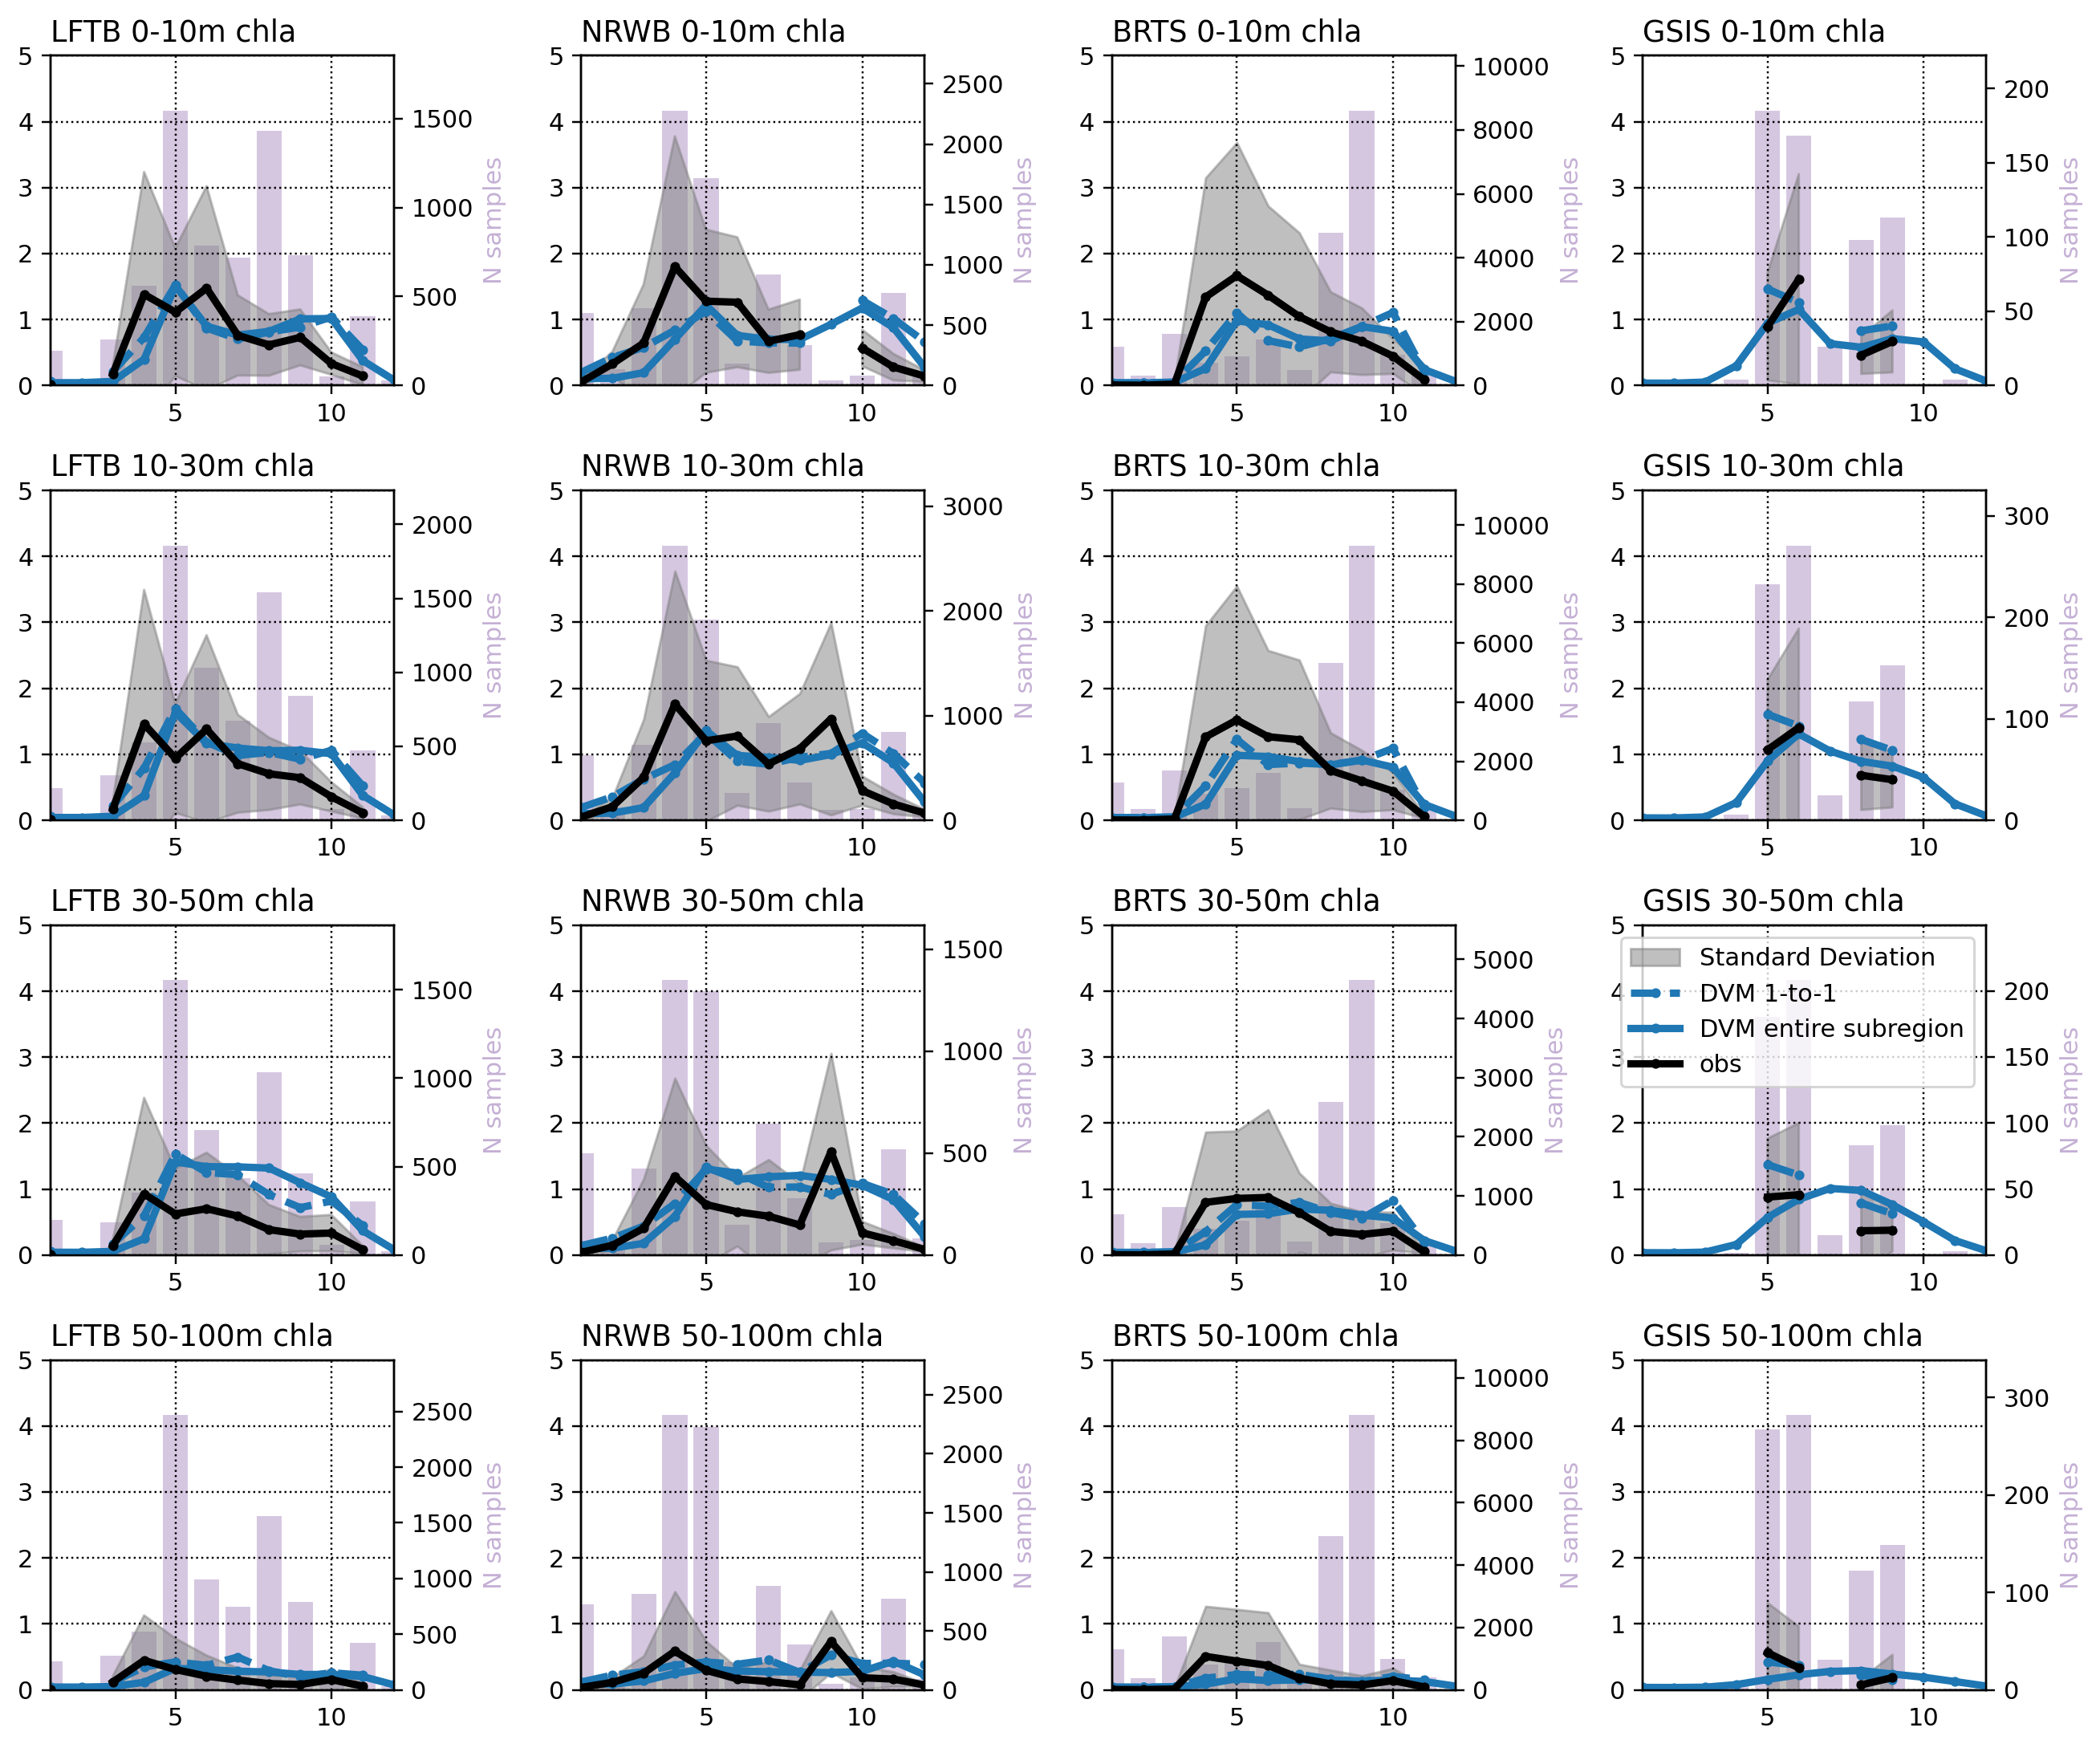

In [ ]:
# CHL ts
plot_1on1 = True
plot_subdomain = True

print(CHL[experiments[0]].keys())

dmin = [0,10,30,50]
dmax = [10,30,50,100]
month_numbers = [date.month for date in CHL[experiments[0]]["date"]]

ave = {}
aveall = {}
for ex in experiments:
    ave[ex] = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}
    aveall[ex] = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}

aveobs    = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}
stdobs    = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}
num       = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}

i = 0
for d in ave[experiments[0]].keys():
    
    aveobs[d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
    stdobs[d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
    num[d]    = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
    for ex in experiments:
        ave[ex][d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
        aveall[ex][d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
        for r in ave[experiments[0]][d].keys():
            for m in range(1,13):
                reg = np.logical_and( np.logical_and( np.array(CHL[experiments[0]]["region"])==r, np.logical_and( np.array(CHL[experiments[0]]["depth"])< dmax[i], np.array(CHL[experiments[0]]["depth"])>= dmin[i]) ), np.array(month_numbers) == m)
                ave[ex][d][r].append( np.nanmean(np.array(CHL[ex]["model"])[reg]) )
                if plot_subdomain:
                    regmodel = REGmask[r]==1
                    shallow_removed = np.copy(CHLave[ex][d][m])
                    shallow_removed[depthm.mask] = np.nan
                    shallow_removed[depthm<100.0] = np.nan
                    aveall[ex][d][r].append( np.nanmean( shallow_removed[regmodel] ) )
                if ex == experiments[0]:
                    aveobs[d][r].append( np.nanmean(np.array(CHL[ex]["obs"])[reg]) )
                    stdobs[d][r].append( np.nanstd(np.array(CHL[ex]["obs"])[reg]) )
                    num[d][r].append(np.count_nonzero(np.isfinite(np.array(CHL[ex]["obs"])[reg])))

    i = i + 1

#x = np.arange(len(ave[experiments[0]][d][r])) + 1 # /12. + int(date1)
x = np.arange(1, 13)
figure=plt.figure(figsize=(12,10), dpi= 220, facecolor='w', edgecolor='k')
p=1
for d in ave[experiments[0]].keys():
    for r in ave[experiments[0]][d].keys():
        ax=figure.add_subplot(4,4,p)

        
        nn = np.array(num[d][r], dtype=float)
        nn = np.nan_to_num(nn, nan=0.0)  
        valid = (nn >= 50) 
        obsplot = np.copy( aveobs[d][r] )
        obsplot[~valid] = np.nan

        ax2 = ax.twinx()
        # Put the secondary axis behind the primary
        ax2.set_zorder(0)
        ax.set_zorder(1)
        ax.set_facecolor('none')

        # Draw bars first, low zorder so they sit at the back
        ax2.bar(
            x, nn, width=0.8, color='#C5B0D5', alpha=0.70,
            align='center', zorder=0
        )

        # Cosmetics for right y-axis
        ax2.set_ylim(0, max(1.0, float(nn.max())) * 1.2)
        #ax2.tick_params(axis='y', colors='#C5B0D5')
        #ax2.spines['right'].set_color('#C5B0D5')
        ax2.grid(False)
        ax2.set_ylabel('N samples',color='#C5B0D5')



        stdmin = np.array(aveobs[d][r]) - np.array(stdobs[d][r]); stdmax = np.array(aveobs[d][r]) + np.array(stdobs[d][r]) 
        stdmin[~valid] = np.nan; stdmax[~valid] = np.nan
        ax.fill_between(x, stdmin, stdmax, color='gray', alpha=0.5, label='Standard Deviation')
        for ex in experiments:
            if plot_1on1:
               modelplot = np.copy( ave[ex][d][r] )
               modelplot[~valid] = np.nan
               if plot_subdomain:
                  linestyle="--"
                  labelhere=labels[ex]+" 1-to-1 in situ"
               else:
                   linestyle='-'
                   labelhere=labels[ex] 
               ax.plot(x, modelplot,linestyle=linestyle,marker="o",markersize=3,label=labelhere, linewidth=thickness[ex],color=colors[ex])
            if plot_subdomain:
               modelplot = np.copy( aveall[ex][d][r] )
               labelhere=labels[ex]+" entire subregion"
               ax.plot(x, modelplot,linestyle="-",marker="o",markersize=3,label=labelhere, linewidth=thickness[ex],color=colors[ex])
        ax.plot(x, obsplot,linestyle="-",marker="o",markersize=3,color="k",label="obs", linewidth=3)
        ax.grid(color='k',linestyle=':')
        ax.set_xlim(x.min(),x.max());
        ax.set_ylim(0., 5.)
        ax.set_title(r+" "+d+"m chla",loc="left");
        if p == 12: ax.legend()
        p = p + 1
plt.tight_layout()

dict_keys(['lat', 'lon', 'model', 'obs', 'depth', 'date', 'region'])


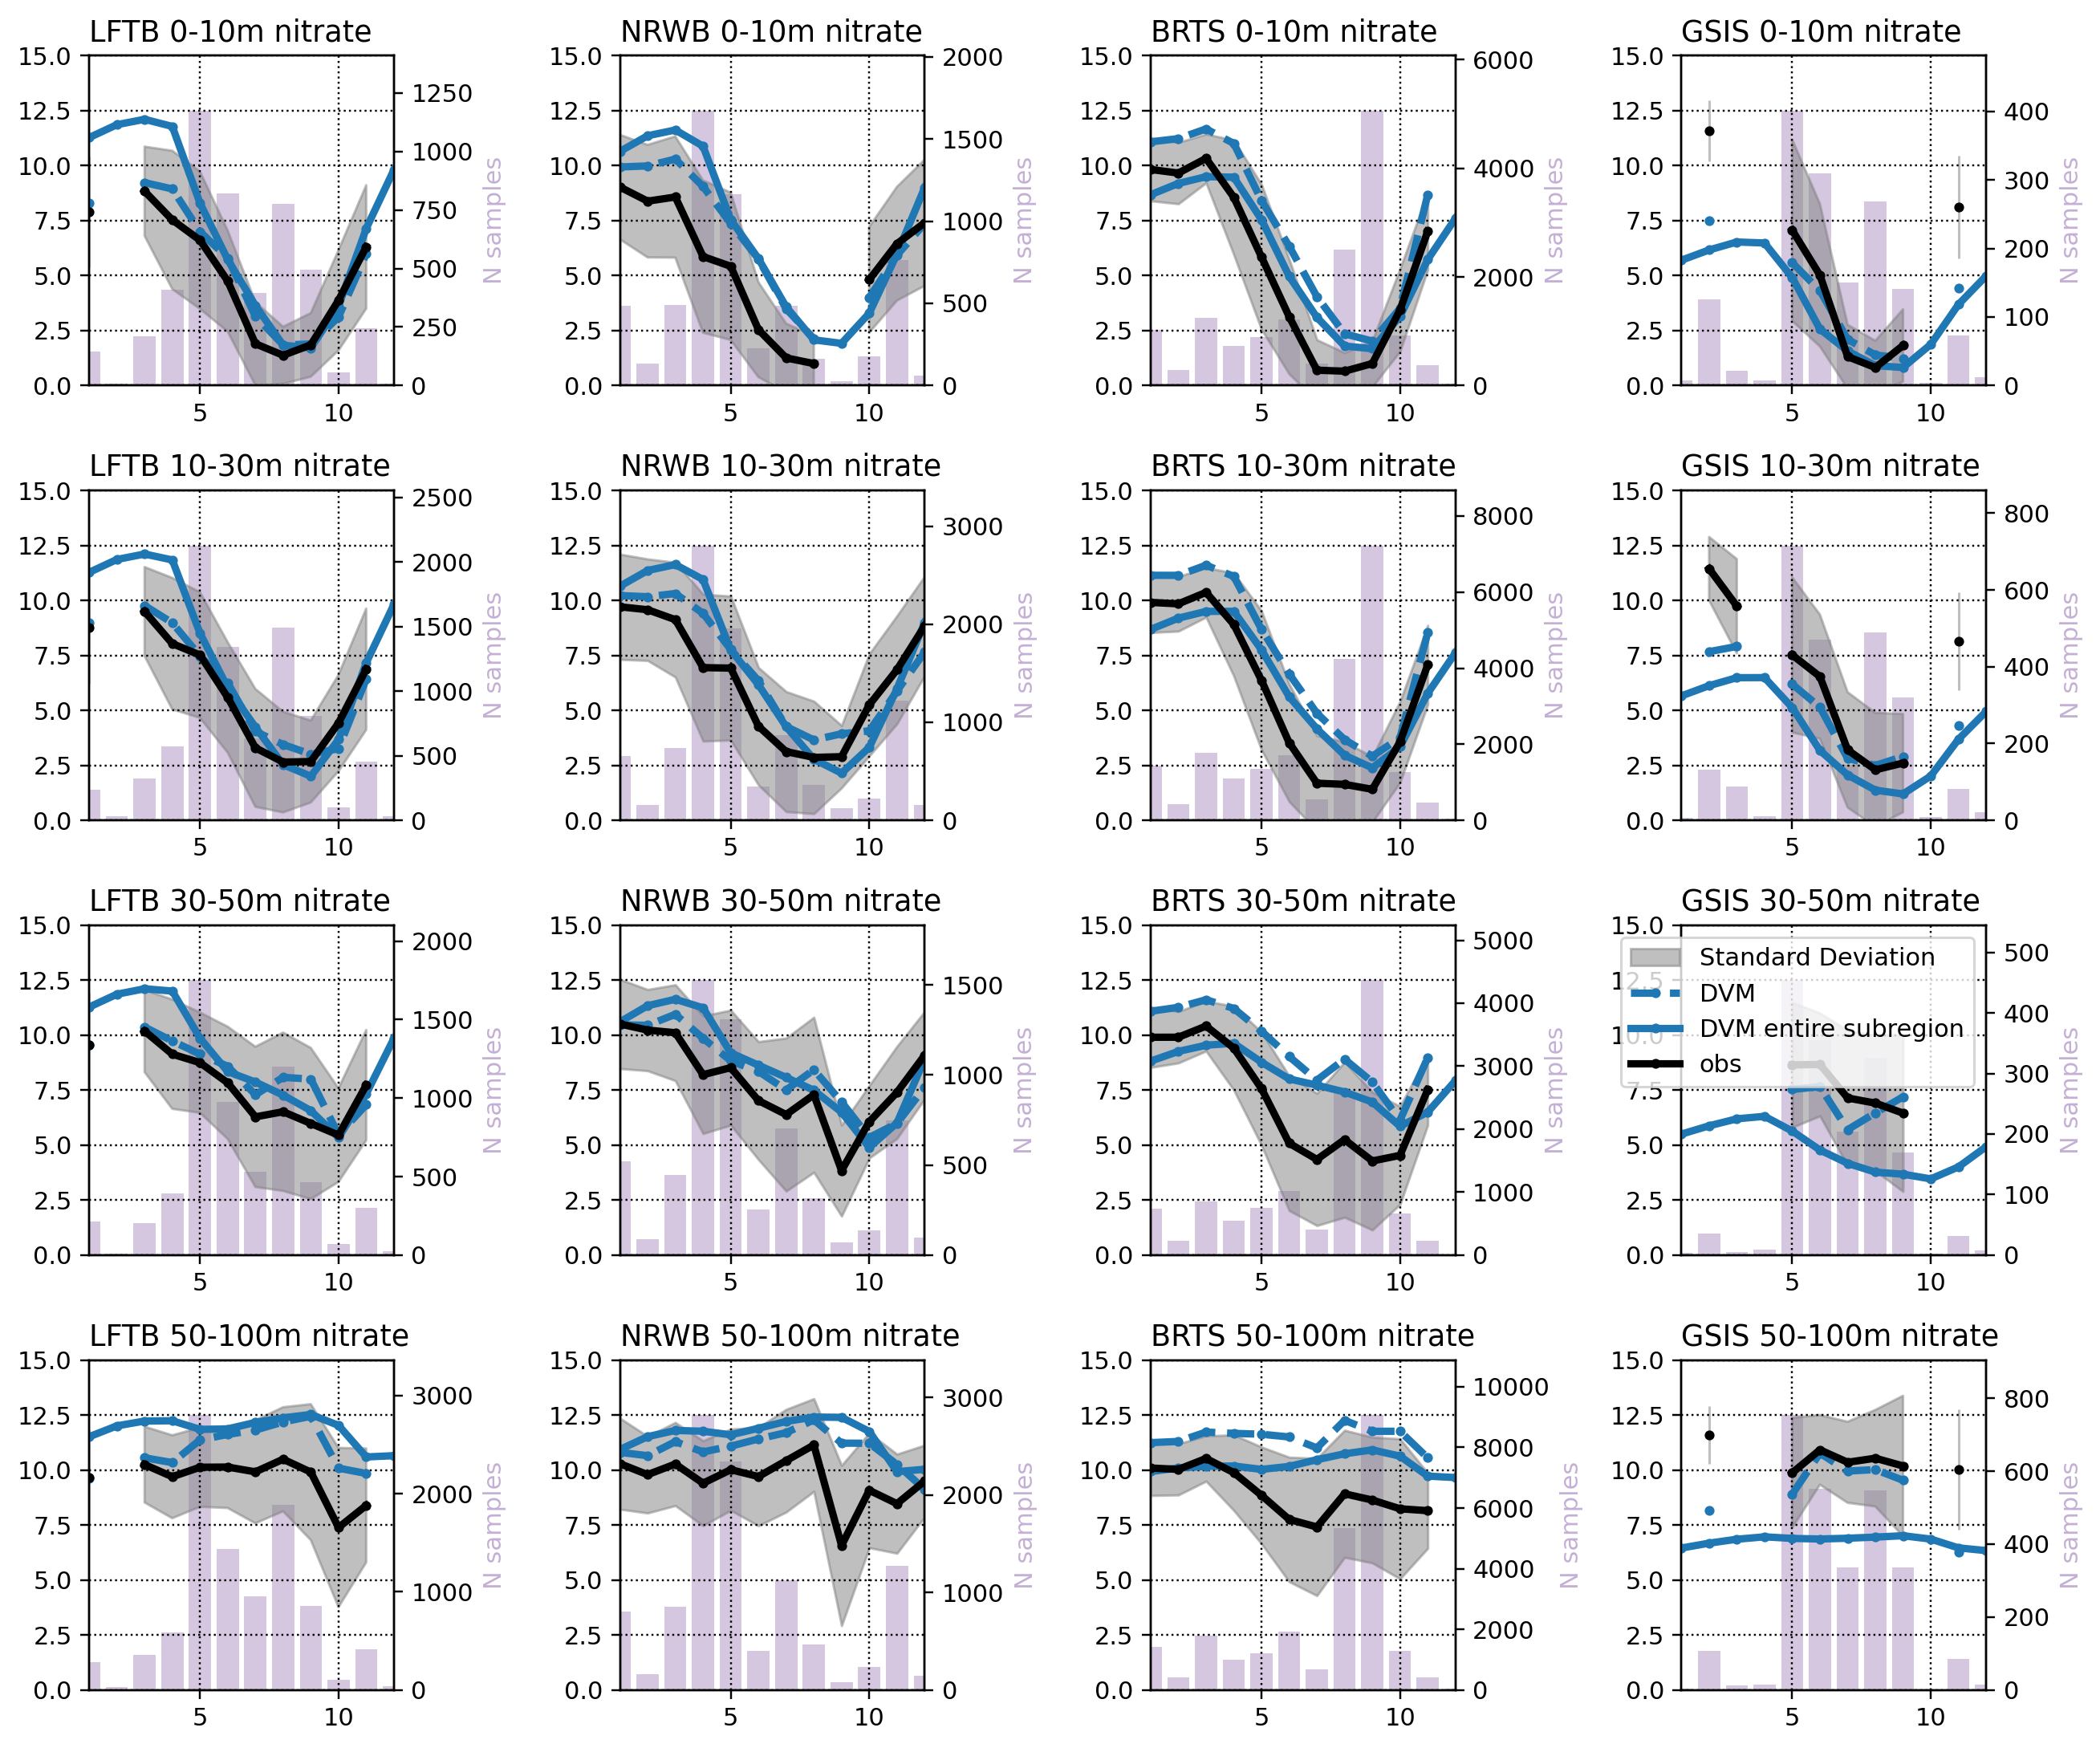

In [ ]:
# NIT ts
plot_1on1 = True
plot_subdomain = True

print(NIT[experiments[0]].keys())
dmin = [0,10,30,50]
dmax = [10,30,50,100]
month_numbers = [date.month for date in NIT[experiments[0]]["date"]]

ave = {}
aveall = {}
for ex in experiments:
    ave[ex] = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}
    aveall[ex] = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}

aveobs    = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}
stdobs    = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}
num       = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}

i = 0
for d in ave[experiments[0]].keys():
    
    aveobs[d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
    stdobs[d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
    num[d]    = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
    for ex in experiments:
        ave[ex][d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
        aveall[ex][d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
        for r in ave[experiments[0]][d].keys():
            for m in range(1,13):
                reg = np.logical_and( np.logical_and( np.array(NIT[experiments[0]]["region"])==r, np.logical_and( np.array(NIT[experiments[0]]["depth"])< dmax[i], np.array(NIT[experiments[0]]["depth"])>= dmin[i]) ), np.array(month_numbers) == m)
                ave[ex][d][r].append( np.nanmean(np.array(NIT[ex]["model"])[reg]) )
                if plot_subdomain:
                    regmodel = REGmask[r]==1
                    shallow_removed = np.copy(NITave[ex][d][m])
                    shallow_removed[depthm.mask] = np.nan
                    shallow_removed[depthm<100.0] = np.nan
                    aveall[ex][d][r].append( np.nanmean( shallow_removed[regmodel] ) )
                if ex == experiments[0]:
                    aveobs[d][r].append( np.nanmean(np.array(NIT[ex]["obs"])[reg]) )
                    stdobs[d][r].append( np.nanstd(np.array(NIT[ex]["obs"])[reg]) )
                    num[d][r].append(np.count_nonzero(np.isfinite(np.array(NIT[ex]["obs"])[reg])))

    i = i + 1

#x = np.arange(len(ave[experiments[0]][d][r])) + 1 # /12. + int(date1)
x = np.arange(1, 13)
figure=plt.figure(figsize=(12,10), dpi= 220, facecolor='w', edgecolor='k')
p=1
for d in ave[experiments[0]].keys():
    for r in ave[experiments[0]][d].keys():
        ax=figure.add_subplot(4,4,p)

        
        nn = np.array(num[d][r], dtype=float)
        nn = np.nan_to_num(nn, nan=0.0)  
        valid = (nn >= 50) 
        obsplot = np.copy( aveobs[d][r] )
        obsplot[~valid] = np.nan

        ax2 = ax.twinx()
        # Put the secondary axis behind the primary
        ax2.set_zorder(0)
        ax.set_zorder(1)
        ax.set_facecolor('none')

        # Draw bars first, low zorder so they sit at the back
        ax2.bar(
            x, nn, width=0.8, color='#C5B0D5', alpha=0.70,
            align='center', zorder=0
        )

        # Cosmetics for right y-axis
        ax2.set_ylim(0, max(1.0, float(nn.max())) * 1.2)
        #ax2.tick_params(axis='y', colors='#C5B0D5')
        #ax2.spines['right'].set_color('#C5B0D5')
        ax2.grid(False)
        ax2.set_ylabel('N samples',color='#C5B0D5')



        stdmin = np.array(aveobs[d][r]) - np.array(stdobs[d][r]); stdmax = np.array(aveobs[d][r]) + np.array(stdobs[d][r]) 
        stdmin[~valid] = np.nan; stdmax[~valid] = np.nan
        ax.fill_between(x, stdmin, stdmax, color='gray', alpha=0.5, label='Standard Deviation')
        for ex in experiments:
            if plot_1on1:
               modelplot = np.copy( ave[ex][d][r] )
               modelplot[~valid] = np.nan
               if plot_subdomain:
                  linestyle="--"
                  labelhere=labels[ex]+" 1-to-1 in situ"
               else:
                   linestyle='-'
                   labelhere=labels[ex] 
               ax.plot(x, modelplot,linestyle=linestyle,marker="o",markersize=3,label=labelhere, linewidth=thickness[ex],color=colors[ex])
            if plot_subdomain:
               modelplot = np.copy( aveall[ex][d][r] )
               labelhere=labels[ex]+" entire subregion"
               ax.plot(x, modelplot,linestyle="-",marker="o",markersize=3,label=labelhere, linewidth=thickness[ex],color=colors[ex])
        ax.plot(x, obsplot,linestyle="-",marker="o",markersize=3,color="k",label="obs", linewidth=3)
        ax.grid(color='k',linestyle=':')
        ax.set_xlim(x.min(),x.max());
        ax.set_ylim(0., 15.)
        ax.set_title(r+" "+d+"m nitrate",loc="left");
        if p == 12: ax.legend()
        p = p + 1
plt.tight_layout()

dict_keys(['lat', 'lon', 'model', 'obs', 'depth', 'date', 'region'])


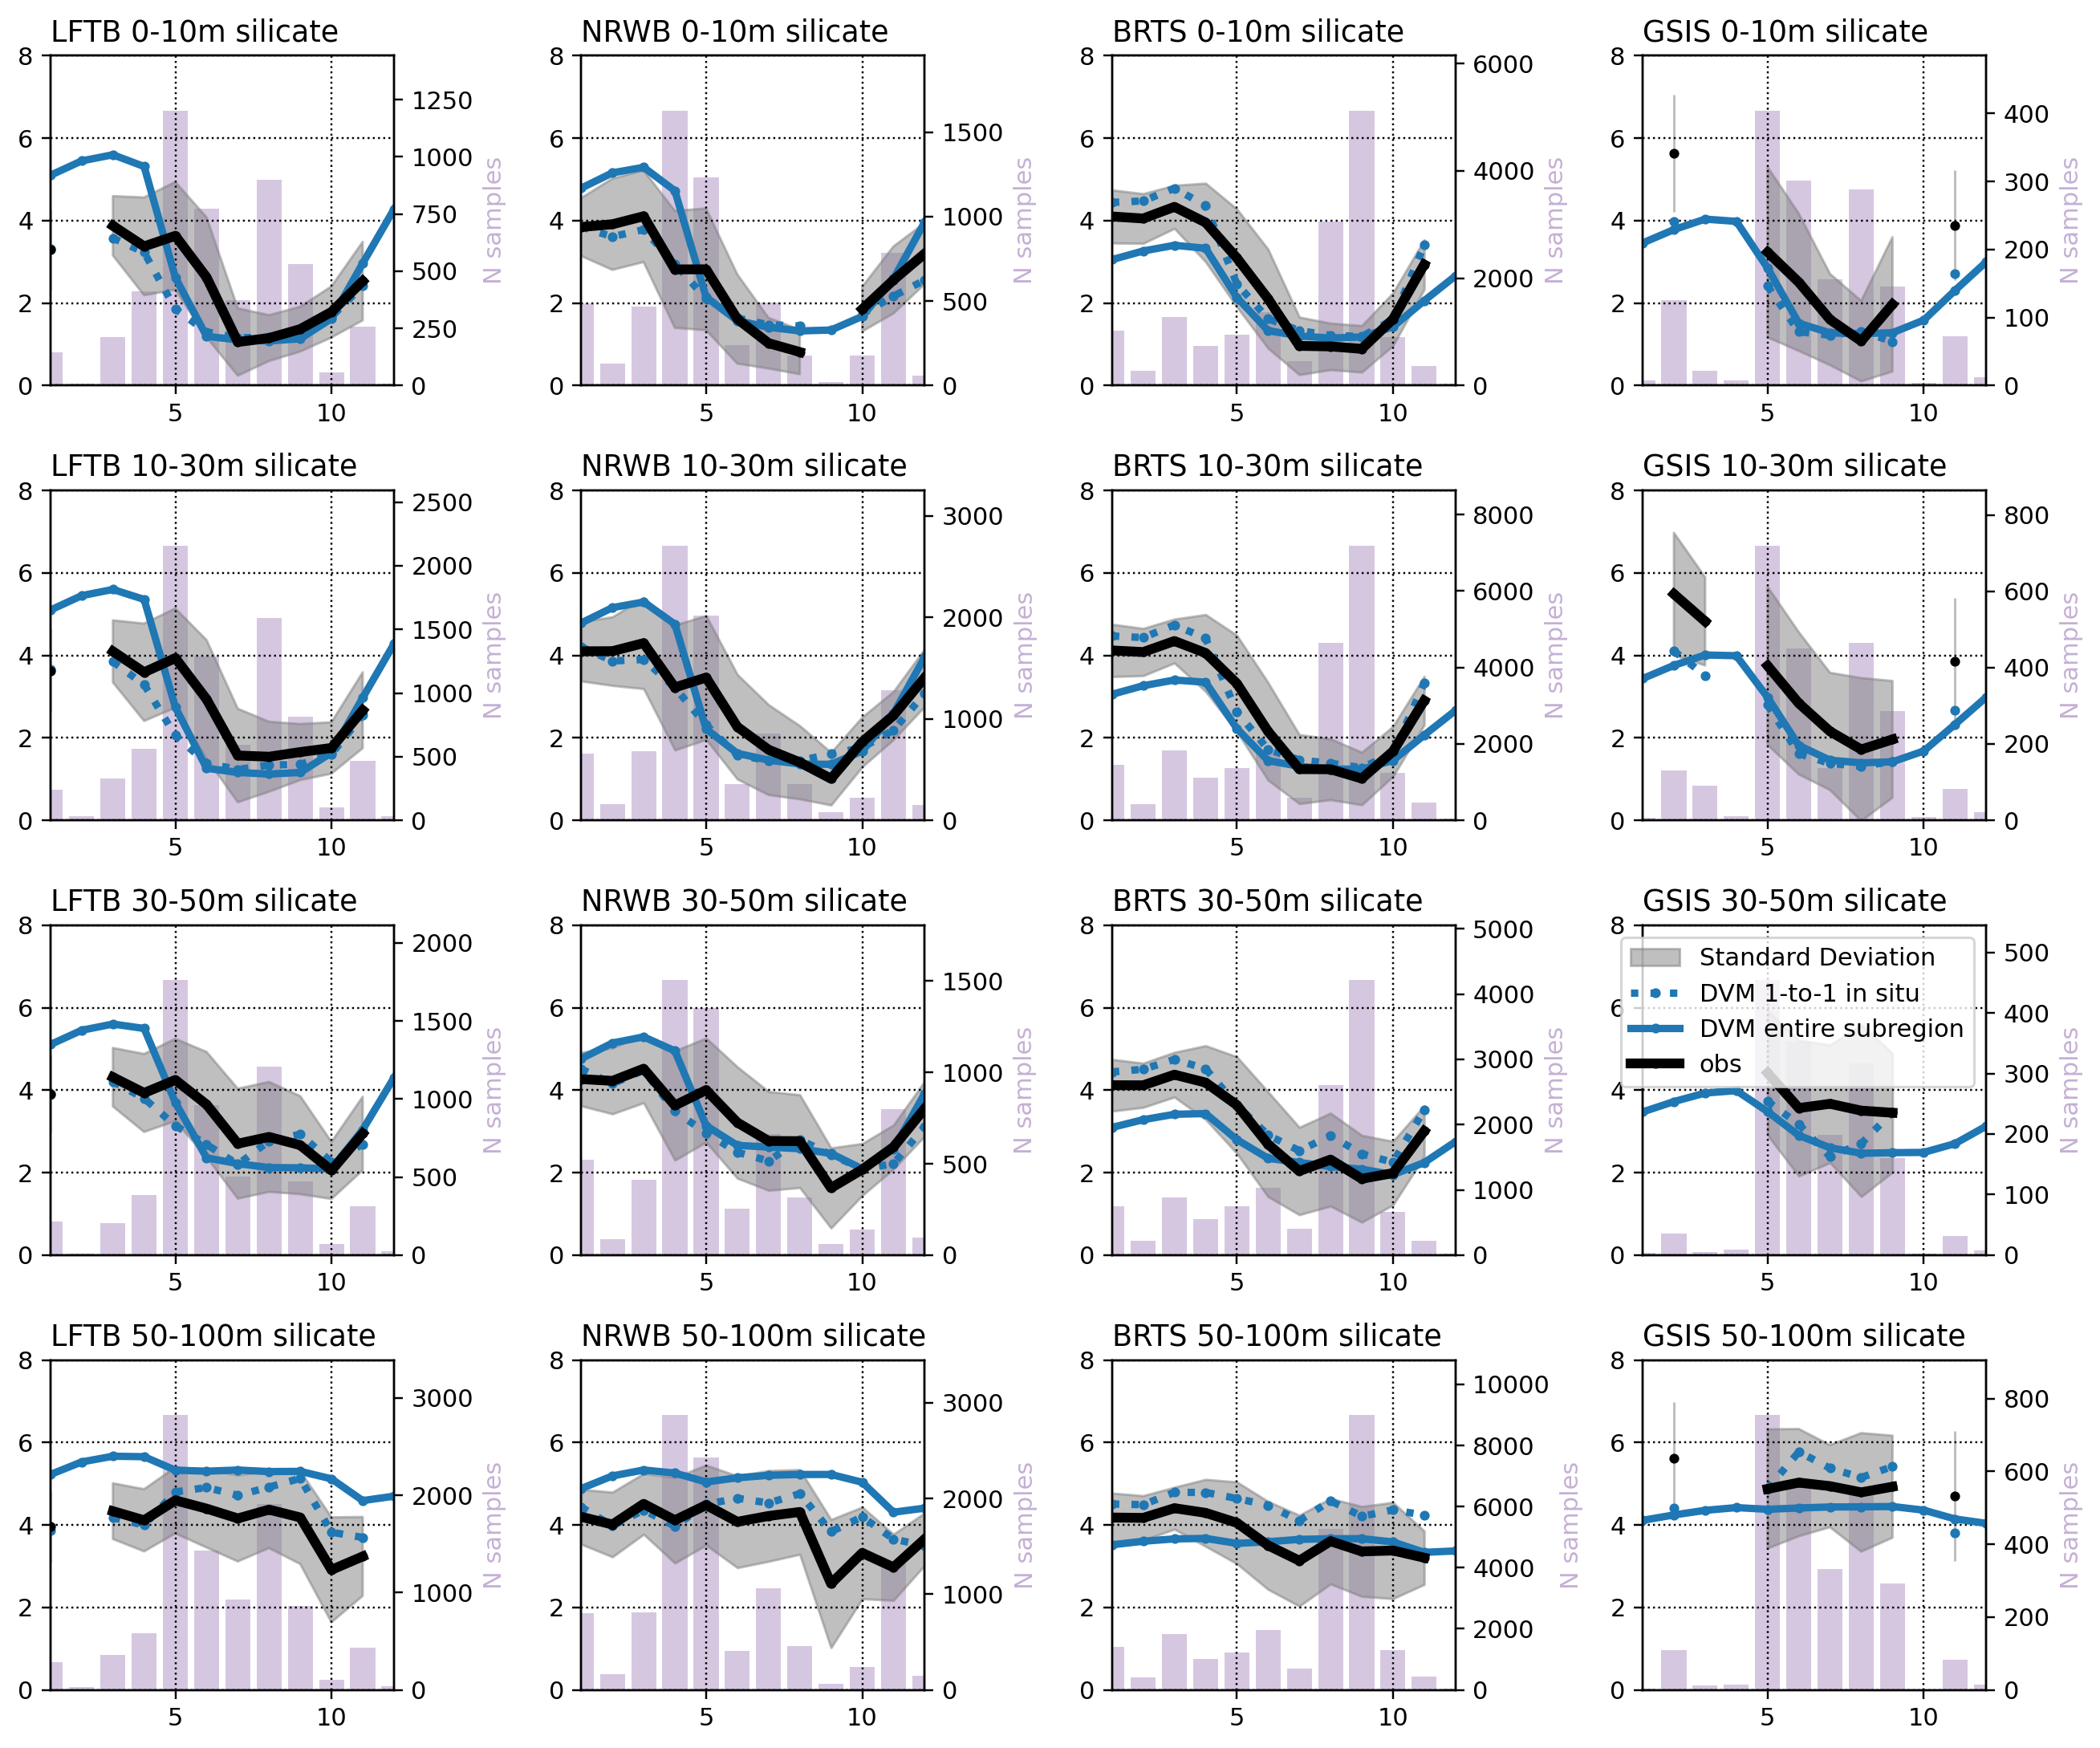

In [15]:
# SIL ts
plot_1on1 = True
plot_subdomain = True

print(SIL[experiments[0]].keys())
dmin = [0,10,30,50]
dmax = [10,30,50,100]
month_numbers = [date.month for date in SIL[experiments[0]]["date"]]

ave = {}
for ex in experiments:
    ave[ex] = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}
    aveall[ex] = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}

aveobs    = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}
stdobs    = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}
num       = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}

i = 0
for d in ave[experiments[0]].keys():
    
    aveobs[d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
    stdobs[d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
    num[d]    = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
    for ex in experiments:
        ave[ex][d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
        aveall[ex][d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
        for r in ave[experiments[0]][d].keys():
            for m in range(1,13):
                reg = np.logical_and( np.logical_and( np.array(SIL[experiments[0]]["region"])==r, np.logical_and( np.array(SIL[experiments[0]]["depth"])< dmax[i], np.array(SIL[experiments[0]]["depth"])>= dmin[i]) ), np.array(month_numbers) == m)
                ave[ex][d][r].append( np.nanmean(np.array(SIL[ex]["model"])[reg]) )
                if plot_subdomain:
                    regmodel = REGmask[r]==1
                    shallow_removed = np.copy(SILave[ex][d][m])
                    shallow_removed[depthm.mask] = np.nan
                    shallow_removed[depthm<100.0] = np.nan
                    aveall[ex][d][r].append( np.nanmean( shallow_removed[regmodel] ) )
                if ex == experiments[0]:
                    aveobs[d][r].append( np.nanmean(np.array(SIL[ex]["obs"])[reg]) )
                    stdobs[d][r].append( np.nanstd(np.array(SIL[ex]["obs"])[reg]) )
                    num[d][r].append(np.count_nonzero(np.isfinite(np.array(SIL[ex]["obs"])[reg])))

    i = i + 1

#x = np.arange(len(ave[experiments[0]][d][r])) + 1 # /12. + int(date1)
x = np.arange(1, 13)
figure=plt.figure(figsize=(12,10), dpi= 220, facecolor='w', edgecolor='k')
p=1
for d in ave[experiments[0]].keys():
    for r in ave[experiments[0]][d].keys():
        ax=figure.add_subplot(4,4,p)

        
        nn = np.array(num[d][r], dtype=float)
        nn = np.nan_to_num(nn, nan=0.0)  
        valid = (nn >= 50) 
        obsplot = np.copy( aveobs[d][r] )
        obsplot[~valid] = np.nan

        ax2 = ax.twinx()
        # Put the secondary axis behind the primary
        ax2.set_zorder(0)
        ax.set_zorder(1)
        ax.set_facecolor('none')

        # Draw bars first, low zorder so they sit at the back
        ax2.bar(
            x, nn, width=0.8, color='#C5B0D5', alpha=0.70,
            align='center', zorder=0
        )

        # Cosmetics for right y-axis
        ax2.set_ylim(0, max(1.0, float(nn.max())) * 1.2)
        #ax2.tick_params(axis='y', colors='#C5B0D5')
        #ax2.spines['right'].set_color('#C5B0D5')
        ax2.grid(False)
        ax2.set_ylabel('N samples',color='#C5B0D5')



        stdmin = np.array(aveobs[d][r]) - np.array(stdobs[d][r]); stdmax = np.array(aveobs[d][r]) + np.array(stdobs[d][r]) 
        stdmin[~valid] = np.nan; stdmax[~valid] = np.nan
        ax.fill_between(x, stdmin, stdmax, color='gray', alpha=0.5, label='Standard Deviation')
        for ex in experiments:
            if plot_1on1:
               modelplot = np.copy( ave[ex][d][r] )
               modelplot[~valid] = np.nan
               if plot_subdomain:
                  linestyle=":"
                  labelhere=labels[ex]+" 1-to-1 in situ"
               else:
                   linestyle='-'
                   labelhere=labels[ex] 
               ax.plot(x, modelplot,linestyle=linestyle,marker="o",markersize=3,label=labelhere, linewidth=thickness[ex],color=colors[ex])
            if plot_subdomain:
               modelplot = np.copy( aveall[ex][d][r] )
               labelhere=labels[ex]+" entire subregion"
               ax.plot(x, modelplot,linestyle="-",marker="o",markersize=3,label=labelhere, linewidth=thickness[ex],color=colors[ex])
        ax.plot(x, obsplot,linestyle="-",marker="o",markersize=3,color="k",label="obs", linewidth=4)
        ax.grid(color='k',linestyle=':')
        ax.set_xlim(x.min(),x.max());
        ax.set_ylim(0., 8.)
        ax.set_title(r+" "+d+"m silicate",loc="left");
        if p == 12: ax.legend()
        p = p + 1
plt.tight_layout()

dict_keys(['lat', 'lon', 'model', 'obs', 'depth', 'date', 'region'])


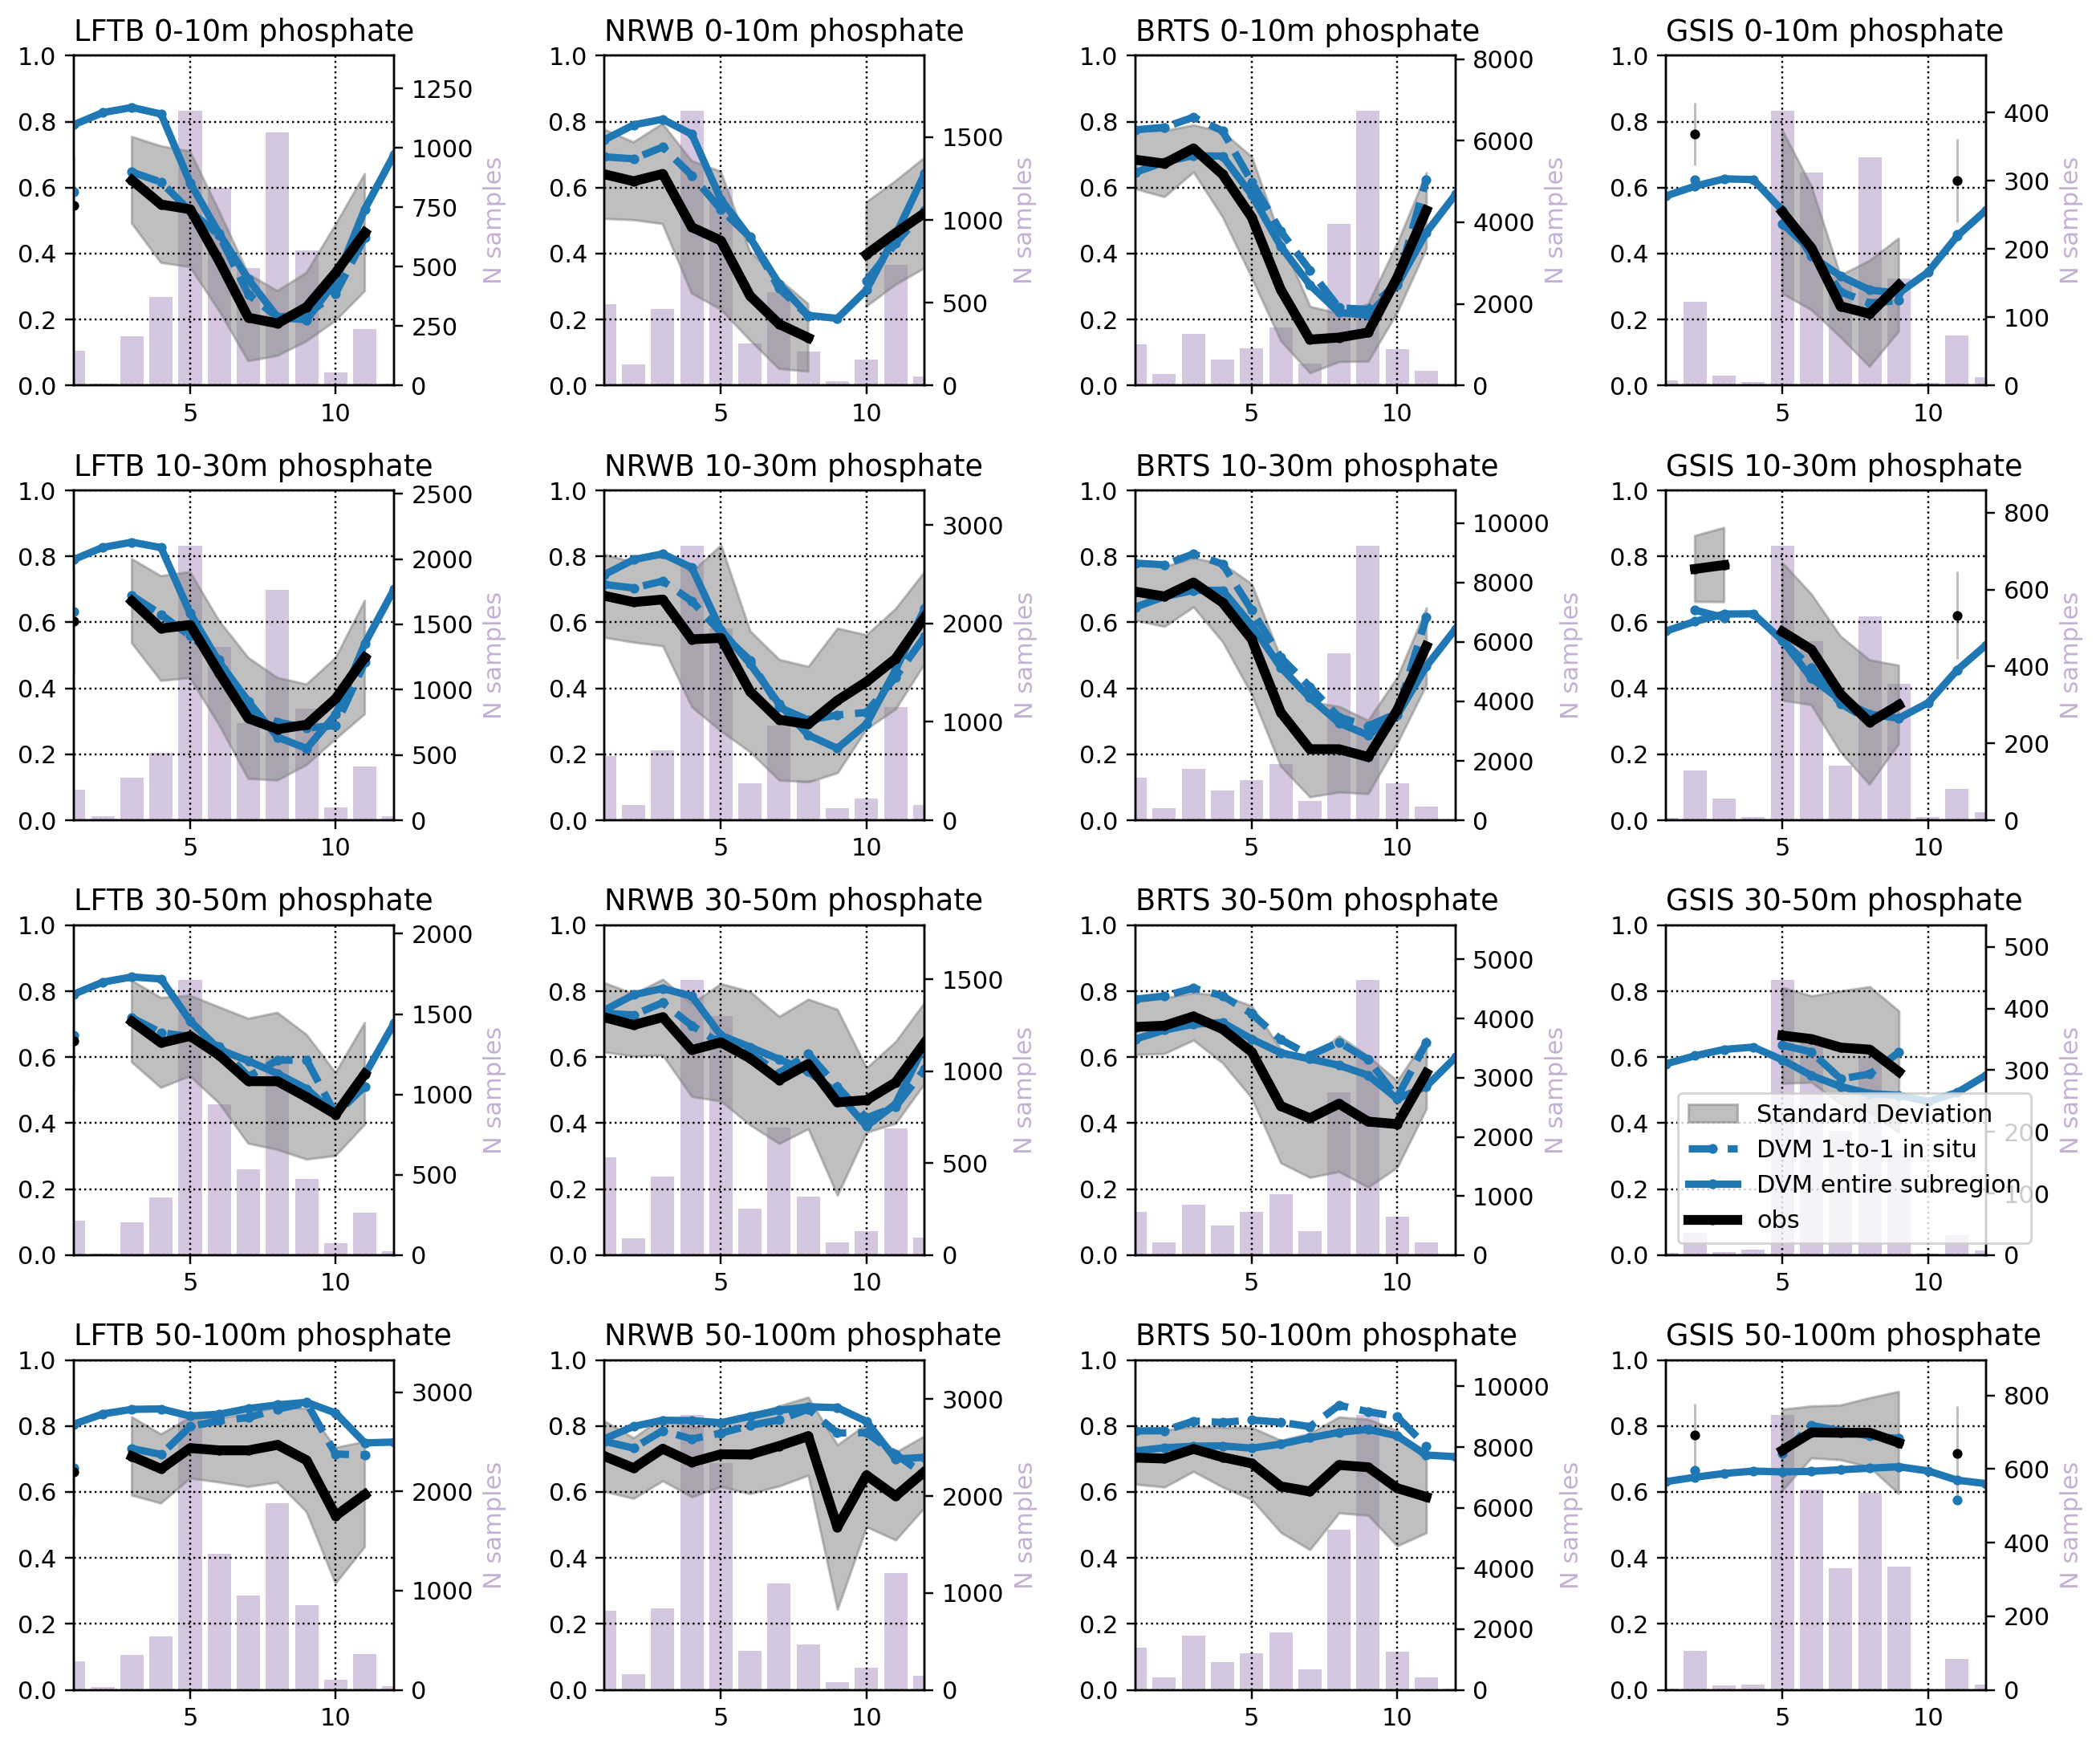

In [16]:
# PHO ts
plot_1on1 = True
plot_subdomain = True

print(PHO[experiments[0]].keys())
dmin = [0,10,30,50]
dmax = [10,30,50,100]
month_numbers = [date.month for date in PHO[experiments[0]]["date"]]

ave = {}
for ex in experiments:
    ave[ex] = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}
    aveall[ex] = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}

aveobs    = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}
stdobs    = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}
num       = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}

i = 0
for d in ave[experiments[0]].keys():
    
    aveobs[d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
    stdobs[d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
    num[d]    = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
    for ex in experiments:
        ave[ex][d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
        aveall[ex][d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
        for r in ave[experiments[0]][d].keys():
            for m in range(1,13):
                reg = np.logical_and( np.logical_and( np.array(PHO[experiments[0]]["region"])==r, np.logical_and( np.array(PHO[experiments[0]]["depth"])< dmax[i], np.array(PHO[experiments[0]]["depth"])>= dmin[i]) ), np.array(month_numbers) == m)
                ave[ex][d][r].append( np.nanmean(np.array(PHO[ex]["model"])[reg]) )
                if plot_subdomain:
                    regmodel = REGmask[r]==1
                    shallow_removed = np.copy(PHOave[ex][d][m])
                    shallow_removed[depthm.mask] = np.nan
                    shallow_removed[depthm<100.0] = np.nan
                    aveall[ex][d][r].append( np.nanmean( shallow_removed[regmodel] ) )
                if ex == experiments[0]:
                    aveobs[d][r].append( np.nanmean(np.array(PHO[ex]["obs"])[reg]) )
                    stdobs[d][r].append( np.nanstd(np.array(PHO[ex]["obs"])[reg]) )
                    num[d][r].append(np.count_nonzero(np.isfinite(np.array(PHO[ex]["obs"])[reg])))

    i = i + 1

#x = np.arange(len(ave[experiments[0]][d][r])) + 1 # /12. + int(date1)
x = np.arange(1, 13)
figure=plt.figure(figsize=(12,10), dpi= 220, facecolor='w', edgecolor='k')
p=1
for d in ave[experiments[0]].keys():
    for r in ave[experiments[0]][d].keys():
        ax=figure.add_subplot(4,4,p)

        
        nn = np.array(num[d][r], dtype=float)
        nn = np.nan_to_num(nn, nan=0.0)  
        valid = (nn >= 50) 
        obsplot = np.copy( aveobs[d][r] )
        obsplot[~valid] = np.nan

        ax2 = ax.twinx()
        # Put the secondary axis behind the primary
        ax2.set_zorder(0)
        ax.set_zorder(1)
        ax.set_facecolor('none')

        # Draw bars first, low zorder so they sit at the back
        ax2.bar(
            x, nn, width=0.8, color='#C5B0D5', alpha=0.70,
            align='center', zorder=0
        )

        # Cosmetics for right y-axis
        ax2.set_ylim(0, max(1.0, float(nn.max())) * 1.2)
        #ax2.tick_params(axis='y', colors='#C5B0D5')
        #ax2.spines['right'].set_color('#C5B0D5')
        ax2.grid(False)
        ax2.set_ylabel('N samples',color='#C5B0D5')



        stdmin = np.array(aveobs[d][r]) - np.array(stdobs[d][r]); stdmax = np.array(aveobs[d][r]) + np.array(stdobs[d][r]) 
        stdmin[~valid] = np.nan; stdmax[~valid] = np.nan
        ax.fill_between(x, stdmin, stdmax, color='gray', alpha=0.5, label='Standard Deviation')
        for ex in experiments:
            if plot_1on1:
               modelplot = np.copy( ave[ex][d][r] )
               modelplot[~valid] = np.nan
               if plot_subdomain:
                  linestyle="--"
                  labelhere=labels[ex]+" 1-to-1 in situ"
               else:
                   linestyle='-'
                   labelhere=labels[ex]
               ax.plot(x, modelplot,linestyle=linestyle,marker="o",markersize=3,label=labelhere, linewidth=thickness[ex],color=colors[ex])
            if plot_subdomain:
               modelplot = np.copy( aveall[ex][d][r] )
               labelhere=labels[ex]+" entire subregion"
               ax.plot(x, modelplot,linestyle="-",marker="o",markersize=3,label=labelhere, linewidth=thickness[ex],color=colors[ex])
        ax.plot(x, obsplot,linestyle="-",marker="o",markersize=3,color="k",label="obs", linewidth=4)
        ax.grid(color='k',linestyle=':')
        ax.set_xlim(x.min(),x.max());
        ax.set_ylim(0., 1.)
        ax.set_title(r+" "+d+"m phosphate",loc="left");
        if p == 12: ax.legend()
        p = p + 1
plt.tight_layout()

dict_keys(['lat', 'lon', 'model', 'obs', 'depth', 'date', 'region'])


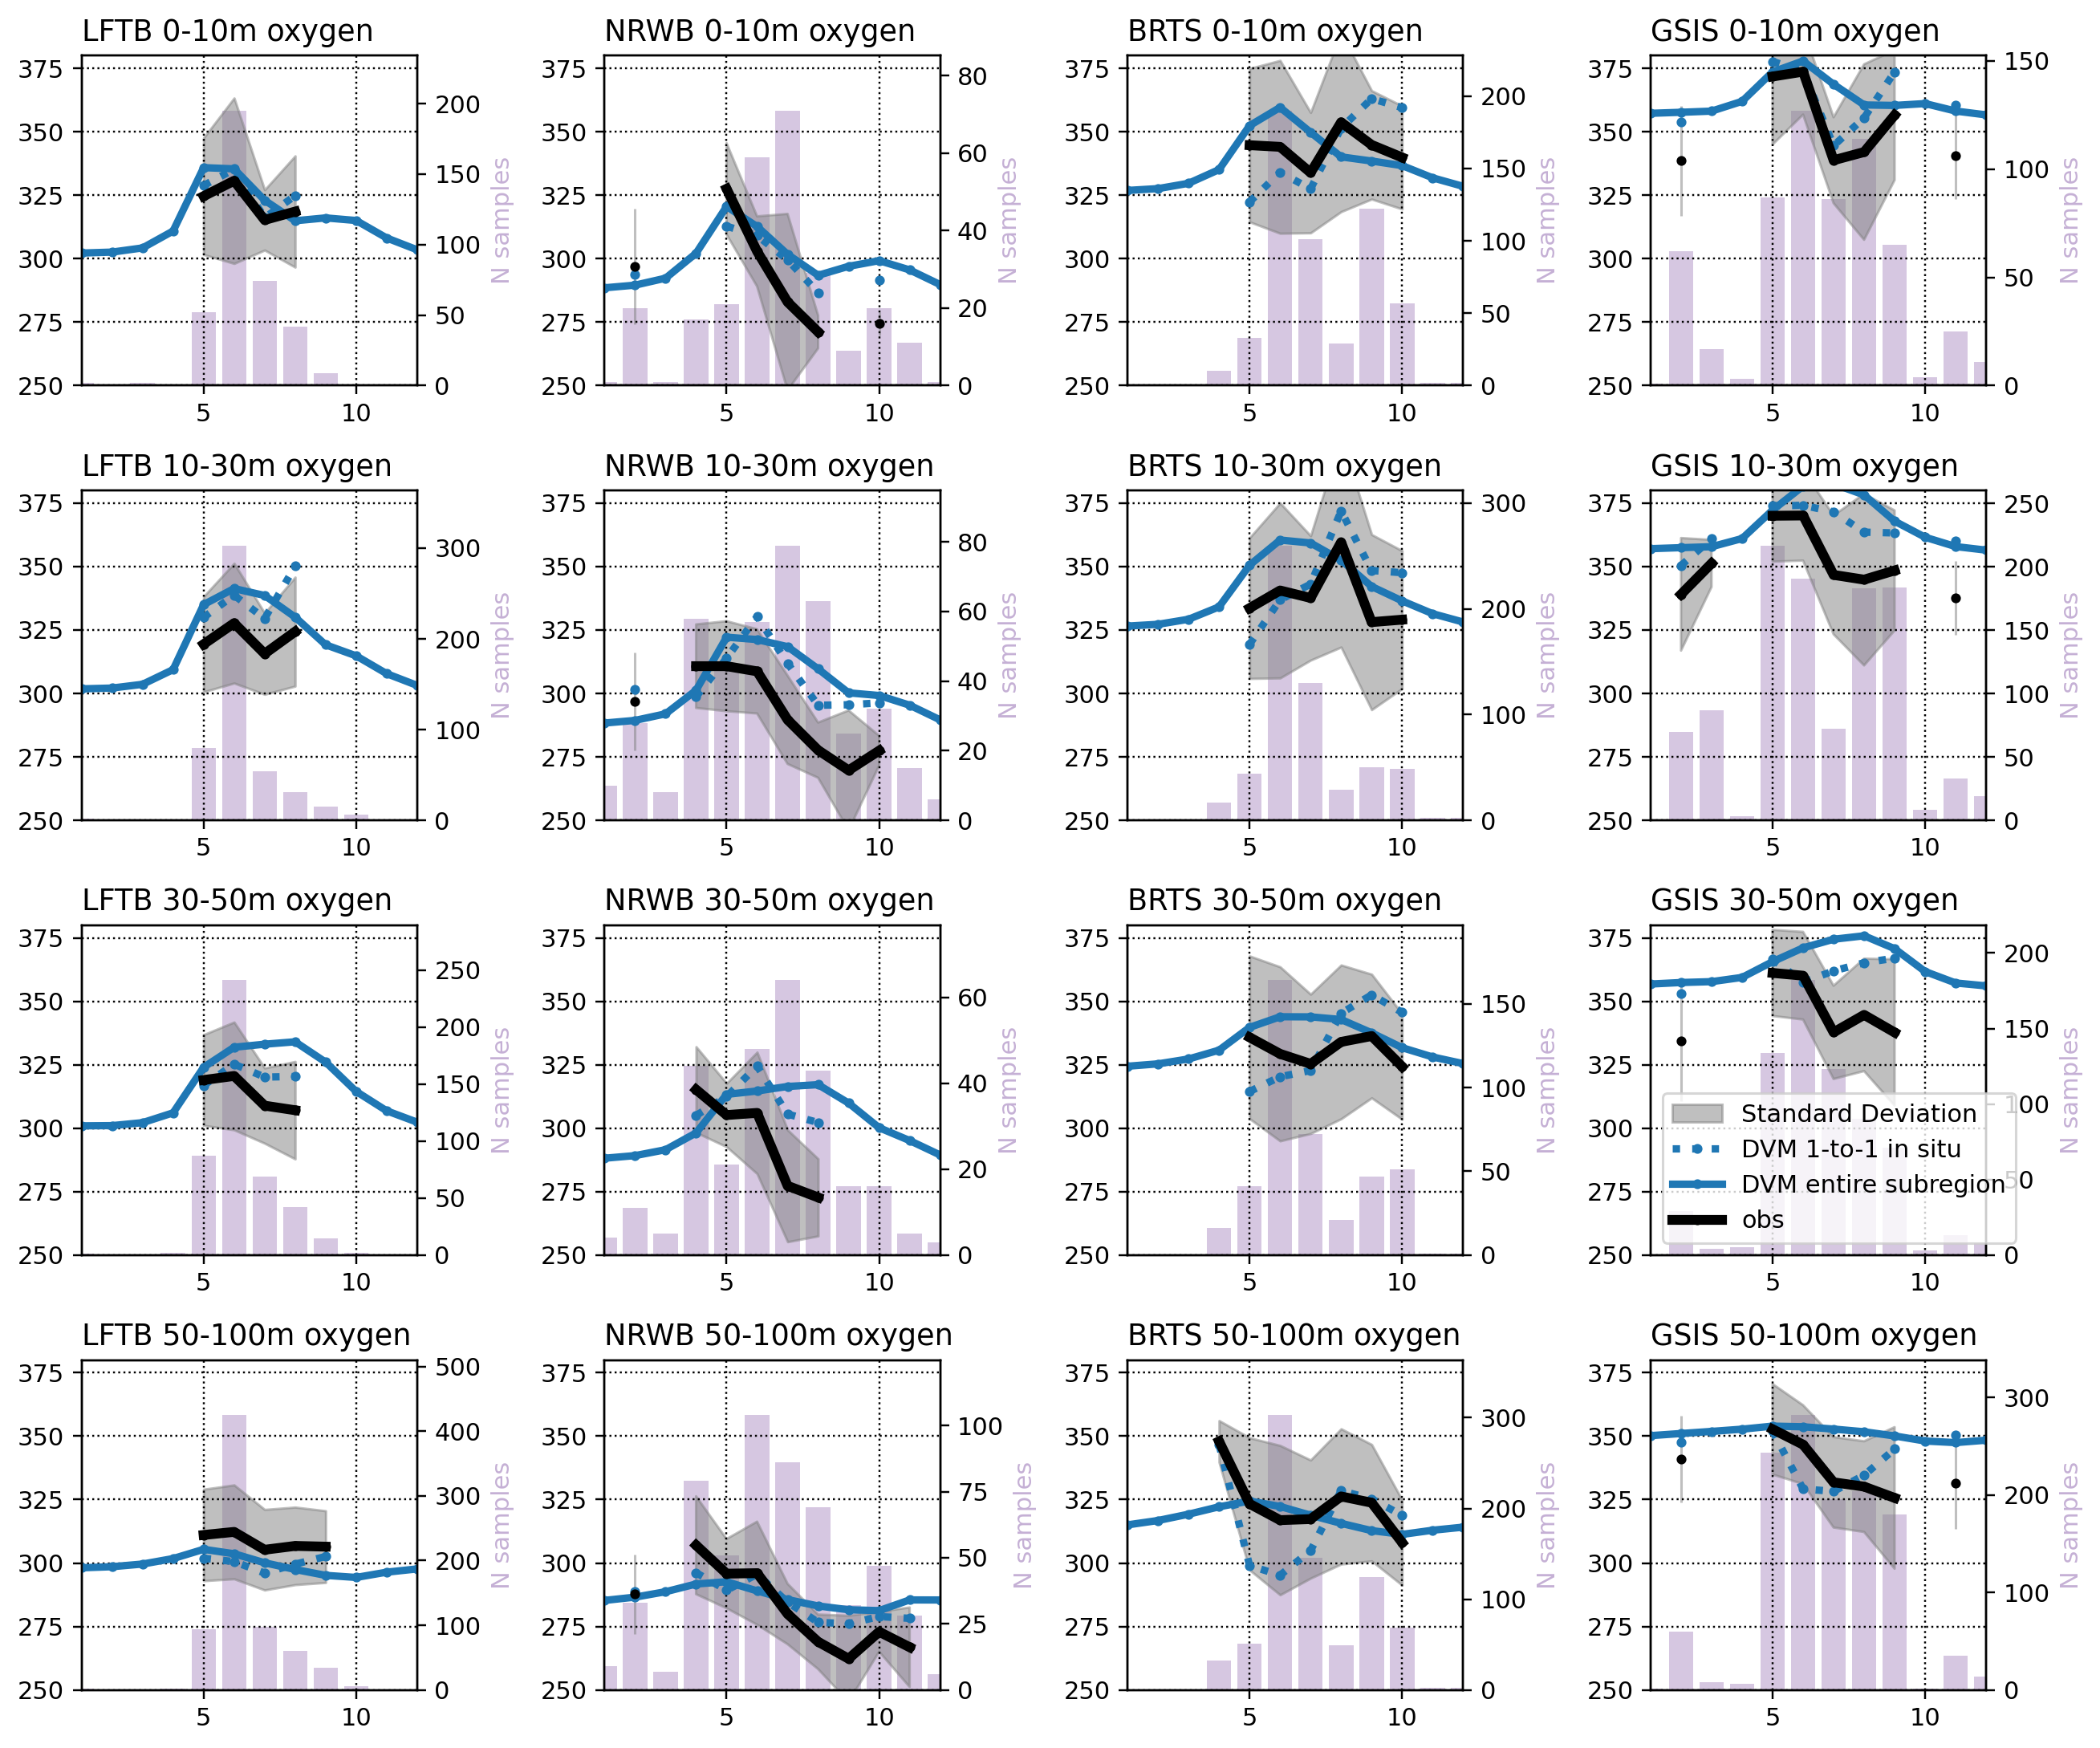

In [17]:
# OXY ts
plot_1on1 = True
plot_subdomain = True

print(OXY[experiments[0]].keys())
dmin = [0,10,30,50]
dmax = [10,30,50,100]
month_numbers = [date.month for date in OXY[experiments[0]]["date"]]

ave = {}
for ex in experiments:
    ave[ex] = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}
    aveall[ex] = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}

aveobs    = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}
stdobs    = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}
num       = {"0-10":{},'10-30':{},"30-50":{},"50-100":{}}

i = 0
for d in ave[experiments[0]].keys():
    
    aveobs[d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
    stdobs[d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
    num[d]    = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
    for ex in experiments:
        ave[ex][d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
        aveall[ex][d] = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[]}
        for r in ave[experiments[0]][d].keys():
            for m in range(1,13):
                reg = np.logical_and( np.logical_and( np.array(OXY[experiments[0]]["region"])==r, np.logical_and( np.array(OXY[experiments[0]]["depth"])< dmax[i], np.array(OXY[experiments[0]]["depth"])>= dmin[i]) ), np.array(month_numbers) == m)
                ave[ex][d][r].append( np.nanmean(np.array(OXY[ex]["model"])[reg]) )
                if plot_subdomain:
                    regmodel = REGmask[r]==1
                    shallow_removed = np.copy(OXYave[ex][d][m])
                    shallow_removed[depthm.mask] = np.nan
                    shallow_removed[depthm<100.0] = np.nan
                    aveall[ex][d][r].append( np.nanmean( shallow_removed[regmodel] ) )
                if ex == experiments[0]:
                    aveobs[d][r].append( np.nanmean(np.array(OXY[ex]["obs"])[reg]) )
                    stdobs[d][r].append( np.nanstd(np.array(OXY[ex]["obs"])[reg]) )
                    num[d][r].append(np.count_nonzero(np.isfinite(np.array(OXY[ex]["obs"])[reg])))

    i = i + 1

#x = np.arange(len(ave[experiments[0]][d][r])) + 1 # /12. + int(date1)
x = np.arange(1, 13)
figure=plt.figure(figsize=(12,10), dpi= 220, facecolor='w', edgecolor='k')
p=1
for d in ave[experiments[0]].keys():
    for r in ave[experiments[0]][d].keys():
        ax=figure.add_subplot(4,4,p)

        
        nn = np.array(num[d][r], dtype=float)
        nn = np.nan_to_num(nn, nan=0.0)  
        valid = (nn >= 20) 
        obsplot = np.copy( aveobs[d][r] )
        obsplot[~valid] = np.nan

        ax2 = ax.twinx()
        # Put the secondary axis behind the primary
        ax2.set_zorder(0)
        ax.set_zorder(1)
        ax.set_facecolor('none')

        # Draw bars first, low zorder so they sit at the back
        ax2.bar(
            x, nn, width=0.8, color='#C5B0D5', alpha=0.70,
            align='center', zorder=0
        )

        # Cosmetics for right y-axis
        ax2.set_ylim(0, max(1.0, float(nn.max())) * 1.2)
        #ax2.tick_params(axis='y', colors='#C5B0D5')
        #ax2.spines['right'].set_color('#C5B0D5')
        ax2.grid(False)
        ax2.set_ylabel('N samples',color='#C5B0D5')



        stdmin = np.array(aveobs[d][r]) - np.array(stdobs[d][r]); stdmax = np.array(aveobs[d][r]) + np.array(stdobs[d][r]) 
        stdmin[~valid] = np.nan; stdmax[~valid] = np.nan
        ax.fill_between(x, stdmin, stdmax, color='gray', alpha=0.5, label='Standard Deviation')
        for ex in experiments:
            if plot_1on1:
               modelplot = np.copy( ave[ex][d][r] )
               modelplot[~valid] = np.nan
               if plot_subdomain:
                  linestyle=":"
                  labelhere=labels[ex]+" 1-to-1 in situ"
               else:
                   linestyle='-'
                   labelhere=labels[ex]
               ax.plot(x, modelplot,linestyle=linestyle,marker="o",markersize=3,label=labelhere, linewidth=thickness[ex],color=colors[ex])
            if plot_subdomain:
               modelplot = np.copy( aveall[ex][d][r] )
               labelhere=labels[ex]+" entire subregion"
               ax.plot(x, modelplot,linestyle="-",marker="o",markersize=3,label=labelhere, linewidth=thickness[ex],color=colors[ex])
        ax.plot(x, obsplot,linestyle="-",marker="o",markersize=3,color="k",label="obs", linewidth=4)
        ax.grid(color='k',linestyle=':')
        ax.set_xlim(x.min(),x.max());
        ax.set_ylim(250., 380.)
        ax.set_title(r+" "+d+"m oxygen",loc="left");
        if p == 12: ax.legend()
        p = p + 1
plt.tight_layout()

In [4]:
print(CHL[experiments[0]].keys())
iNN = np.array(CHL[experiments[0]]["region"])=="LFTB"
iNS = np.array(CHL[experiments[0]]["region"])=="NRWB"
iGr = np.array(CHL[experiments[0]]["region"])=="GSIS"
iBa = np.array(CHL[experiments[0]]["region"])=="BRTS"

rmse_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    rmse_values['Nor.N.'].append( np.round(rmse(np.array(CHL[ex]["model"])[iNN], np.array(CHL[ex]["obs"])[iNN]), 3) )
    rmse_values['Nor.S.'].append( np.round(rmse(np.array(CHL[ex]["model"])[iNS], np.array(CHL[ex]["obs"])[iNS]), 3) )
    rmse_values['Barents'].append( np.round(rmse(np.array(CHL[ex]["model"])[iBa], np.array(CHL[ex]["obs"])[iBa]), 3) )
    index.append("CHL rmse "+ex)
df = pd.DataFrame(rmse_values, index)
df.index.name = 'RMSE'
print(tabulate(df, headers='keys', tablefmt='pretty'))

bias_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    bias_values['Nor.N.'].append( np.round(bias(np.array(CHL[ex]["model"])[iNN], np.array(CHL[ex]["obs"])[iNN]), 3) )
    bias_values['Nor.S.'].append( np.round(bias(np.array(CHL[ex]["model"])[iNS], np.array(CHL[ex]["obs"])[iNS]), 3) )
    bias_values['Barents'].append( np.round(bias(np.array(CHL[ex]["model"])[iBa], np.array(CHL[ex]["obs"])[iBa]), 3) )
    index.append("CHL bias "+ex)
df = pd.DataFrame(bias_values, index)
df.index.name = 'BIAS'
print(tabulate(df, headers='keys', tablefmt='pretty'))

nstd_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    nstd_values['Nor.N.'].append( np.round(nstd(np.array(CHL[ex]["model"])[iNN], np.array(CHL[ex]["obs"])[iNN]), 3) )
    nstd_values['Nor.S.'].append( np.round(nstd(np.array(CHL[ex]["model"])[iNS], np.array(CHL[ex]["obs"])[iNS]), 3) )
    nstd_values['Barents'].append( np.round(nstd(np.array(CHL[ex]["model"])[iBa], np.array(CHL[ex]["obs"])[iBa]), 3) )
    index.append("CHL nstd "+ex)
df = pd.DataFrame(nstd_values, index)
df.index.name = 'NSTD'
print(tabulate(df, headers='keys', tablefmt='pretty'))

corr_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    corr_values['Nor.N.'].append( np.round(corr(np.array(CHL[ex]["model"])[iNN], np.array(CHL[ex]["obs"])[iNN]), 3) )
    corr_values['Nor.S.'].append( np.round(corr(np.array(CHL[ex]["model"])[iNS], np.array(CHL[ex]["obs"])[iNS]), 3) )
    corr_values['Barents'].append( np.round(corr(np.array(CHL[ex]["model"])[iBa], np.array(CHL[ex]["obs"])[iBa]), 3) )
    index.append("CHL corr "+ex)
df = pd.DataFrame(corr_values, index)
df.index.name = 'CORR'
print(tabulate(df, headers='keys', tablefmt='pretty'))

dict_keys(['lat', 'lon', 'model', 'obs', 'depth', 'date', 'region'])
+---------------+--------+--------+---------+
|     RMSE      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| CHL rmse 01.1 | 0.942  | 1.115  |  0.69   |
+---------------+--------+--------+---------+
+---------------+--------+--------+---------+
|     BIAS      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| CHL bias 01.1 | 0.199  | -0.062 |  0.053  |
+---------------+--------+--------+---------+
+---------------+--------+--------+---------+
|     NSTD      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| CHL nstd 01.1 | 0.879  | 0.542  |  0.599  |
+---------------+--------+--------+---------+
+---------------+--------+--------+---------+
|     CORR      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| CHL corr 01.1 | 0.306  | 0.301  |  0.419  |
+---------------+--------+--------+---------+


In [5]:
print(NIT[experiments[0]].keys())
iNN = np.array(NIT[experiments[0]]["region"])=="LFTB"
iNS = np.array(NIT[experiments[0]]["region"])=="NRWB"
iGr = np.array(NIT[experiments[0]]["region"])=="GSIS"
iBa = np.array(NIT[experiments[0]]["region"])=="BRTS"

rmse_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    rmse_values['Nor.N.'].append( np.round(rmse(np.array(NIT[ex]["model"])[iNN], np.array(NIT[ex]["obs"])[iNN]), 3) )
    rmse_values['Nor.S.'].append( np.round(rmse(np.array(NIT[ex]["model"])[iNS], np.array(NIT[ex]["obs"])[iNS]), 3) )
    rmse_values['Barents'].append( np.round(rmse(np.array(NIT[ex]["model"])[iBa], np.array(NIT[ex]["obs"])[iBa]), 3) )
    index.append("NIT rmse "+ex)
df = pd.DataFrame(rmse_values, index)
df.index.name = 'RMSE'
print(tabulate(df, headers='keys', tablefmt='pretty'))

bias_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    bias_values['Nor.N.'].append( np.round(bias(np.array(NIT[ex]["model"])[iNN], np.array(NIT[ex]["obs"])[iNN]), 3) )
    bias_values['Nor.S.'].append( np.round(bias(np.array(NIT[ex]["model"])[iNS], np.array(NIT[ex]["obs"])[iNS]), 3) )
    bias_values['Barents'].append( np.round(bias(np.array(NIT[ex]["model"])[iBa], np.array(NIT[ex]["obs"])[iBa]), 3) )
    index.append("NIT bias "+ex)
df = pd.DataFrame(bias_values, index)
df.index.name = 'BIAS'
print(tabulate(df, headers='keys', tablefmt='pretty'))

nstd_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    nstd_values['Nor.N.'].append( np.round(nstd(np.array(NIT[ex]["model"])[iNN], np.array(NIT[ex]["obs"])[iNN]), 3) )
    nstd_values['Nor.S.'].append( np.round(nstd(np.array(NIT[ex]["model"])[iNS], np.array(NIT[ex]["obs"])[iNS]), 3) )
    nstd_values['Barents'].append( np.round(nstd(np.array(NIT[ex]["model"])[iBa], np.array(NIT[ex]["obs"])[iBa]), 3) )
    index.append("NIT nstd "+ex)
df = pd.DataFrame(nstd_values, index)
df.index.name = 'NSTD'
print(tabulate(df, headers='keys', tablefmt='pretty'))

corr_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    corr_values['Nor.N.'].append( np.round(corr(np.array(NIT[ex]["model"])[iNN], np.array(NIT[ex]["obs"])[iNN]), 3) )
    corr_values['Nor.S.'].append( np.round(corr(np.array(NIT[ex]["model"])[iNS], np.array(NIT[ex]["obs"])[iNS]), 3) )
    corr_values['Barents'].append( np.round(corr(np.array(NIT[ex]["model"])[iBa], np.array(NIT[ex]["obs"])[iBa]), 3) )
    index.append("NIT corr "+ex)
df = pd.DataFrame(corr_values, index)
df.index.name = 'CORR'
print(tabulate(df, headers='keys', tablefmt='pretty'))

dict_keys(['lat', 'lon', 'model', 'obs', 'depth', 'date', 'region'])
+---------------+--------+--------+---------+
|     RMSE      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| NIT rmse 01.1 | 1.988  | 2.585  |  3.052  |
+---------------+--------+--------+---------+
+---------------+--------+--------+---------+
|     BIAS      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| NIT bias 01.1 | 0.979  | 1.232  |  2.172  |
+---------------+--------+--------+---------+
+---------------+--------+--------+---------+
|     NSTD      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| NIT nstd 01.1 | 1.022  | 0.979  |  0.998  |
+---------------+--------+--------+---------+
+---------------+--------+--------+---------+
|     CORR      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| NIT corr 01.1 |  0.9   | 0.804  |  0.873  |
+---------------+--------+--------+---------+


In [6]:
print(SIL[experiments[0]].keys())
iNN = np.array(SIL[experiments[0]]["region"])=="LFTB"
iNS = np.array(SIL[experiments[0]]["region"])=="NRWB"
iGr = np.array(SIL[experiments[0]]["region"])=="GSIS"
iBa = np.array(SIL[experiments[0]]["region"])=="BRTS"

rmse_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    rmse_values['Nor.N.'].append( np.round(rmse(np.array(SIL[ex]["model"])[iNN], np.array(SIL[ex]["obs"])[iNN]), 3) )
    rmse_values['Nor.S.'].append( np.round(rmse(np.array(SIL[ex]["model"])[iNS], np.array(SIL[ex]["obs"])[iNS]), 3) )
    rmse_values['Barents'].append( np.round(rmse(np.array(SIL[ex]["model"])[iBa], np.array(SIL[ex]["obs"])[iBa]), 3) )
    index.append("SIL rmse "+ex)
df = pd.DataFrame(rmse_values, index)
df.index.name = 'RMSE'
print(tabulate(df, headers='keys', tablefmt='pretty'))

bias_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    bias_values['Nor.N.'].append( np.round(bias(np.array(SIL[ex]["model"])[iNN], np.array(SIL[ex]["obs"])[iNN]), 3) )
    bias_values['Nor.S.'].append( np.round(bias(np.array(SIL[ex]["model"])[iNS], np.array(SIL[ex]["obs"])[iNS]), 3) )
    bias_values['Barents'].append( np.round(bias(np.array(SIL[ex]["model"])[iBa], np.array(SIL[ex]["obs"])[iBa]), 3) )
    index.append("SIL bias "+ex)
df = pd.DataFrame(bias_values, index)
df.index.name = 'BIAS'
print(tabulate(df, headers='keys', tablefmt='pretty'))

nstd_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    nstd_values['Nor.N.'].append( np.round(nstd(np.array(SIL[ex]["model"])[iNN], np.array(SIL[ex]["obs"])[iNN]), 3) )
    nstd_values['Nor.S.'].append( np.round(nstd(np.array(SIL[ex]["model"])[iNS], np.array(SIL[ex]["obs"])[iNS]), 3) )
    nstd_values['Barents'].append( np.round(nstd(np.array(SIL[ex]["model"])[iBa], np.array(SIL[ex]["obs"])[iBa]), 3) )
    index.append("SIL nstd "+ex)
df = pd.DataFrame(nstd_values, index)
df.index.name = 'NSTD'
print(tabulate(df, headers='keys', tablefmt='pretty'))

corr_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    corr_values['Nor.N.'].append( np.round(corr(np.array(SIL[ex]["model"])[iNN], np.array(SIL[ex]["obs"])[iNN]), 3) )
    corr_values['Nor.S.'].append( np.round(corr(np.array(SIL[ex]["model"])[iNS], np.array(SIL[ex]["obs"])[iNS]), 3) )
    corr_values['Barents'].append( np.round(corr(np.array(SIL[ex]["model"])[iBa], np.array(SIL[ex]["obs"])[iBa]), 3) )
    index.append("SIL corr "+ex)
df = pd.DataFrame(corr_values, index)
df.index.name = 'CORR'
print(tabulate(df, headers='keys', tablefmt='pretty'))

dict_keys(['lat', 'lon', 'model', 'obs', 'depth', 'date', 'region'])
+---------------+--------+--------+---------+
|     RMSE      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| SIL rmse 01.1 | 1.357  | 1.581  |  1.187  |
+---------------+--------+--------+---------+
+---------------+--------+--------+---------+
|     BIAS      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| SIL bias 01.1 | 0.178  | 0.015  |  0.288  |
+---------------+--------+--------+---------+
+---------------+--------+--------+---------+
|     NSTD      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| SIL nstd 01.1 | 1.067  | 0.977  |  0.935  |
+---------------+--------+--------+---------+
+---------------+--------+--------+---------+
|     CORR      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| SIL corr 01.1 | 0.897  | 0.845  |  0.806  |
+---------------+--------+--------+---------+


In [7]:
print(PHO[experiments[0]].keys())
iNN = np.array(PHO[experiments[0]]["region"])=="LFTB"
iNS = np.array(PHO[experiments[0]]["region"])=="NRWB"
iGr = np.array(PHO[experiments[0]]["region"])=="GSIS"
iBa = np.array(PHO[experiments[0]]["region"])=="BRTS"

rmse_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    rmse_values['Nor.N.'].append( np.round(rmse(np.array(PHO[ex]["model"])[iNN], np.array(PHO[ex]["obs"])[iNN]), 3) )
    rmse_values['Nor.S.'].append( np.round(rmse(np.array(PHO[ex]["model"])[iNS], np.array(PHO[ex]["obs"])[iNS]), 3) )
    rmse_values['Barents'].append( np.round(rmse(np.array(PHO[ex]["model"])[iBa], np.array(PHO[ex]["obs"])[iBa]), 3) )
    index.append("PHO rmse "+ex)
df = pd.DataFrame(rmse_values, index)
df.index.name = 'RMSE'
print(tabulate(df, headers='keys', tablefmt='pretty'))

bias_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    bias_values['Nor.N.'].append( np.round(bias(np.array(PHO[ex]["model"])[iNN], np.array(PHO[ex]["obs"])[iNN]), 3) )
    bias_values['Nor.S.'].append( np.round(bias(np.array(PHO[ex]["model"])[iNS], np.array(PHO[ex]["obs"])[iNS]), 3) )
    bias_values['Barents'].append( np.round(bias(np.array(PHO[ex]["model"])[iBa], np.array(PHO[ex]["obs"])[iBa]), 3) )
    index.append("PHO bias "+ex)
df = pd.DataFrame(bias_values, index)
df.index.name = 'BIAS'
print(tabulate(df, headers='keys', tablefmt='pretty'))

nstd_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    nstd_values['Nor.N.'].append( np.round(nstd(np.array(PHO[ex]["model"])[iNN], np.array(PHO[ex]["obs"])[iNN]), 3) )
    nstd_values['Nor.S.'].append( np.round(nstd(np.array(PHO[ex]["model"])[iNS], np.array(PHO[ex]["obs"])[iNS]), 3) )
    nstd_values['Barents'].append( np.round(nstd(np.array(PHO[ex]["model"])[iBa], np.array(PHO[ex]["obs"])[iBa]), 3) )
    index.append("PHO nstd "+ex)
df = pd.DataFrame(nstd_values, index)
df.index.name = 'NSTD'
print(tabulate(df, headers='keys', tablefmt='pretty'))

corr_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    corr_values['Nor.N.'].append( np.round(corr(np.array(PHO[ex]["model"])[iNN], np.array(PHO[ex]["obs"])[iNN]), 3) )
    corr_values['Nor.S.'].append( np.round(corr(np.array(PHO[ex]["model"])[iNS], np.array(PHO[ex]["obs"])[iNS]), 3) )
    corr_values['Barents'].append( np.round(corr(np.array(PHO[ex]["model"])[iBa], np.array(PHO[ex]["obs"])[iBa]), 3) )
    index.append("PHO corr "+ex)
df = pd.DataFrame(corr_values, index)
df.index.name = 'CORR'
print(tabulate(df, headers='keys', tablefmt='pretty'))

dict_keys(['lat', 'lon', 'model', 'obs', 'depth', 'date', 'region'])
+---------------+--------+--------+---------+
|     RMSE      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| PHO rmse 01.1 | 0.125  | 0.162  |  0.176  |
+---------------+--------+--------+---------+
+---------------+--------+--------+---------+
|     BIAS      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| PHO bias 01.1 | 0.061  | 0.073  |  0.123  |
+---------------+--------+--------+---------+
+---------------+--------+--------+---------+
|     NSTD      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| PHO nstd 01.1 | 1.063  | 1.002  |  1.033  |
+---------------+--------+--------+---------+
+---------------+--------+--------+---------+
|     CORR      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| PHO corr 01.1 | 0.903  | 0.801  |  0.898  |
+---------------+--------+--------+---------+


In [8]:
print(OXY[experiments[0]].keys())
iNN = np.array(OXY[experiments[0]]["region"])=="LFTB"
iNS = np.array(OXY[experiments[0]]["region"])=="NRWB"
iGr = np.array(OXY[experiments[0]]["region"])=="GSIS"
iBa = np.array(OXY[experiments[0]]["region"])=="BRTS"

rmse_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    rmse_values['Nor.N.'].append( np.round(rmse(np.array(OXY[ex]["model"])[iNN], np.array(OXY[ex]["obs"])[iNN]), 3) )
    rmse_values['Nor.S.'].append( np.round(rmse(np.array(OXY[ex]["model"])[iNS], np.array(OXY[ex]["obs"])[iNS]), 3) )
    rmse_values['Barents'].append( np.round(rmse(np.array(OXY[ex]["model"])[iBa], np.array(OXY[ex]["obs"])[iBa]), 3) )
    index.append("OXY rmse "+ex)
df = pd.DataFrame(rmse_values, index)
df.index.name = 'RMSE'
print(tabulate(df, headers='keys', tablefmt='pretty'))

bias_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    bias_values['Nor.N.'].append( np.round(bias(np.array(OXY[ex]["model"])[iNN], np.array(OXY[ex]["obs"])[iNN]), 3) )
    bias_values['Nor.S.'].append( np.round(bias(np.array(OXY[ex]["model"])[iNS], np.array(OXY[ex]["obs"])[iNS]), 3) )
    bias_values['Barents'].append( np.round(bias(np.array(OXY[ex]["model"])[iBa], np.array(OXY[ex]["obs"])[iBa]), 3) )
    index.append("OXY bias "+ex)
df = pd.DataFrame(bias_values, index)
df.index.name = 'BIAS'
print(tabulate(df, headers='keys', tablefmt='pretty'))

nstd_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    nstd_values['Nor.N.'].append( np.round(nstd(np.array(OXY[ex]["model"])[iNN], np.array(OXY[ex]["obs"])[iNN]), 3) )
    nstd_values['Nor.S.'].append( np.round(nstd(np.array(OXY[ex]["model"])[iNS], np.array(OXY[ex]["obs"])[iNS]), 3) )
    nstd_values['Barents'].append( np.round(nstd(np.array(OXY[ex]["model"])[iBa], np.array(OXY[ex]["obs"])[iBa]), 3) )
    index.append("OXY nstd "+ex)
df = pd.DataFrame(nstd_values, index)
df.index.name = 'NSTD'
print(tabulate(df, headers='keys', tablefmt='pretty'))

corr_values = {'Nor.N.': [],'Nor.S.': [],'Barents': []}
index = []
for ex in experiments:
    corr_values['Nor.N.'].append( np.round(corr(np.array(OXY[ex]["model"])[iNN], np.array(OXY[ex]["obs"])[iNN]), 3) )
    corr_values['Nor.S.'].append( np.round(corr(np.array(OXY[ex]["model"])[iNS], np.array(OXY[ex]["obs"])[iNS]), 3) )
    corr_values['Barents'].append( np.round(corr(np.array(OXY[ex]["model"])[iBa], np.array(OXY[ex]["obs"])[iBa]), 3) )
    index.append("OXY corr "+ex)
df = pd.DataFrame(corr_values, index)
df.index.name = 'CORR'
print(tabulate(df, headers='keys', tablefmt='pretty'))

dict_keys(['lat', 'lon', 'model', 'obs', 'depth', 'date', 'region'])
+---------------+--------+--------+---------+
|     RMSE      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| OXY rmse 01.1 | 19.965 | 20.416 | 26.011  |
+---------------+--------+--------+---------+
+---------------+---------+--------+---------+
|     BIAS      | Nor.N.  | Nor.S. | Barents |
+---------------+---------+--------+---------+
| OXY bias 01.1 | -10.522 | -6.175 | -8.781  |
+---------------+---------+--------+---------+
+---------------+--------+--------+---------+
|     NSTD      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| OXY nstd 01.1 | 1.229  | 1.039  |  1.108  |
+---------------+--------+--------+---------+
+---------------+--------+--------+---------+
|     CORR      | Nor.N. | Nor.S. | Barents |
+---------------+--------+--------+---------+
| OXY corr 01.1 | 0.639  | 0.527  |  0.685  |
+---------------+--------+--------+---------+


01.1


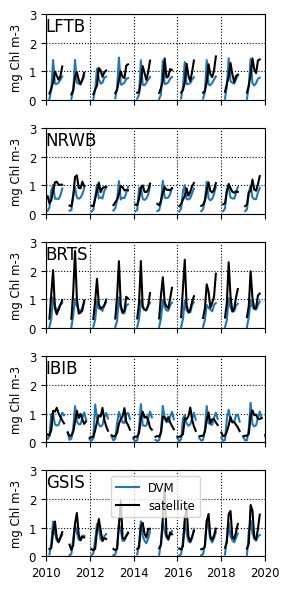

In [25]:
# vs Satellite CHL

date1chl = "2003"; date2chl = "2020"
nyear = int(date2chl) - int(date1chl) + 1
MODave = {}; MODstd = {}; OBSave = {}; OBSstd = {}

for ex in experiments:
    print(ex)
    expt = "expt_"+ex

    dataf = workdir + "/" + region + "/" + expt + "/data/"

    MODave[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]}
    MODstd[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]}
    OBSave[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]}
    OBSstd[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]}

    nc = NetCDFFile(dataf + "CHL_monthly_colocated_" + date1chl + "_" + date2chl + ".nc")
    satel = nc.variables["sat_mapped"][:,:,:]
    model = nc.variables["model_averaged"][:,:,:]
    nc.close()

    for r in MODave[experiments[0]].keys():
            for m in range(nyear*12):
                #print(e,r,m)
                s2D = satel[m,:,:]
                m2D = model[m,:,:]
                if np.size(m2D[REGmask[r]==1][~m2D[REGmask[r]==1].mask]) >= 100:
                    #print(r,m)
                    simulated = np.nanmean(m2D[REGmask[r]==1])
                    observed = np.nanmean(s2D[REGmask[r]==1])
                    MODave[ex][r].append( simulated )
                    OBSave[ex][r].append( observed )
                    if np.isnan( simulated ):
                        MODstd[ex][r].append(0.)
                    else:
                        MODstd[ex][r].append( np.nanstd(m2D[REGmask[r]==1]) )
                    
                    if np.isnan( simulated ):
                        OBSstd[ex][r].append(0.)
                    else:
                        OBSstd[ex][r].append( np.nanstd(s2D[REGmask[r]==1]) )
                else:
                    MODave[ex][r].append( np.nan )
                    MODstd[ex][r].append(0.)
                    OBSave[ex][r].append( np.nan )
                    OBSstd[ex][r].append(0.)

x = np.arange(len(MODave[experiments[0]]["LFTB"]))/12. + int(date1chl)

#figure=plt.figure(figsize=(18,12), dpi= 220, facecolor='w', edgecolor='k')
figure=plt.figure(figsize=(3,6), facecolor='w', edgecolor='k')

# p=1
# for r in ["LFTB","NRWB","BRTS","IBIB","GSIS"]:
#     ax=figure.add_subplot(5,1,p)
#     for ex in experiments:
#         plt.plot(x, MODave[ex][r],label=labels[ex],linewidth=thickness[ex],color=colors[ex])
#     plt.plot(x,OBSave[experiments[0]][r],label="satellite",color="k",linewidth=3)
#     plt.grid(color='k',linestyle=':')
#     plt.xlim(x.min(),x.max());
#     plt.ylim(0., 3.)
#     plt.title(r,loc="left",fontsize=12);
#     p = p + 1
# plt.legend()
# plt.tight_layout()

p=1
plotmin=2010
plotmax=2020
regs=["LFTB","NRWB","BRTS","IBIB","GSIS"]
for r in regs:
    ax=figure.add_subplot(5,1,p)
    for ex in experiments:
        plt.plot(x, MODave[ex][r],label=labels[ex],linewidth=1.5,color=colors[ex])
    plt.plot(x,OBSave[experiments[0]][r],label="satellite",color="k",linewidth=1.5)
    if p<len(regs): plt.gca().set_xticklabels([])
    plt.grid(color='k',linestyle=':')
    if plotmin is not None:
       plt.xlim(plotmin,plotmax); 
    else:
        plt.xlim(x.min(),x.max());
    plt.ylim(0., 3.)
    plt.ylabel('mg Chl m-3', fontsize='small')
    plt.text(0.0,0.8,r,transform=ax.transAxes,fontsize=12)
    ax.tick_params(axis='both', labelsize='small')
    #plt.title(r,loc="left",fontsize=12);
    p = p + 1
legend=plt.legend(loc="upper center", fontsize='small')
legend.set_zorder(2)
plt.tight_layout()

01.1


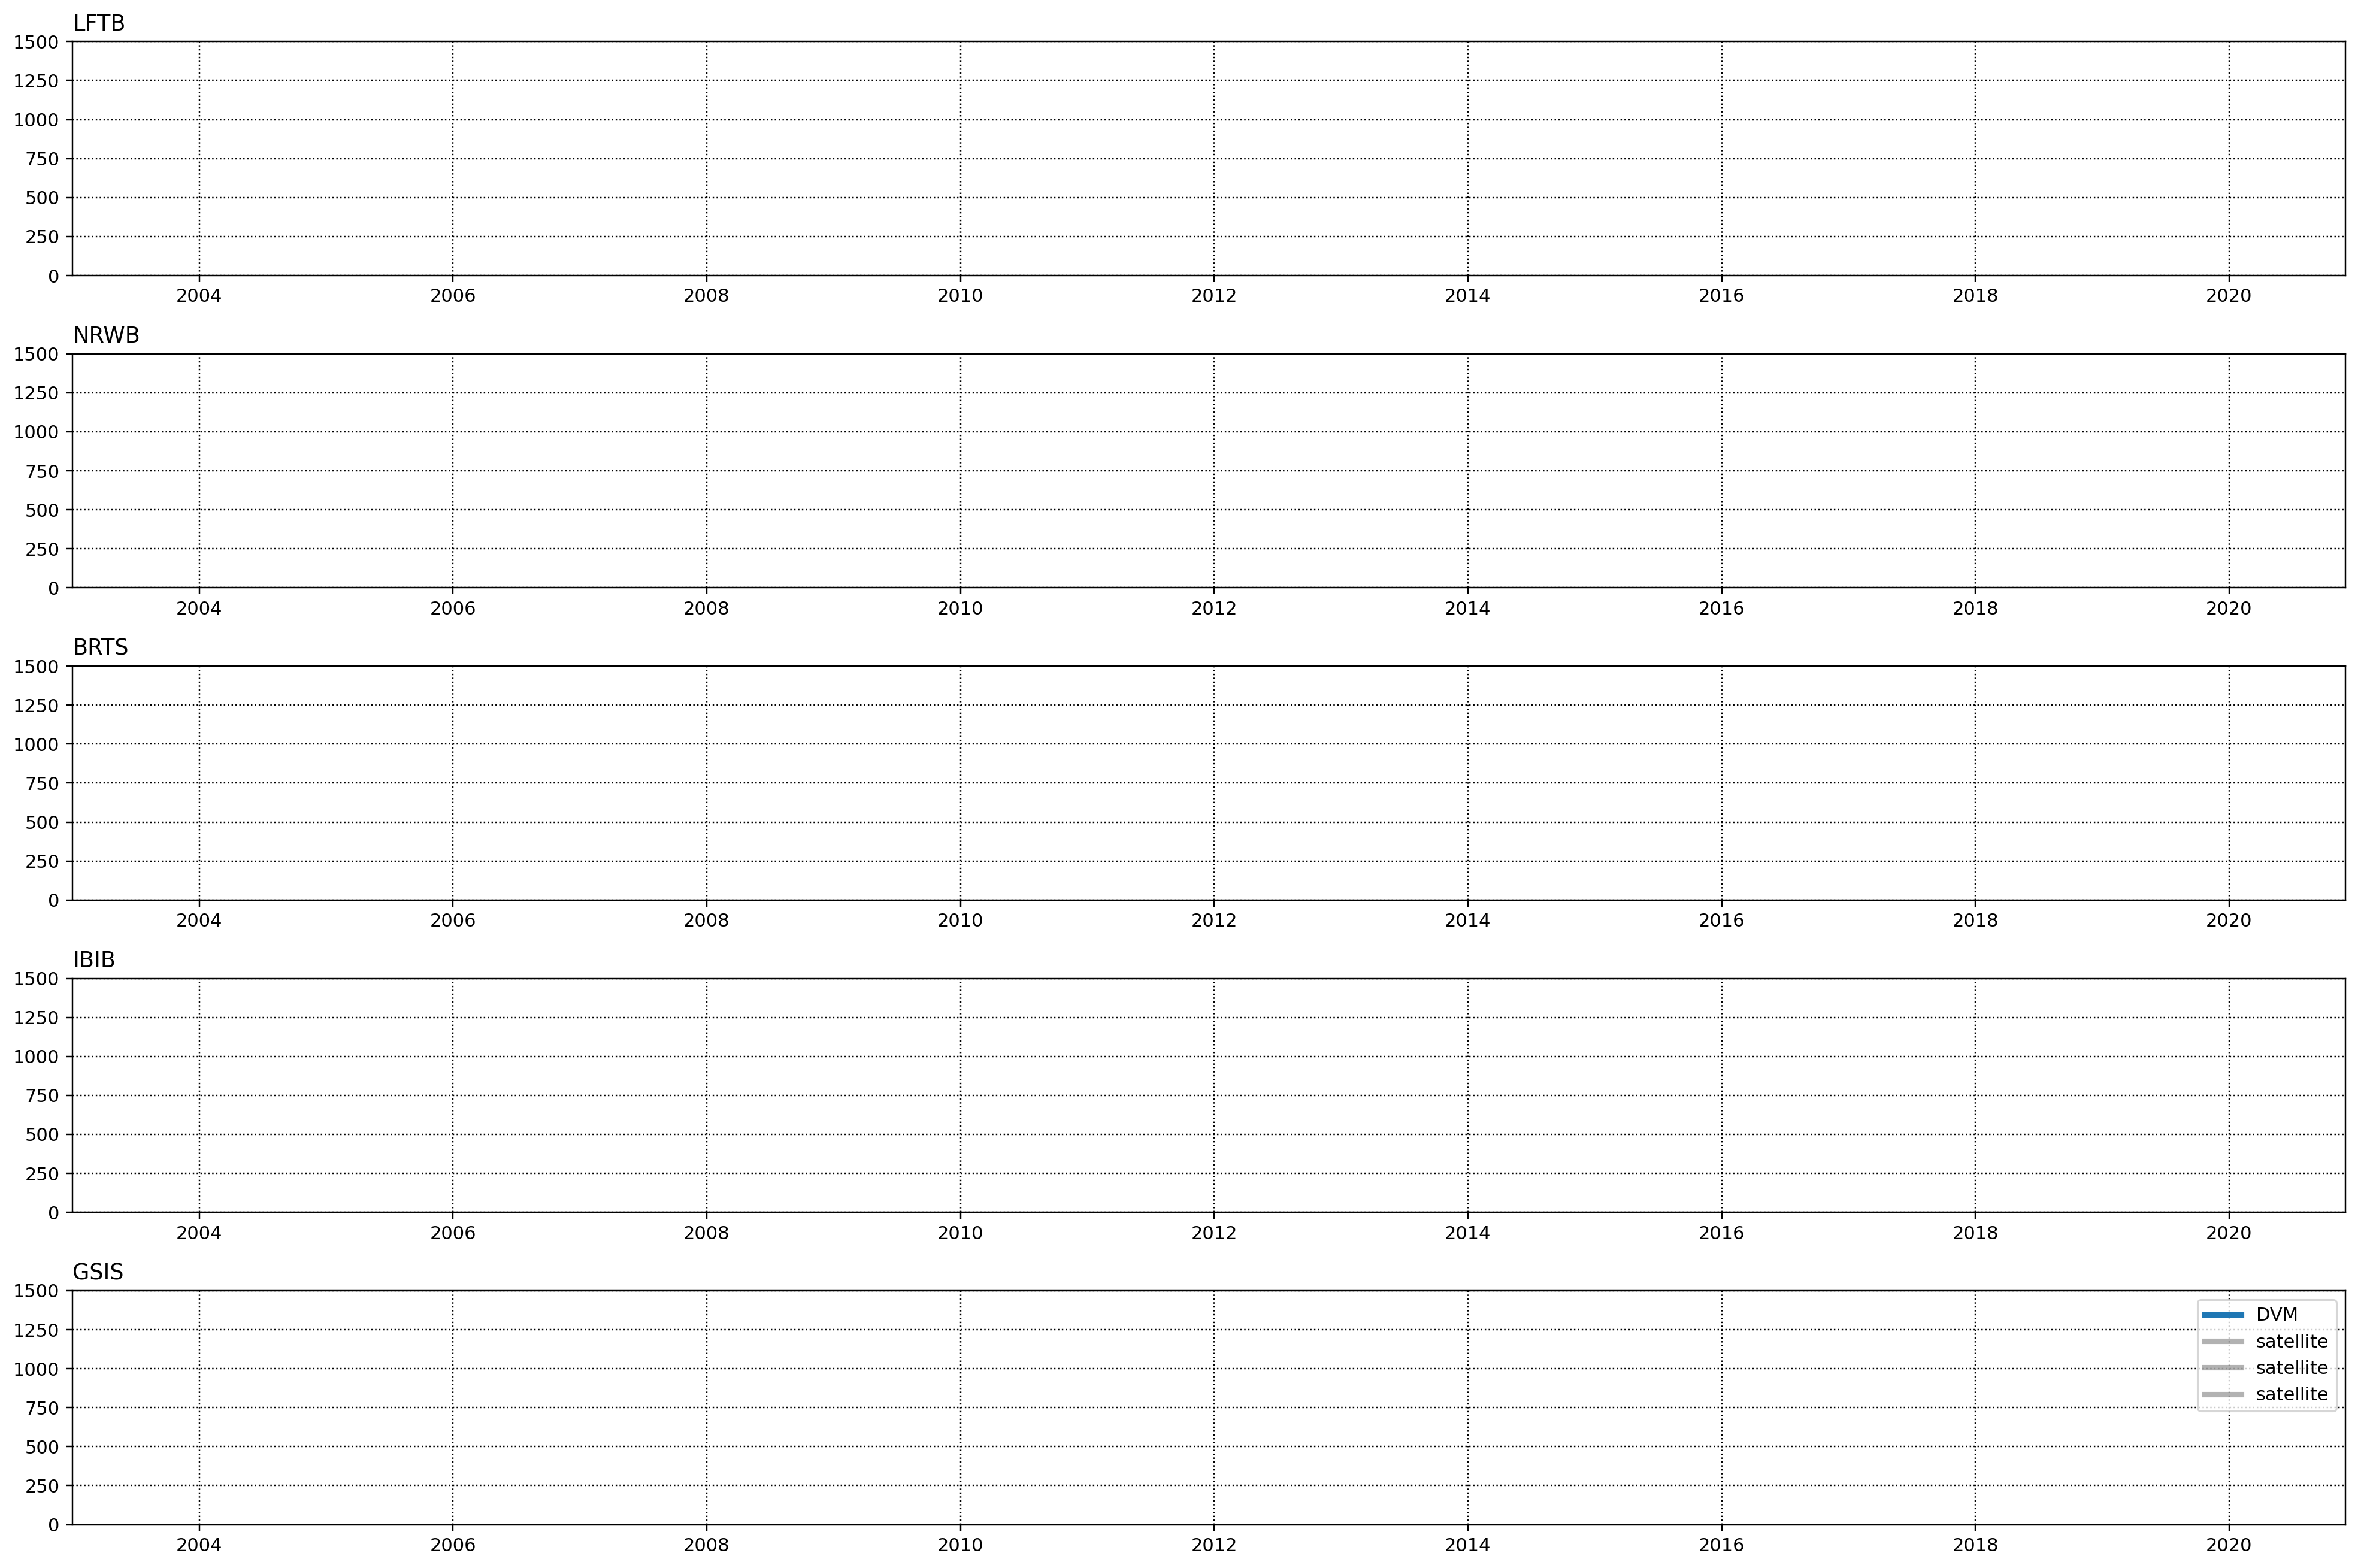

In [11]:
# vs Satellite PP

date1pp = "2003"; date2pp = "2020"
nyear = int(date2pp) - int(date1pp) + 1
MODave = {}; MODstd = {}; EPPLEYave = {}; EPPLEYstd = {}; CAFEave = {}; CAFEstd = {}
CBPMave = {}; CBPMstd = {}; VGPMave = {}; VGPMstd = {}

for ex in experiments:
    print(ex)
    expt = "expt_"+ex

    dataf = workdir + "/" + region + "/" + expt + "/data/"
    MODave[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]}
    MODstd[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]}
    EPPLEYave[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]}
    EPPLEYstd[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]}    
    CAFEave[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]}
    CAFEstd[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]} 
    CBPMave[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]}
    CBPMstd[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]} 
    VGPMave[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]}
    VGPMstd[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]} 

    nc = NetCDFFile(dataf + "NPP_monthly_colocated_" + date1pp + "_" + date2pp + ".nc")
    eppley = nc.variables["sat_mapped_eppley"][:,:,:]
    vgpm = nc.variables["sat_mapped_vgpm"][:,:,:]
    cbpm = nc.variables["sat_mapped_cbpm"][:,:,:]
    cafe = nc.variables["sat_mapped_cafe"][:,:,:]
    model = nc.variables["model_averaged_full"][:,:,:]
    nc.close()    

    for r in MODave[experiments[0]].keys():
            for m in range(nyear*12):
                #print(e,r,m)
                eppley2D = eppley[m,:,:]
                vgpm2D = vgpm[m,:,:]
                cbpm2D = cbpm[m,:,:]
                cafe2D = cafe[m,:,:]
                m2D = model[m,:,:]
                if np.size(eppley2D[REGmask[r]==1][~eppley2D[REGmask[r]==1].mask]) >= 50:
                    #print(r,m)
                    simulated = np.nanmean(m2D[REGmask[r]==1])
                    MODave[ex][r].append( simulated )

                    observed = np.nanmean(eppley2D[REGmask[r]==1])
                    EPPLEYave[ex][r].append( observed )
                    observed = np.nanmean(vgpm2D[REGmask[r]==1])
                    VGPMave[ex][r].append( observed )
                    observed = np.nanmean(cbpm2D[REGmask[r]==1])
                    CBPMave[ex][r].append( observed )
                    observed = np.nanmean(cafe2D[REGmask[r]==1])
                    CAFEave[ex][r].append( observed )

                    if np.isnan( simulated ):
                        MODstd[ex][r].append(0.)
                    else:
                        MODstd[ex][r].append( np.nanstd(m2D[REGmask[r]==1]) )
                    
                    if np.isnan( simulated ):
                        EPPLEYstd[ex][r].append(0.)
                        VGPMstd[ex][r].append(0.)
                        CBPMstd[ex][r].append(0.)
                        CAFEstd[ex][r].append(0.)
                    else:
                        EPPLEYstd[ex][r].append( np.nanstd(eppley2D[REGmask[r]==1]) )
                        VGPMstd[ex][r].append( np.nanstd(vgpm2D[REGmask[r]==1]) )
                        CBPMstd[ex][r].append( np.nanstd(cbpm2D[REGmask[r]==1]) )
                        CAFEstd[ex][r].append( np.nanstd(cafe2D[REGmask[r]==1]) )

                else:
                    MODave[ex][r].append( np.nan )
                    MODstd[ex][r].append(0.)
                    EPPLEYave[ex][r].append( np.nan )
                    EPPLEYstd[ex][r].append(0.)
                    VGPMave[ex][r].append( np.nan )
                    VGPMstd[ex][r].append(0.)
                    CBPMave[ex][r].append( np.nan )
                    CBPMstd[ex][r].append(0.)
                    CAFEave[ex][r].append( np.nan )
                    CAFEstd[ex][r].append(0.)

x = np.arange(len(MODave[experiments[0]]["LFTB"]))/12. + int(date1pp)

figure=plt.figure(figsize=(18,12), dpi= 220, facecolor='w', edgecolor='k')
p=1
for r in ["LFTB","NRWB","BRTS","IBIB","GSIS"]:
    ax=figure.add_subplot(5,1,p)
    for ex in experiments:
        plt.plot(x, MODave[ex][r],label=labels[ex],linewidth=thickness[ex],color=colors[ex])
    plt.plot(x,VGPMave[experiments[0]][r],label="satellite",color="k",linewidth=3,alpha=0.3)
    plt.plot(x,CBPMave[experiments[0]][r],label="satellite",color="k",linewidth=3,alpha=0.3)
    plt.plot(x,CAFEave[experiments[0]][r],label="satellite",color="k",linewidth=3,alpha=0.3)
    plt.grid(color='k',linestyle=':')
    plt.xlim(x.min(),x.max());
    plt.ylim(0., 1500.)
    plt.title(r,loc="left");

    p = p + 1

plt.legend()
plt.tight_layout()

In [12]:
print(MODave[ex]["BRTS"])

[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,

01.1


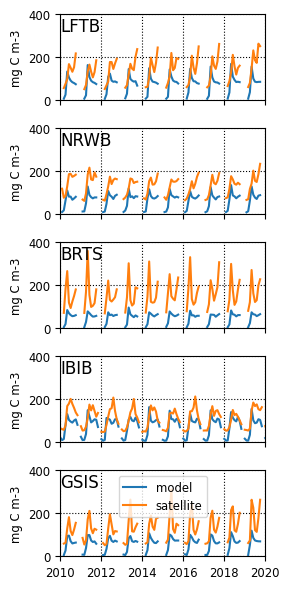

In [ ]:
# vs Satellite POC

date1poc = "2003"; date2poc = "2020"
nyear = int(date2poc) - int(date1poc) + 1
MODave = {}; MODstd = {}; OBSave = {}; OBSstd = {}

for ex in experiments:
    print(ex)
    expt = "expt_"+ex

    dataf = workdir + "/" + region + "/" + expt + "/data/"

    MODave[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]}
    MODstd[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]}
    OBSave[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]}
    OBSstd[ex] = {"LFTB":[],"NRWB":[],"BRTS":[],"IBIB":[],"GSIS":[]}

    nc = NetCDFFile(dataf + "POC_monthly_colocated_" + date1poc + "_" + date2poc + ".nc")
    satel = nc.variables["sat_mapped"][:,:,:]
    model = nc.variables["model_averaged"][:,:,:]
    nc.close()

    for r in MODave[experiments[0]].keys():
            for m in range(nyear*12):
                #print(e,r,m)
                s2D = satel[m,:,:]
                m2D = model[m,:,:]
                if np.size(m2D[REGmask[r]==1][~m2D[REGmask[r]==1].mask]) >= 100:
                    #print(r,m)
                    simulated = np.nanmean(m2D[REGmask[r]==1])
                    observed = np.nanmean(s2D[REGmask[r]==1])
                    MODave[ex][r].append( simulated )
                    OBSave[ex][r].append( observed )
                    if np.isnan( simulated ):
                        MODstd[ex][r].append(0.)
                    else:
                        MODstd[ex][r].append( np.nanstd(m2D[REGmask[r]==1]) )
                    
                    if np.isnan( simulated ):
                        OBSstd[ex][r].append(0.)
                    else:
                        OBSstd[ex][r].append( np.nanstd(s2D[REGmask[r]==1]) )
                else:
                    MODave[ex][r].append( np.nan )
                    MODstd[ex][r].append(0.)
                    OBSave[ex][r].append( np.nan )
                    OBSstd[ex][r].append(0.)

x = np.arange(len(MODave[experiments[0]]["LFTB"]))/12. + int(date1poc)

#figure=plt.figure(figsize=(18,12), dpi= 220, facecolor='w', edgecolor='k')
figure=plt.figure(figsize=(3,6), facecolor='w', edgecolor='k')

p=1
plotmin=2010
plotmax=2020
regs=["LFTB","NRWB","BRTS","IBIB","GSIS"]
for r in regs:
    ax=figure.add_subplot(5,1,p)
    for ex in experiments:
        plt.plot(x, MODave[ex][r],label=labels[ex],linewidth=1.5,color=colors[ex])
    plt.plot(x,OBSave[experiments[0]][r],label="satellite",color="k",linewidth=1.5)
    if p<len(regs): plt.gca().set_xticklabels([])
    plt.grid(color='k',linestyle=':')
    if plotmin is not None:
       plt.xlim(plotmin,plotmax); 
    else:
        plt.xlim(x.min(),x.max());
    plt.ylim(0., 400.)
    plt.ylabel('mg C m-3', fontsize='small')
    plt.text(0.0,0.8,r,transform=ax.transAxes,fontsize=12)
    ax.tick_params(axis='both', labelsize='small')
    #plt.title(r,loc="left",fontsize=12);
    p = p + 1
legend=plt.legend(loc="upper center", fontsize='small')
legend.set_zorder(2)
plt.tight_layout()

#figure.canvas.print_figure('./POC.vs.SAT.png',dpi=220)


In [8]:
date1=1990
date2=2020
expt = "expt_"+experiments[0]
dataf = workdir + "/" + region + "/" + expt + "/data/"
f = open(dataf + "climatology_integrates_"+str(date1)+"_"+str(date2)+".pckl","rb")
DIA,FLA,CCL,MIC,MES,MES750,PP,CHL, DOC, DOC100, DET, DET100 = pickle.load(f)
f.close()

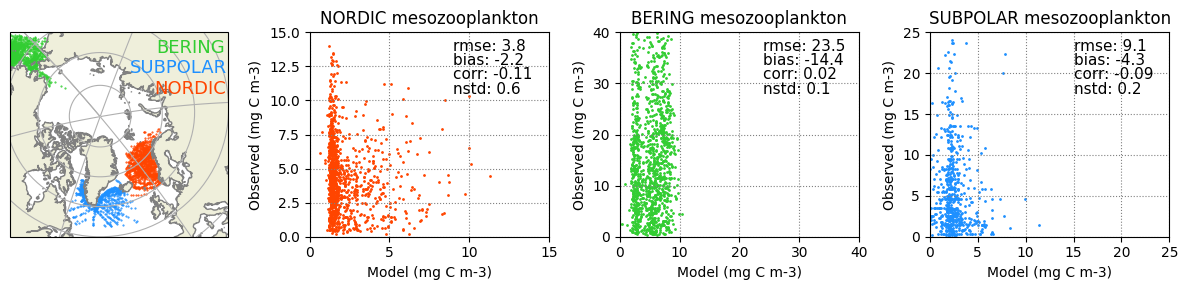

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import pickle

f = open('/cluster/projects/nn9481k/BGC.Validation/copepod'+region[0:3]+'.pckl','rb')
copepod = pickle.load(f)
f.close()

plon,plat = abplot.getgrid(region=region)
depthm = abplot.getdepth(region=region)

fig = plt.figure(figsize=[12, 3])
ax = plt.subplot(1, 4, 1, projection=\
     ccrs.Stereographic(central_latitude=70.0, central_longitude=-40.0, \
     false_easting=0.0, false_northing=0.0, true_scale_latitude=None, globe=None))
#ax.set_position([0.025,0.025,0.925,0.925])
ax.set_extent([-90, 92, 50, 90], ccrs.PlateCarree())
gl=ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False)

  
ax.add_feature(cartopy.feature.LAND)   # land is specified to plot above ...
ax.coastlines(resolution='50m',color='grey')

copepody = copepod[0,:,:]
copepody = np.ma.masked_where(copepody < 0.0, copepody)
copepody = np.ma.masked_where(depthm.mask, copepody)
index = ~copepody.mask

indexNOR = np.logical_and( np.logical_and(plon < 60.0, plat<76.0), np.logical_and(plat > 60.0, plon > -18.0) )
NORmask = ~copepody[indexNOR].mask
plt.scatter(plon[indexNOR][NORmask],plat[indexNOR][NORmask],s=1,transform=ccrs.PlateCarree(),color='orangered',marker='.')

indexSPG = np.logical_and( np.logical_and( plat<76.0, plon < -18.0),np.logical_and(plat>53.0, plon>-60.0) )
SPGmask = ~copepody[indexSPG].mask
plt.scatter(plon[indexSPG][SPGmask],plat[indexSPG][SPGmask],s=1,transform=ccrs.PlateCarree(),color='dodgerblue',marker='.')

indexBER = np.logical_or( np.logical_and( plat<76.0, plon < -150.0),np.logical_and(plat<76.0, plon>160.0) )
BERmask = ~copepody[indexBER].mask
plt.scatter(plon[indexBER][BERmask],plat[indexBER][BERmask],s=1,transform=ccrs.PlateCarree(),color='limegreen',marker='.')

plt.text(0.67,0.9,'BERING',transform=ax.transAxes,fontsize=13, color='limegreen')
plt.text(0.55,0.8,'SUBPOLAR',transform=ax.transAxes,fontsize=13, color='dodgerblue')
plt.text(0.66,0.7,'NORDIC',transform=ax.transAxes,fontsize=13, color='orangered')

model200 = MES[0][:,:]/200.
model750 = MES750[0][:,:]/750.

rmseNOR200 = rmse(model200[indexNOR][NORmask],copepody[indexNOR][NORmask])
biasNOR200 = bias(model200[indexNOR][NORmask],copepody[indexNOR][NORmask])
corrNOR200 = corr(model200[indexNOR][NORmask],copepody[indexNOR][NORmask])
nstdNOR200 = nstd(model200[indexNOR][NORmask],copepody[indexNOR][NORmask])

rmseSPG200 = rmse(model200[indexSPG][SPGmask],copepody[indexSPG][SPGmask])
biasSPG200 = bias(model200[indexSPG][SPGmask],copepody[indexSPG][SPGmask])
corrSPG200 = corr(model200[indexSPG][SPGmask],copepody[indexSPG][SPGmask])
nstdSPG200 = nstd(model200[indexSPG][SPGmask],copepody[indexSPG][SPGmask])

rmseBER200 = rmse(model200[indexBER][BERmask],copepody[indexBER][BERmask])
biasBER200 = bias(model200[indexBER][BERmask],copepody[indexBER][BERmask])
corrBER200 = corr(model200[indexBER][BERmask],copepody[indexBER][BERmask])
nstdBER200 = nstd(model200[indexBER][BERmask],copepody[indexBER][BERmask])

rmseNOR750 = rmse(model750[indexNOR][NORmask],copepody[indexNOR][NORmask])
biasNOR750 = bias(model750[indexNOR][NORmask],copepody[indexNOR][NORmask])
corrNOR750 = corr(model750[indexNOR][NORmask],copepody[indexNOR][NORmask])
nstdNOR750 = nstd(model750[indexNOR][NORmask],copepody[indexNOR][NORmask])

rmseSPG750 = rmse(model750[indexSPG][SPGmask],copepody[indexSPG][SPGmask])
biasSPG750 = bias(model750[indexSPG][SPGmask],copepody[indexSPG][SPGmask])
corrSPG750 = corr(model750[indexSPG][SPGmask],copepody[indexSPG][SPGmask])
nstdSPG750 = nstd(model750[indexSPG][SPGmask],copepody[indexSPG][SPGmask])

rmseBER750 = rmse(model750[indexBER][BERmask],copepody[indexBER][BERmask])
biasBER750 = bias(model750[indexBER][BERmask],copepody[indexBER][BERmask])
corrBER750 = corr(model750[indexBER][BERmask],copepody[indexBER][BERmask])
nstdBER750 = nstd(model750[indexBER][BERmask],copepody[indexBER][BERmask])

ax = plt.subplot(1, 4, 2)
#plt.scatter(model750[indexNOR][NORmask],copepody[indexNOR][NORmask],s=1, color='grey')
plt.scatter(model200[indexNOR][NORmask],copepody[indexNOR][NORmask],s=1, color='orangered')
plt.xlim(0,15)
plt.ylim(0,15)
plt.title('NORDIC mesozooplankton')
plt.xlabel('Model (mg C m-3)')
plt.ylabel('Observed (mg C m-3)')
plt.grid(linestyle=':',color='grey')

plt.text(0.6,0.91,'rmse: '+str(np.round(rmseNOR200,1)),transform=ax.transAxes,fontsize=11)
plt.text(0.6,0.84,'bias: '+str(np.round(biasNOR200,1)),transform=ax.transAxes,fontsize=11)
plt.text(0.6,0.77,'corr: '+str(np.round(corrNOR200,2)),transform=ax.transAxes,fontsize=11)
plt.text(0.6,0.70,'nstd: '+str(np.round(nstdNOR200,1)),transform=ax.transAxes,fontsize=11)
# plt.text(0.6,0.51,'rmse: '+str(np.round(rmseNOR750,1)),transform=ax.transAxes,fontsize=11)
# plt.text(0.6,0.44,'bias: '+str(np.round(biasNOR750,1)),transform=ax.transAxes,fontsize=11)
# plt.text(0.6,0.37,'corr: '+str(np.round(corrNOR750,2)),transform=ax.transAxes,fontsize=11)
# plt.text(0.6,0.30,'nstd: '+str(np.round(nstdNOR750,1)),transform=ax.transAxes,fontsize=11)

ax = plt.subplot(1, 4, 3)
#plt.scatter(model750[indexBER][BERmask],copepody[indexBER][BERmask],s=1, color='grey')
plt.scatter(model200[indexBER][BERmask],copepody[indexBER][BERmask],s=1, color='limegreen')
plt.xlim(0,40)
plt.ylim(0,40)
plt.title('BERING mesozooplankton')
plt.xlabel('Model (mg C m-3)')
plt.ylabel('Observed (mg C m-3)')
plt.grid(linestyle=':',color='grey')

plt.text(0.6,0.91,'rmse: '+str(np.round(rmseBER200,1)),transform=ax.transAxes,fontsize=11)
plt.text(0.6,0.84,'bias: '+str(np.round(biasBER200,1)),transform=ax.transAxes,fontsize=11)
plt.text(0.6,0.77,'corr: '+str(np.round(corrBER200,2)),transform=ax.transAxes,fontsize=11)
plt.text(0.6,0.70,'nstd: '+str(np.round(nstdBER200,1)),transform=ax.transAxes,fontsize=11)
# plt.text(0.6,0.51,'rmse: '+str(np.round(rmseBER750,1)),transform=ax.transAxes,fontsize=11)
# plt.text(0.6,0.44,'bias: '+str(np.round(biasBER750,1)),transform=ax.transAxes,fontsize=11)
# plt.text(0.6,0.37,'corr: '+str(np.round(corrBER750,2)),transform=ax.transAxes,fontsize=11)
# plt.text(0.6,0.30,'nstd: '+str(np.round(nstdBER750,1)),transform=ax.transAxes,fontsize=11)

ax = plt.subplot(1, 4, 4)
#plt.scatter(model750[indexSPG][SPGmask],copepody[indexSPG][SPGmask],s=1, color='grey')
plt.scatter(model200[indexSPG][SPGmask],copepody[indexSPG][SPGmask],s=1, color='dodgerblue')
plt.xlim(0,25)
plt.ylim(0,25)
plt.title('SUBPOLAR mesozooplankton')
plt.xlabel('Model (mg C m-3)')
plt.ylabel('Observed (mg C m-3)')
plt.grid(linestyle=':',color='grey')

plt.text(0.6,0.91,'rmse: '+str(np.round(rmseSPG200,1)),transform=ax.transAxes,fontsize=11)
plt.text(0.6,0.84,'bias: '+str(np.round(biasSPG200,1)),transform=ax.transAxes,fontsize=11)
plt.text(0.6,0.77,'corr: '+str(np.round(corrSPG200,2)),transform=ax.transAxes,fontsize=11)
plt.text(0.6,0.70,'nstd: '+str(np.round(nstdSPG200,1)),transform=ax.transAxes,fontsize=11)
# plt.text(0.6,0.51,'rmse: '+str(np.round(rmseSPG750,1)),transform=ax.transAxes,fontsize=11)
# plt.text(0.6,0.44,'bias: '+str(np.round(biasSPG750,1)),transform=ax.transAxes,fontsize=11)
# plt.text(0.6,0.37,'corr: '+str(np.round(corrSPG750,2)),transform=ax.transAxes,fontsize=11)
# plt.text(0.6,0.30,'nstd: '+str(np.round(nstdSPG750,1)),transform=ax.transAxes,fontsize=11)

plt.tight_layout()

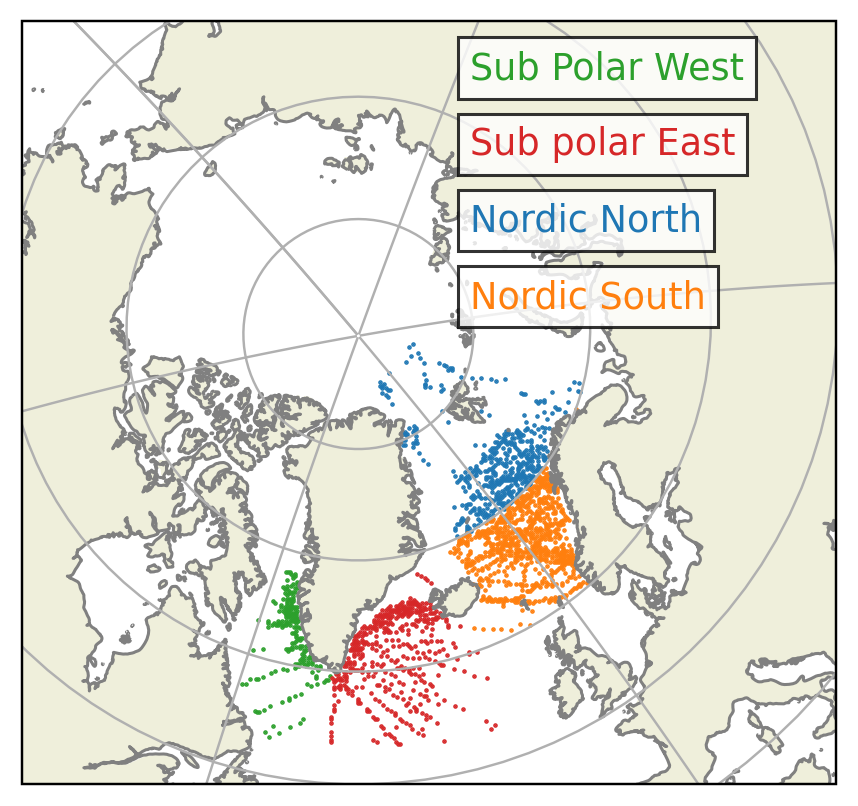

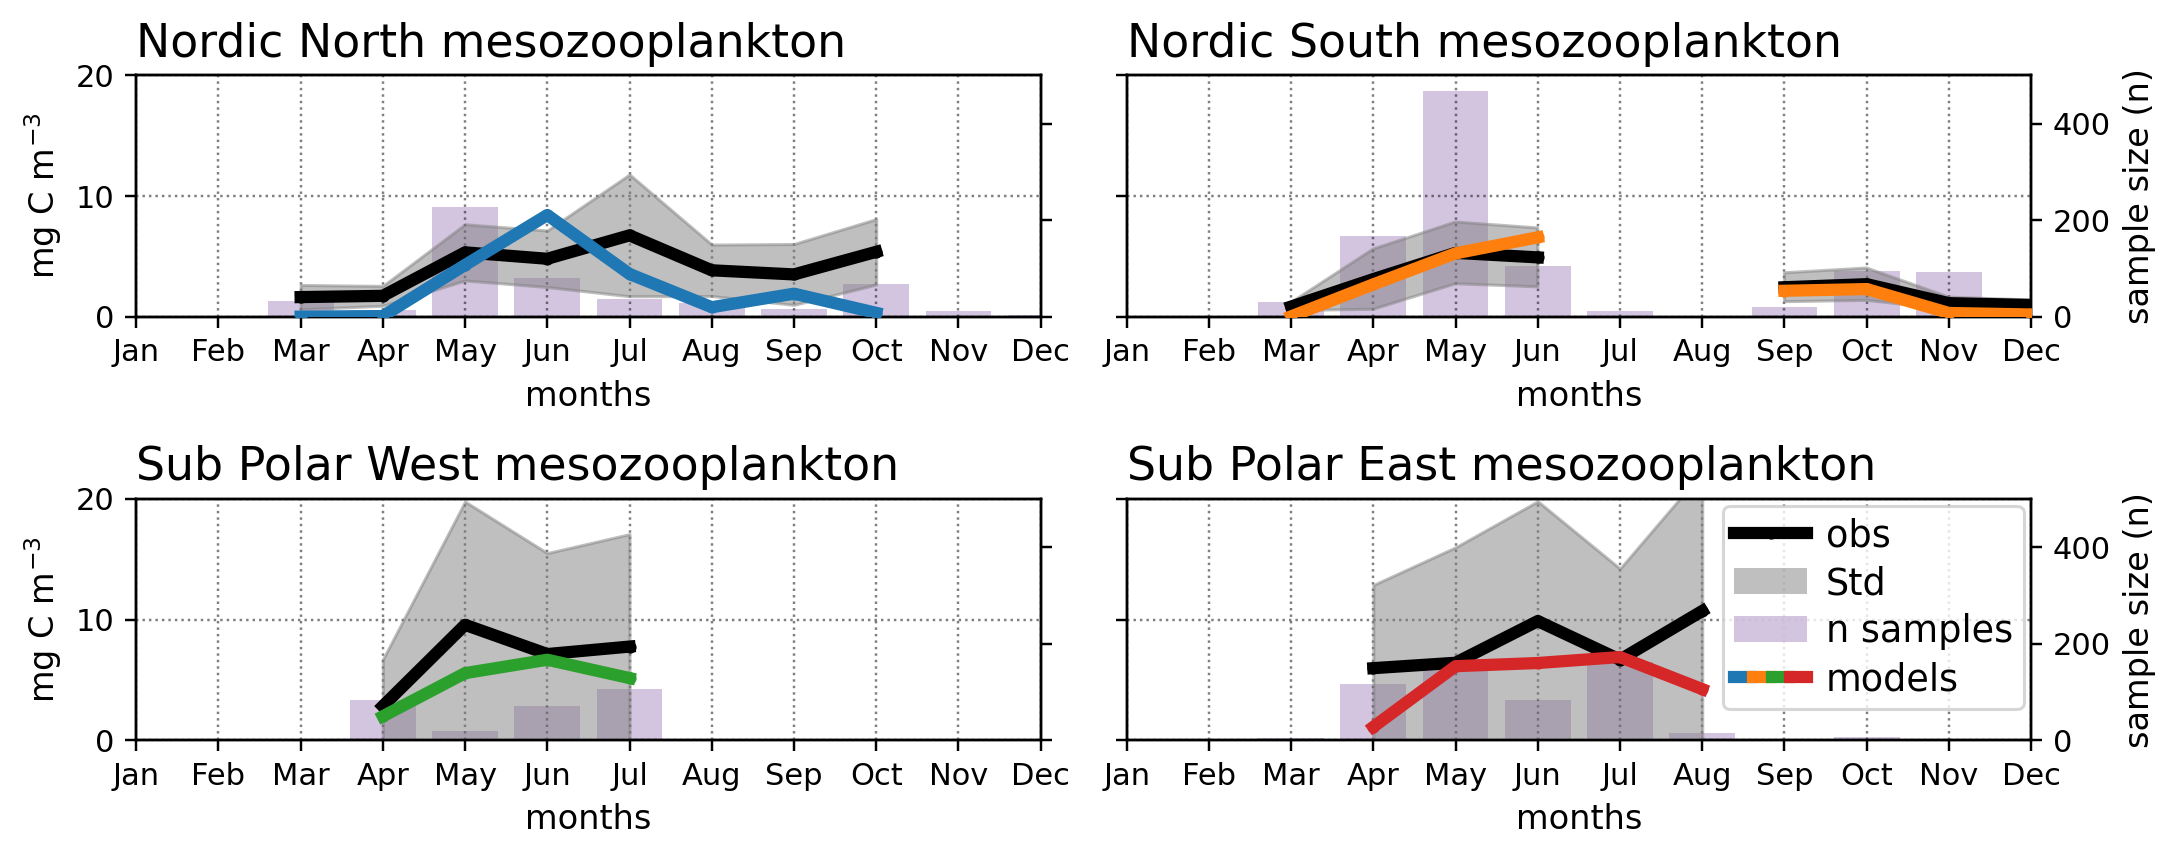

In [14]:
import pickle
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import abplot
import numpy as np
f = open('/cluster/projects/nn9481k/BGC.Validation/copepod'+region[0:3]+'.pckl','rb')
copepod = pickle.load(f)
f.close()

plon,plat = abplot.getgrid(region=region)
depthm = abplot.getdepth(region=region)

# fig = plt.figure(figsize=[12, 3])
# ax = plt.subplot(1, 4, 1, projection=\
#      ccrs.Stereographic(central_latitude=70.0, central_longitude=-40.0, \
#      false_easting=0.0, false_northing=0.0, true_scale_latitude=None, globe=None))
# #ax.set_position([0.025,0.025,0.925,0.925])
# ax.set_extent([-90, 92, 50, 90], ccrs.PlateCarree())
# gl=ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False)

  
# ax.add_feature(cartopy.feature.LAND)   # land is specified to plot above ...
# ax.coastlines(resolution='50m',color='grey')

# copepody = copepod[0,:,:]
# copepody = np.ma.masked_where(copepody < 0.0, copepody)
# copepody = np.ma.masked_where(depthm.mask, copepody)
# index = np.logical_and(~copepody.mask, REGmask['Greenland'])
# plt.scatter(plon[index],plat[index],s=1,transform=ccrs.PlateCarree(),color='b',marker='.')
copepody = copepod[0,:,:] # 0 is annual
copepody = np.ma.masked_where(copepody < 0.0, copepody)
copepody = np.ma.masked_where(depthm.mask, copepody)
index = np.logical_and(~copepody.mask,np.logical_and( np.logical_and(plat > 70.0, plat<=86.0), np.logical_and(plon > -18, plon < 60.0) ))
NORnmask = index
index = np.logical_and(~copepody.mask,np.logical_and( np.logical_and(plat > 60.0, plat<=70.0), np.logical_and(plon > -18.0, plon < 60.0) ))
NORsmask = index
index = np.logical_and(~copepody.mask,np.logical_and( np.logical_and( plat<76.0, plat > 53.0),np.logical_and(plon < -45.0, plon>-80.0) ))
SPGwmask = index
index = np.logical_and(~copepody.mask,np.logical_and( np.logical_and( plat<76.0, plat > 53.0),np.logical_and(plon < -18.0, plon>-45.0) ))
SPGemask = index

aveMES = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[],"Nordic North":[],"Nordic South":[],"Sub Polar West":[],"Sub Polar East":[]}
aveobs = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[],"Nordic North":[],"Nordic South":[],"Sub Polar West":[],"Sub Polar East":[]}
stdobs = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[],"Nordic North":[],"Nordic South":[],"Sub Polar West":[],"Sub Polar East":[]} 
size = {"LFTB":[],"NRWB":[],"BRTS":[],"GSIS":[],"Nordic North":[],"Nordic South":[],"Sub Polar West":[],"Sub Polar East":[]}
for m in range(12):
  model = MES[m+1][:,:]/200.
  copepody = copepod[m+1,:,:] # 0 is annual
  copepody = np.ma.masked_where(copepody < 0.0, copepody)
  copepody = np.ma.masked_where(depthm.mask, copepody)
  for r in ["LFTB","NRWB","BRTS","GSIS","Nordic North","Nordic South","Sub Polar West","Sub Polar East"]:
    if r in ["LFTB","NRWB","BRTS","GSIS"]:
      index = np.logical_and(~copepody.mask, REGmask[r])
    if r == 'Nordic North':
       index = np.logical_and(~copepody.mask,np.logical_and( np.logical_and(plat > 70.0, plat<=86.0), np.logical_and(plon > -18, plon < 60.0) ))
    if r == 'Nordic South':
       index = np.logical_and(~copepody.mask,np.logical_and( np.logical_and(plat > 60.0, plat<=70.0), np.logical_and(plon > -18.0, plon < 60.0) ))   
    if r == 'Sub Polar West':
       index = np.logical_and(~copepody.mask,np.logical_and( np.logical_and( plat<76.0, plat > 53.0),np.logical_and(plon < -45.0, plon>-80.0) ))
    if r == 'Sub Polar East':
       index = np.logical_and(~copepody.mask,np.logical_and( np.logical_and( plat<76.0, plat > 53.0),np.logical_and(plon < -18.0, plon>-45.0) ))
     
    try:
      
      size[r].append(len(copepody[index]))
      if len(copepody[index]) >= 14:
        aveMES[r].append( np.nanmean(model[index]) )
        aveobs[r].append( np.nanmean(copepody[index])) 
        stdobs[r].append( np.nanstd(copepody[index])) 
      else:
        aveMES[r].append( -999.0 )
        aveobs[r].append( -999.0 )
        stdobs[r].append( -999.0 )         

    except:
      aveMES[r].append( -999.0 )
      aveobs[r].append( -999.0 )
      stdobs[r].append( -999.0 )
      size[r].append(0)
    
# plt.scatter(np.array(aveMES070['NorwegianS']),np.array(aveobs['NorwegianS']))
# plt.xlim(0,12)
# plt.ylim(0,12)


fig=plt.figure(figsize=(4,4), dpi= 220, facecolor='w', edgecolor='k')
ax=fig.add_subplot(1,1,1, projection=\
     ccrs.Stereographic(central_latitude=70.0, central_longitude=-40.0, \
     false_easting=0.0, false_northing=0.0, true_scale_latitude=None, globe=None))
ax.set_extent([-90, 92, 50, 90], ccrs.PlateCarree())
gl=ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False)
ax.add_feature(cartopy.feature.LAND)   # land is specified to plot above ...
ax.coastlines(resolution='50m',color='grey')

plt.scatter(plon[NORnmask],plat[NORnmask],s=1,transform=ccrs.PlateCarree(),color='C0',marker='.')
plt.scatter(plon[NORsmask],plat[NORsmask],s=1,transform=ccrs.PlateCarree(),color='C1',marker='.')
plt.scatter(plon[SPGwmask],plat[SPGwmask],s=1,transform=ccrs.PlateCarree(),color='C2',marker='.')
plt.scatter(plon[SPGemask],plat[SPGemask],s=1,transform=ccrs.PlateCarree(),color='C3',marker='.')
plt.text(0.55,0.925,'Sub Polar West',transform=ax.transAxes,fontsize=12, color='C2',bbox=dict(facecolor='white', edgecolor='k', alpha=0.8))
plt.text(0.55,0.825,'Sub polar East',transform=ax.transAxes,fontsize=12, color='C3',bbox=dict(facecolor='white', edgecolor='k', alpha=0.8))
plt.text(0.55,0.725,'Nordic North',transform=ax.transAxes,fontsize=12, color='C0',bbox=dict(facecolor='white', edgecolor='k', alpha=0.8))
plt.text(0.55,0.625,'Nordic South',transform=ax.transAxes,fontsize=12,color='C1',bbox=dict(facecolor='white', edgecolor='k', alpha=0.8)) 

plt.tight_layout()
fig.canvas.print_figure('./mapMES.png',dpi=220)

import numpy as np
import matplotlib.pyplot as plt
import calendar
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple


figure = plt.figure(figsize=(10, 4), dpi=220, facecolor='w', edgecolor='k')
x = np.arange(len(aveMES[r])) + 1 # /12. + int(date1)
# Regions and colors
region_order = ["Nordic North", "Nordic South", "Sub Polar West", "Sub Polar East"]
colors = ["orangered", "darkorange", "dodgerblue", "turquoise"]
colors = ['#FF800E','#C85200','#006BA4','#5F9ED1']
colors = ['C0','C1','C2','C3']
region_color = dict(zip(region_order, colors))

# Build a compact legend: obs, Std, n samples, and ONE 'models' entry with all model colors grouped
obs_handle   = Line2D([], [], color='k', marker='o', linestyle='-', linewidth=4, markersize=3, label='obs')
std_handle   = Patch(facecolor='gray', alpha=0.5, label='Std')
ns_handle    = Patch(facecolor='#C5B0D5', alpha=0.75, label='n samples')
models_tuple = tuple(Line2D([], [], color=region_color[r], linestyle='-', linewidth=4) for r in region_order)

legend_handles = [obs_handle, std_handle, ns_handle, models_tuple]
legend_labels  = ['obs', 'Std', 'n samples', 'models']

def infer_bar_width(x):
    x = np.asarray(x)
    if x.size > 1 and np.issubdtype(x.dtype, np.number):
        dx = np.min(np.diff(np.unique(x)))
        return 0.8 * dx
    if np.issubdtype(x.dtype, np.datetime64):
        return 25  # ~25 days for monthly bars
    return 0.8

bar_width = infer_bar_width(x)

for p, r in enumerate(region_order, start=1):
    arrM = np.array(aveMES[r]); arrM = np.ma.masked_where(arrM < -990.0, arrM)
    arrO = np.array(aveobs[r])   ; arrO = np.ma.masked_where(arrO < -990.0, arrO)
    arrS = np.array(stdobs[r])   ; arrS = np.ma.masked_where(arrS < -990.0, arrS)
    n    = np.array(size[r])     ; n    = np.ma.masked_invalid(n)

    ax = figure.add_subplot(2, 2, p)
    ax2 = ax.twinx()

    # Bars (pink) as background, no legend label here
    ax2.bar(
        x, n, width=bar_width,
        color='#C5B0D5', alpha=0.75, edgecolor='none',
        label='_nolegend_', zorder=0, align='center'
    )
    ax.set_zorder(2); ax2.set_zorder(1)
    ax.patch.set_alpha(0.0)

    # Lines + std band (foreground), suppress per-axes legend labels
    stdmin = arrO - arrS
    stdmax = arrO + arrS
    ax.fill_between(x, stdmin, stdmax, color='gray', alpha=0.5, label='_nolegend_', zorder=2)
    ax.plot(x, arrO, linestyle="-", marker="o", markersize=3, color="k",
            label='_nolegend_', linewidth=4, zorder=3)
    ax.plot(x, arrM, linestyle="-", marker="o", markersize=3, color=region_color[r],
            label='_nolegend_', linewidth=4, zorder=3)

    # Formatting
    ax.grid(color='k', linestyle=':', alpha=0.5)
    ax.set_xlim(np.min(x), np.max(x))
    ax.set_ylim(0., 20.)
    ax.set_title(f"{r} mesozooplankton", loc="left", fontsize=15)
    ax.set_xlabel('months', fontsize=11)

    # Right axis fixed 0–500; show label only on 2 & 4
    ax2.set_ylim(0, 500)
    ax2.grid(False)

    # X labels: Jan, Feb, Mar, ...
    x_arr = np.asarray(x)
    if np.issubdtype(x_arr.dtype, np.datetime64):
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    else:
        months_abbr = [calendar.month_abbr[i] for i in range(1, 13)]
        ax.set_xticks(x)
        ax.set_xticklabels(months_abbr)

    # Show y-labels selectively
    if p in (1, 3):
        ax.set_ylabel("mg C m$^{-3}$", fontsize=11)
        ax.tick_params(labelleft=True)
    else:
        ax.set_ylabel(None)
        ax.tick_params(labelleft=False)

    if p in (2, 4):
        ax2.set_ylabel("sample size (n)", fontsize=11)
        ax2.tick_params(labelright=True)
    else:
        ax2.set_ylabel(None)
        ax2.tick_params(labelright=False)

    # Legend only on subplot 4, compact, with a single 'models' entry bundling all model colors
    if p == 4:
        ax.legend(
            legend_handles, legend_labels,
            handler_map={tuple: HandlerTuple(ndivide=None, pad=0.05)},
            loc='upper right', frameon=True, fontsize=12,
            handlelength=2.0, handletextpad=0.5,
            borderpad=0.3, labelspacing=0.3, borderaxespad=0.2
        )

plt.tight_layout()
figure.canvas.print_figure('./MES.png',dpi=220)
plt.show()


dict_keys(['model', 'obs', 'depth', 'lat', 'lon', 'date'])
45.38781999999999
[datetime.datetime(2003, 6, 20, 0, 0) datetime.datetime(2003, 6, 20, 0, 0)
 datetime.datetime(2003, 6, 20, 0, 0) ...
 datetime.datetime(2014, 6, 29, 0, 0) datetime.datetime(2014, 6, 29, 0, 0)
 datetime.datetime(2014, 6, 29, 0, 0)]


<Figure size 640x480 with 0 Axes>

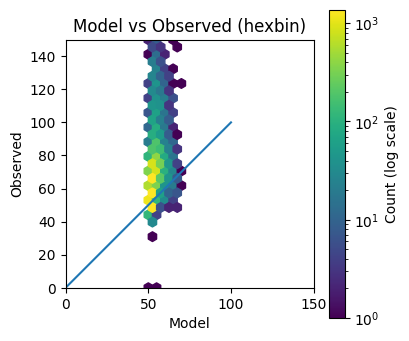

sample size NOR:  1586
sample size SPG:  1590
sample size ARCC:  2929
sample size ARCE:  5210
(380, 400)
x [ 1  2  3  4  5  6  7  8  9 10 11 12]
n [0 0 0 0 0 0 89 565 179 221 100 0]
n [0 0 0 23 38 207 89 0 70 0 71 5]
n [0 11 17 19 17 202 354 928 1456 1376 296 86]


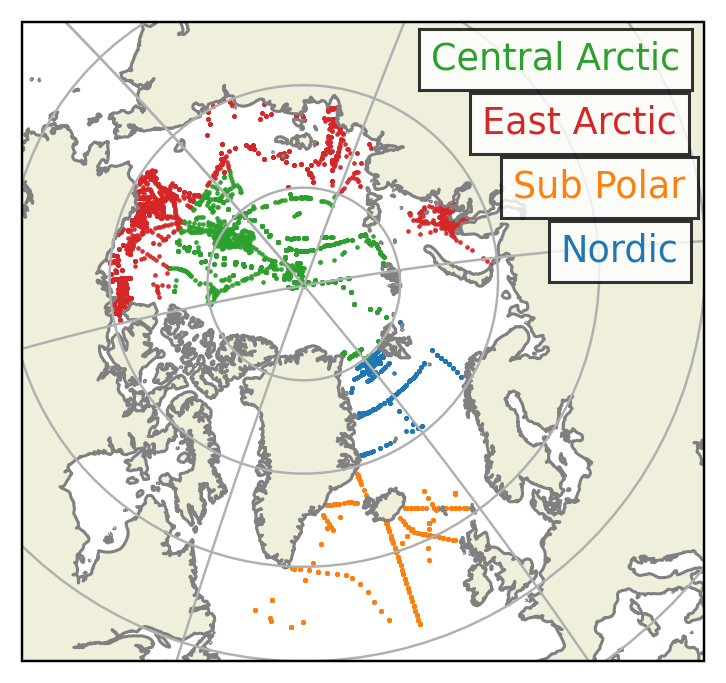

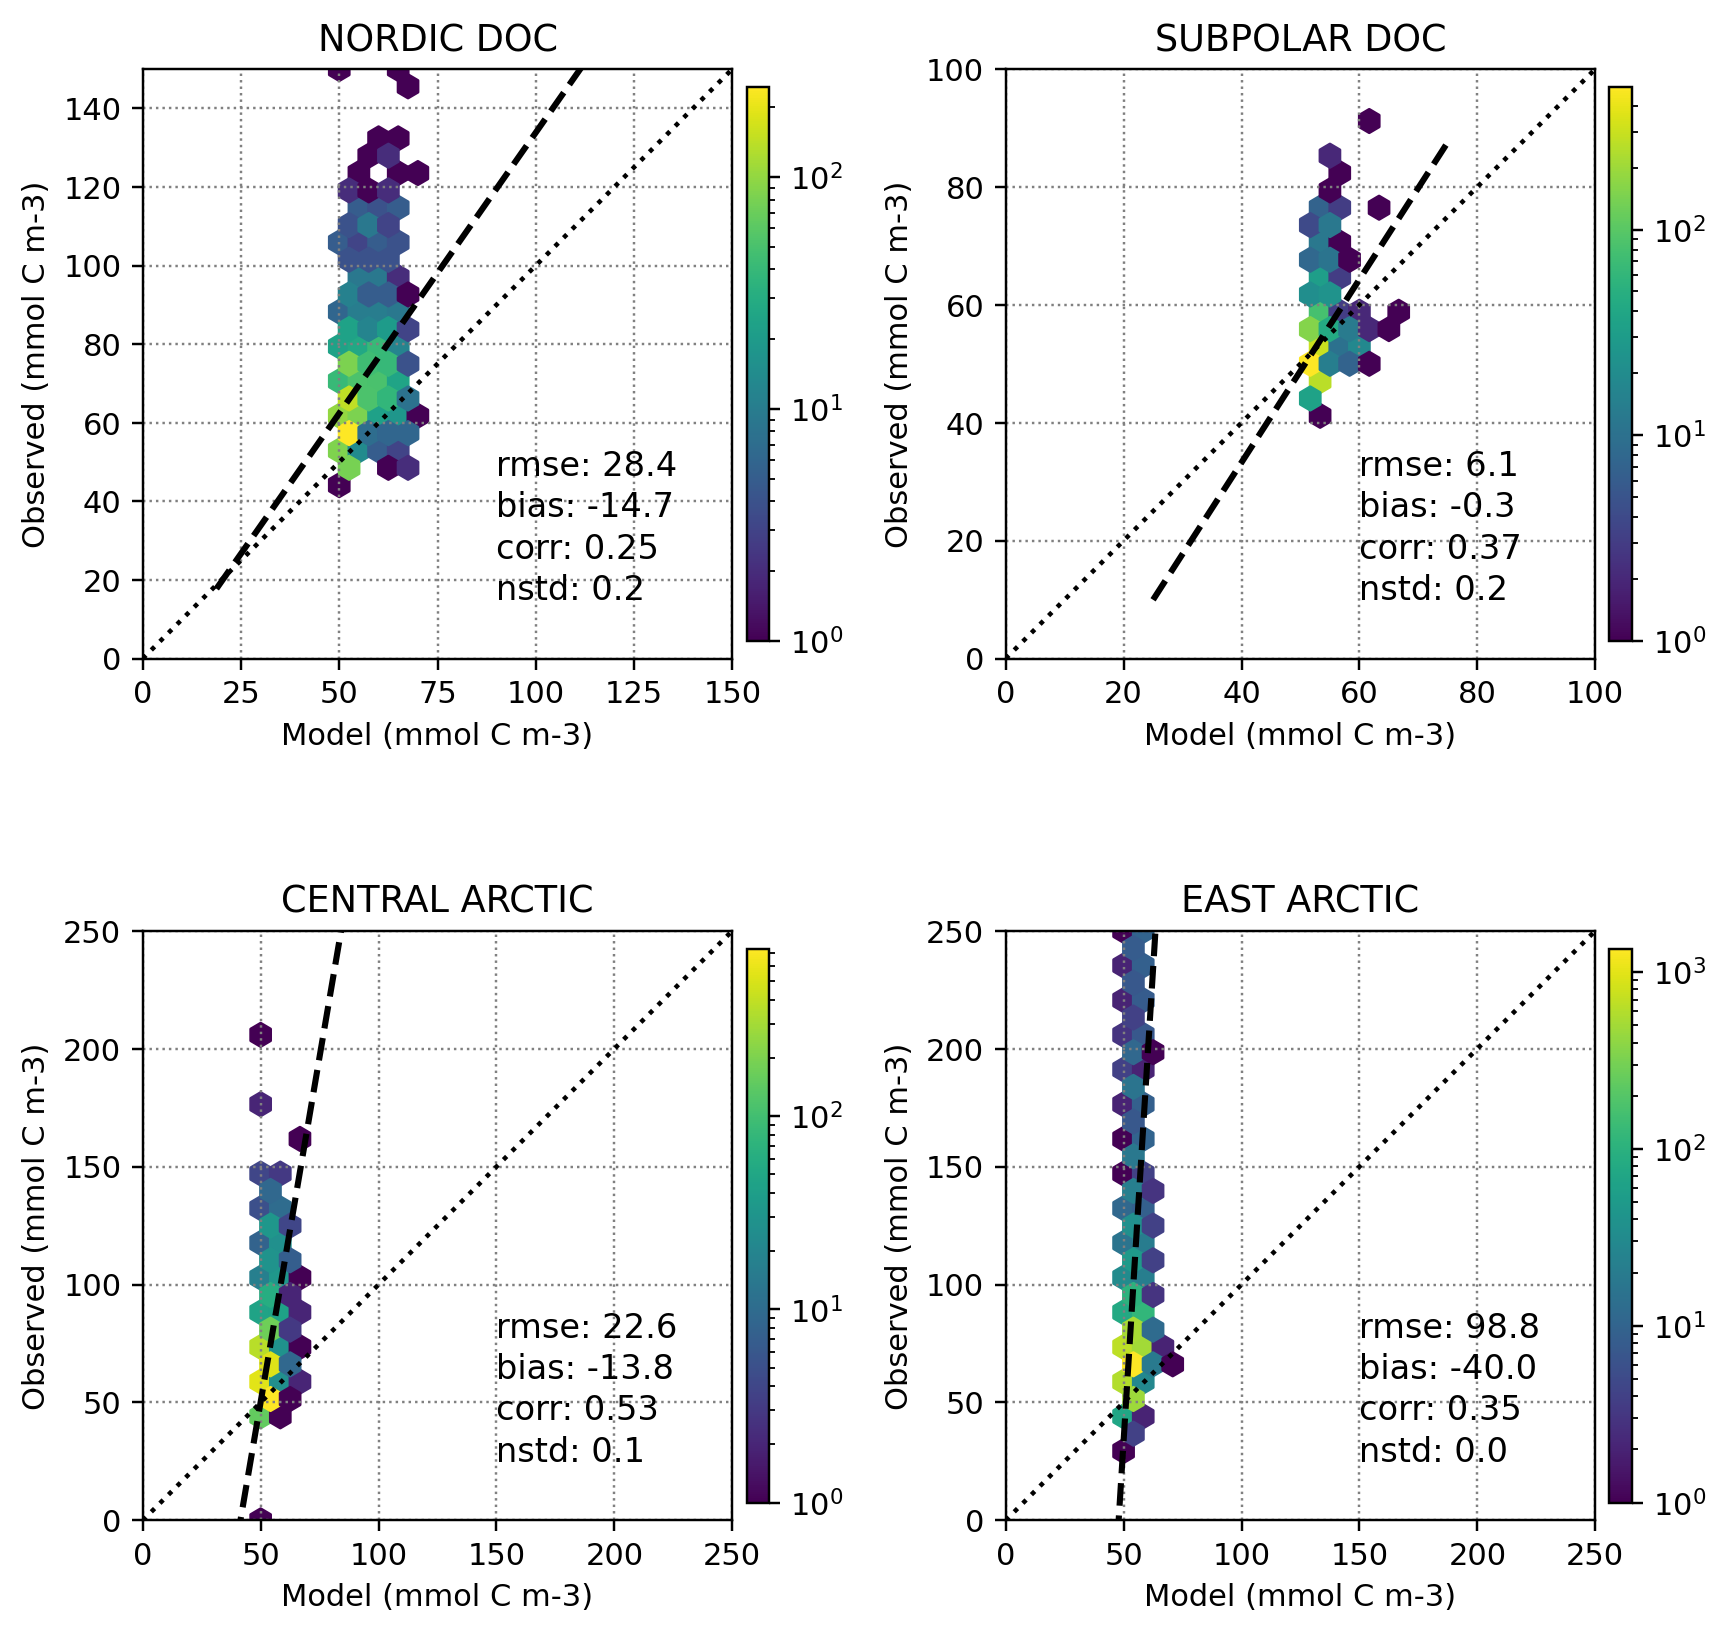

<Figure size 2640x495 with 0 Axes>

In [9]:
import pickle
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature

from scipy.stats import linregress

expt = "expt_"+experiments[0]
dataf = workdir + "/" + region + "/" + expt + "/data/"

date1 = 1990
date2 = 2020

f = open(dataf+'DOC.Model.Colocated.'+ str(date1) + '_' + str(date2) +'.pckl','rb')
doco = pickle.load(f)
f.close()
print(doco.keys())
d = np.array(doco['depth'])

obslon = np.array(doco['lon'])[d<=20000]
obslat = np.array(doco['lat'])[d<=20000]
obs = (np.array(doco['obs'])[d<=20000])*1.025 #
#model = np.array(doco['model'])[d<=20000]/12.01+44.0
model = np.array(doco['model'])[d<=20000]/12.01+52.0
#model = np.array(doco['model'])[d<=20000]/12.01+56.0
print(np.percentile(obs,1))
dat = np.array(doco['date'])
print(dat)
plt.figure()
# plt.scatter(model,obs,s=1,color='C0',marker='.')
# plt.scatter(model52,obs,s=1,color='C1',marker='.')
# plt.scatter(model56,obs,s=1,color='C2',marker='.')

# plt.xlim(0,100)
# plt.ylim(0,100)
# plt.plot([0,100],[0,100])



x = np.asarray(model)
y = np.asarray(obs)
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

fig, ax = plt.subplots(figsize=(4, 4))

# Use extent to align binning with your limits (optional but nice if you hard-limit to 0–100)
hb = ax.hexbin(x, y,
               gridsize=30,
               bins='log',
               mincnt=1,
               cmap='viridis',
               extent=(0, 150, 0, 150))

ax.set(xlim=(0, 150), ylim=(0, 150))
ax.set_aspect('equal', adjustable='box')  # <- prevents stretched hexes

cb = fig.colorbar(hb, ax=ax)
cb.set_label('Count (log scale)')

ax.set_xlabel('Model')
ax.set_ylabel('Observed')
ax.set_title('Model vs Observed (hexbin)')
plt.plot([0,100],[0,100])
plt.show()



plon,plat = abplot.getgrid(region='TP2a0.10')

figmap = plt.figure(figsize=(4, 4), dpi=220, facecolor='w', edgecolor='k')
ax = plt.subplot(1, 1, 1, projection=\
     ccrs.Stereographic(central_latitude=70.0, central_longitude=-40.0, \
     false_easting=0.0, false_northing=0.0, true_scale_latitude=None, globe=None))
#ax.set_position([0.025,0.025,0.925,0.925])
ax.set_extent([-90, 92, 50, 90], ccrs.PlateCarree())
gl=ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=False)

  
ax.add_feature(cartopy.feature.LAND)   # land is specified to plot above ...
ax.coastlines(resolution='50m',color='grey')

#plt.scatter(obslon,obslat,s=1,transform=ccrs.PlateCarree(),color='k',marker='.')

indexNOR = np.logical_and( np.logical_and(obslon < 55.0, obslat<80), np.logical_and(obslat > 70.0, obslon > -25.0) )
indexNORall = np.logical_and( np.logical_and(plon < 55.0, plat<80), np.logical_and(plat > 70.0, plon > -25.0) )
plt.scatter(obslon[indexNOR],obslat[indexNOR],s=1,transform=ccrs.PlateCarree(),color='C0',marker='.')

indexSPG = np.logical_and( np.logical_and( obslat<70.0, obslon < 0.0),np.logical_and(obslat>50.0, obslon>-60.0) )
indexSPGall = np.logical_and( np.logical_and( plat<70.0, plon < 0.0),np.logical_and(plat>50.0, plon>-60.0) )
plt.scatter(obslon[indexSPG],obslat[indexSPG],s=1,transform=ccrs.PlateCarree(),color='C1',marker='.')

#indexARC = np.logical_or( np.logical_and(obslat<=81.75, obslon<=-60), np.logical_and(obslat<=81.75, obslon>=60))
indexARC = np.logical_or( np.logical_or( obslat>=80,np.logical_and( obslat>=70, obslon < -120) ), np.logical_and(obslon > 85.0, obslon<180)) 
indexARCall = np.logical_or( np.logical_or( plat>=80,np.logical_and( plat>=70, plon < -120) ), np.logical_and(plon > 85.0, plon<180)) 
#indexARC = np.logical_and(np.logical_and(obslat<=81.75, obslon<=-60), obslat>70)

indexARCE = np.logical_or( np.logical_or(
    np.logical_and( np.logical_and(obslat<76, obslat>=70) , obslon< -120 ) , 
    np.logical_and( np.logical_and(obslat<80, obslat>=68) , np.logical_and( obslon> 55, obslon< 170 ) ) ),
    np.logical_and( np.logical_and(obslat<76, obslat>=70) , obslon>= 170 )
)
plt.scatter(obslon[indexARCE],obslat[indexARCE],s=1,transform=ccrs.PlateCarree(),color='C3',marker='.')

indexARCC = np.logical_or(obslat>=80, np.logical_and(obslat >= 76.0, np.logical_or(obslon>170,obslon<=-120)))
plt.scatter(obslon[indexARCC],obslat[indexARCC],s=1,transform=ccrs.PlateCarree(),color='C2',marker='.')

plt.text(0.6,0.925,'Central Arctic',transform=ax.transAxes,fontsize=12,color='C2',bbox=dict(facecolor='white', edgecolor='k', alpha=0.8)) 
plt.text(0.675,0.825,'East Arctic',transform=ax.transAxes,fontsize=12, color='C3',bbox=dict(facecolor='white', edgecolor='k', alpha=0.8))
plt.text(0.72,0.725,'Sub Polar',transform=ax.transAxes,fontsize=12, color='C1',bbox=dict(facecolor='white', edgecolor='k', alpha=0.8))
plt.text(0.79,0.625,'Nordic',transform=ax.transAxes,fontsize=12, color='C0',bbox=dict(facecolor='white', edgecolor='k', alpha=0.8))

rmseNOR = rmse(model[indexNOR],obs[indexNOR])
biasNOR = bias(model[indexNOR],obs[indexNOR])
corrNOR = corr(model[indexNOR],obs[indexNOR])
nstdNOR = nstd(model[indexNOR],obs[indexNOR])

rmseSPG = rmse(model[indexSPG],obs[indexSPG])
biasSPG = bias(model[indexSPG],obs[indexSPG])
corrSPG = corr(model[indexSPG],obs[indexSPG])
nstdSPG = nstd(model[indexSPG],obs[indexSPG])

rmseARCC = rmse(model[indexARCC],obs[indexARCC])
biasARCC = bias(model[indexARCC],obs[indexARCC])
corrARCC = corr(model[indexARCC],obs[indexARCC])
nstdARCC = nstd(model[indexARCC],obs[indexARCC])

rmseARCE = rmse(model[indexARCE],obs[indexARCE])
biasARCE = bias(model[indexARCE],obs[indexARCE])
corrARCE = corr(model[indexARCE],obs[indexARCE])
nstdARCE = nstd(model[indexARCE],obs[indexARCE])

figmap.canvas.print_figure('./DOCmap.png',dpi=220)

fig = plt.figure(figsize=(8, 8), dpi=220, facecolor='w', edgecolor='k')
ax2 = plt.subplot(2, 2, 1)
ymax = 150
plt.plot([0,ymax],[0,ymax], linestyle=':', color='k')
#plt.scatter(model[indexNOR],obs[indexNOR],s=1, color='C0')
hb = ax2.hexbin(model[indexNOR], obs[indexNOR],
               gridsize=30,
               bins='log',
               mincnt=1,
               cmap='viridis',
               extent=(0, 150, 0, 150))
ax2.set_aspect('equal', adjustable='box')  # <- prevents stretched hexes

cb = fig.colorbar(hb, ax=ax2, shrink=0.7, pad=0.02, aspect=25)

slope, intercept, r, p, se = linregress(model[indexNOR], obs[indexNOR])

xs = np.linspace(ymax*0.125, ymax*0.75, 100)
ys = intercept + slope * xs
ax2.plot(xs, ys, color='k', lw=2,linestyle='--',
         label=f'y = {slope:.3f}x + {intercept:.3f}  (R²={r**2:.3f})')

print('sample size NOR: ',len(model[indexNOR]))
plt.xlim(0,150)
plt.ylim(0,150)
plt.title('NORDIC DOC')
plt.xlabel('Model (mmol C m-3)')
plt.ylabel('Observed (mmol C m-3)')
plt.grid(linestyle=':',color='grey')

plt.text(0.6,0.31,'rmse: '+str(np.round(rmseNOR,1)),transform=ax2.transAxes,fontsize=11)
plt.text(0.6,0.24,'bias: '+str(np.round(biasNOR,1)),transform=ax2.transAxes,fontsize=11)
plt.text(0.6,0.17,'corr: '+str(np.round(corrNOR,2)),transform=ax2.transAxes,fontsize=11)
plt.text(0.6,0.10,'nstd: '+str(np.round(nstdNOR,1)),transform=ax2.transAxes,fontsize=11)

ax3 = plt.subplot(2, 2, 2)
ymax = 100
plt.plot([0,ymax],[0,ymax], linestyle=':', color='k')
#plt.scatter(model[indexSPG],obs[indexSPG],s=1, color='C1')
hb = ax3.hexbin(model[indexSPG], obs[indexSPG],
               gridsize=30,
               bins='log',
               mincnt=1,
               cmap='viridis',
               extent=(0, 100, 0, 100))
ax3.set_aspect('equal', adjustable='box')  # <- prevents stretched hexes

cb = fig.colorbar(hb, ax=ax3, shrink=0.7, pad=0.02, aspect=25)

slope, intercept, r, p, se = linregress(model[indexSPG], obs[indexSPG])

xs = np.linspace(ymax*0.25, ymax*0.75, 100)
ys = intercept + slope * xs
ax3.plot(xs, ys, color='k', lw=2,linestyle='--',
         label=f'y = {slope:.3f}x + {intercept:.3f}  (R²={r**2:.3f})')

print('sample size SPG: ',len(model[indexSPG]))
plt.xlim(0,ymax)
plt.ylim(0,ymax)
plt.title('SUBPOLAR DOC')
plt.xlabel('Model (mmol C m-3)')
plt.ylabel('Observed (mmol C m-3)')
plt.grid(linestyle=':',color='grey')

plt.text(0.6,0.31,'rmse: '+str(np.round(rmseSPG,1)),transform=ax3.transAxes,fontsize=11)
plt.text(0.6,0.24,'bias: '+str(np.round(biasSPG,1)),transform=ax3.transAxes,fontsize=11)
plt.text(0.6,0.17,'corr: '+str(np.round(corrSPG,2)),transform=ax3.transAxes,fontsize=11)
plt.text(0.6,0.10,'nstd: '+str(np.round(nstdSPG,1)),transform=ax3.transAxes,fontsize=11)

ax4 = plt.subplot(2, 2, 3)
ymax = 250
plt.plot([0,ymax],[0,ymax], linestyle=':', color='k')
#plt.scatter(model[indexARC],obs[indexARC],s=1, color='C2')

hb = ax4.hexbin(model[indexARCC], obs[indexARCC],
               gridsize=30,
               bins='log',
               mincnt=1,
               cmap='viridis',
               extent=(0, 250, 0, 250))
ax4.set_aspect('equal', adjustable='box')  # <- prevents stretched hexes

cb = fig.colorbar(hb, ax=ax4, shrink=0.7, pad=0.02, aspect=25)

slope, intercept, r, p, se = linregress(model[indexARCC], obs[indexARCC])

xs = np.linspace(ymax*0.1, ymax*0.5, 100)
ys = intercept + slope * xs
ax4.plot(xs, ys, color='k', lw=2,linestyle='--',
         label=f'y = {slope:.3f}x + {intercept:.3f}  (R²={r**2:.3f})')

print('sample size ARCC: ',len(model[indexARCC]))
plt.xlim(0,ymax)
plt.ylim(0,ymax)
plt.title('CENTRAL ARCTIC')
plt.xlabel('Model (mmol C m-3)')
plt.ylabel('Observed (mmol C m-3)')
plt.grid(linestyle=':',color='grey')

plt.text(0.6,0.31,'rmse: '+str(np.round(rmseARCC,1)),transform=ax4.transAxes,fontsize=11)
plt.text(0.6,0.24,'bias: '+str(np.round(biasARCC,1)),transform=ax4.transAxes,fontsize=11)
plt.text(0.6,0.17,'corr: '+str(np.round(corrARCC,2)),transform=ax4.transAxes,fontsize=11)
plt.text(0.6,0.10,'nstd: '+str(np.round(nstdARCC,1)),transform=ax4.transAxes,fontsize=11)

ax5 = plt.subplot(2, 2, 4)
ymax = 250
plt.plot([0,ymax],[0,ymax], linestyle=':', color='k')
#plt.scatter(model[indexARC],obs[indexARC],s=1, color='C2')

hb = ax5.hexbin(model[indexARCE], obs[indexARCE],
               gridsize=30,
               bins='log',
               mincnt=1,
               cmap='viridis',
               extent=(0, 250, 0, 250))
ax5.set_aspect('equal', adjustable='box')  # <- prevents stretched hexes

cb = fig.colorbar(hb, ax=ax5, shrink=0.7, pad=0.02, aspect=25)

slope, intercept, r, p, se = linregress(model[indexARCE], obs[indexARCE])

xs = np.linspace(ymax*0.1, ymax*0.5, 100)
ys = intercept + slope * xs
ax5.plot(xs, ys, color='k', lw=2,linestyle='--',
         label=f'y = {slope:.3f}x + {intercept:.3f}  (R²={r**2:.3f})')

print('sample size ARCE: ',len(model[indexARCE]))
plt.xlim(0,ymax)
plt.ylim(0,ymax)
plt.title('EAST ARCTIC')
plt.xlabel('Model (mmol C m-3)')
plt.ylabel('Observed (mmol C m-3)')
plt.grid(linestyle=':',color='grey')

plt.text(0.6,0.31,'rmse: '+str(np.round(rmseARCE,1)),transform=ax5.transAxes,fontsize=11)
plt.text(0.6,0.24,'bias: '+str(np.round(biasARCE,1)),transform=ax5.transAxes,fontsize=11)
plt.text(0.6,0.17,'corr: '+str(np.round(corrARCE,2)),transform=ax5.transAxes,fontsize=11)
plt.text(0.6,0.10,'nstd: '+str(np.round(nstdARCE,1)),transform=ax5.transAxes,fontsize=11)

plt.tight_layout()

fig.canvas.print_figure('./DOC.png',dpi=220)

import numpy as np
import matplotlib.pyplot as plt
import calendar
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

aveDOC = {"Nordic":[],"Sub Polar":[],"Central Arctic":[]}
aveDOCall = {"Nordic":[],"Sub Polar":[],"Central Arctic":[]} 
aveobs = {"Nordic":[],"Sub Polar":[],"Central Arctic":[]}
stdobs = {"Nordic":[],"Sub Polar":[],"Central Arctic":[]} 
size = {"Nordic":[],"Sub Polar":[],"Central Arctic":[]}

print(DOC[0][:,:].shape)
for m in range(12):

    #monthind = [i for i, dd in enumerate(dat) if d.month == int(m+1)]
    monthind = np.array([dd.month == int(m) for dd in dat])
    for r in ["Nordic","Sub Polar","Central Arctic"]:
     if r == "Nordic": 
             index = np.logical_and(np.logical_and(indexNOR,monthind),d<=100)
             indexall = indexNORall
     if r == "Sub Polar": 
             index = np.logical_and(np.logical_and(indexSPG,monthind),d<=100)
             indexall = indexSPGall
     if r == "Central Arctic": 
             index = np.logical_and(np.logical_and(indexARC,monthind),d<=100)
             indexall = indexARCall
    #  aveDOCall[r].append( np.nanmean(DOC[m][0,:,:][indexall])/12.01 )
     try:
      
      size[r].append(len(obs[index]))

      if len(obs[index]) >= 14:
        aveDOC[r].append( np.nanmean(model[index]) )
        
        aveobs[r].append( np.nanmean(obs[index])) 
        stdobs[r].append( np.nanstd(obs[index])) 
      else:
        aveDOC[r].append( -999.0 )
#        aveDOCall[r].append( -999.0 )
        aveobs[r].append( -999.0 )
        stdobs[r].append( -999.0 )         

     except:
      aveDOC[r].append( -999.0 )
#      aveDOCall[r].append( -999.0 )
      aveobs[r].append( -999.0 )
      stdobs[r].append( -999.0 )
      size[r].append(0)          

figure2 = plt.figure(figsize=(12, 2.25), dpi=220, facecolor='w', edgecolor='k')
x = np.arange(len(aveDOC[r])) + 1 # /12. + int(date1)
print('x',x)
# Regions and colors
region_order = ["Nordic","Sub Polar","Central Arctic"]
colors = ["orangered", "darkorange", "dodgerblue", "turquoise"]
colors = ['#FF800E','#C85200','#006BA4','#5F9ED1']
colors = ['C0','C1','C2','C3']
region_color = dict(zip(region_order, colors))

# Build a compact legend: obs, Std, n samples, and ONE 'models' entry with all model colors grouped
obs_handle   = Line2D([], [], color='k', marker='o', linestyle='-', linewidth=4, markersize=3, label='obs')
std_handle   = Patch(facecolor='gray', alpha=0.5, label='Std')
ns_handle    = Patch(facecolor='#C5B0D5', alpha=0.75, label='n samples')
models_tuple = tuple(Line2D([], [], color=region_color[r], linestyle='-', linewidth=4) for r in region_order)

legend_handles = [obs_handle, std_handle, ns_handle, models_tuple]
legend_labels  = ['obs', 'Std', 'n samples', 'models']

def infer_bar_width(x):
    x = np.asarray(x)
    if x.size > 1 and np.issubdtype(x.dtype, np.number):
        dx = np.min(np.diff(np.unique(x)))
        return 0.8 * dx
    if np.issubdtype(x.dtype, np.datetime64):
        return 25  # ~25 days for monthly bars
    return 0.8

bar_width = infer_bar_width(x)

for p, r in enumerate(region_order, start=1):
    arrM = np.array(aveDOC[r]); arrM = np.ma.masked_where(arrM < -990.0, arrM)
    # arrA = np.array(aveDOCall[r]); arrA = np.ma.masked_where(arrA < -990.0, arrA)
    arrO = np.array(aveobs[r])   ; arrO = np.ma.masked_where(arrO < -990.0, arrO)
    arrS = np.array(stdobs[r])   ; arrS = np.ma.masked_where(arrS < -990.0, arrS)
    n    = np.array(size[r])     ; n    = np.ma.masked_invalid(n)
    print('n',n)
    ax = figure.add_subplot(1, 3, p)
    ax2 = ax.twinx()

    # Bars (pink) as background, no legend label here
    ax2.bar(
        x, n, width=bar_width,
        color='#C5B0D5', alpha=0.75, edgecolor='none',
        label='_nolegend_', zorder=0, align='center'
    )
    ax.set_zorder(2); ax2.set_zorder(1)
    ax.patch.set_alpha(0.0)

    # Lines + std band (foreground), suppress per-axes legend labels
    stdmin = arrO - arrS
    stdmax = arrO + arrS
    ax.fill_between(x, stdmin, stdmax, color='gray', alpha=0.5, label='_nolegend_', zorder=2)
    ax.plot(x, arrO, linestyle="-", marker="o", markersize=3, color="k",
            label='_nolegend_', linewidth=4, zorder=3)
    ax.plot(x, arrM, linestyle="-", marker="o", markersize=3, color=region_color[r],
            label='_nolegend_', linewidth=4, zorder=3)
    # ax.plot(x, arrA, linestyle="-", marker="o", markersize=3, color=region_color[r],
    #         label='_nolegend_', linewidth=4, zorder=3, alpha=0.7)

    # Formatting
    ax.grid(color='k', linestyle=':', alpha=0.5)
    ax.set_xlim(np.min(x), np.max(x))
    ax.set_ylim(0., 150.)
    ax.set_title(f"{r} DOC", loc="left", fontsize=15)
    ax.set_xlabel('months', fontsize=11)

    # Right axis fixed 0–500; show label only on 2 & 4
    ax2.set_ylim(0, 2000)
    ax2.grid(False)

    # X labels: Jan, Feb, Mar, ...
    x_arr = np.asarray(x)
    if np.issubdtype(x_arr.dtype, np.datetime64):
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    else:
        months_abbr = [calendar.month_abbr[i] for i in range(1, 13)]
        ax.set_xticks(x)
        ax.set_xticklabels(months_abbr)

    # Show y-labels selectively
    if p == 1:
        ax.set_ylabel("mmol C m$^{-3}$", fontsize=11)
        ax.tick_params(labelleft=True)
    else:
        ax.set_ylabel(None)
        ax.tick_params(labelleft=False)

    if p == 3:
        ax2.set_ylabel("sample size (n)", fontsize=11)
        ax2.tick_params(labelright=True)
    else:
        ax2.set_ylabel(None)
        ax2.tick_params(labelright=False)

    # Legend only on subplot 4, compact, with a single 'models' entry bundling all model colors
    if p == 1:
        ax.legend(
            legend_handles, legend_labels,
            handler_map={tuple: HandlerTuple(ndivide=None, pad=0.05)},
            loc='upper left', frameon=True, fontsize=12,
            handlelength=2.0, handletextpad=0.5,
            borderpad=0.3, labelspacing=0.3, borderaxespad=0.2
        )

plt.tight_layout()
plt.show()

dict_keys(['model1d', 'model1m', 'argo1d', 'argo1m', 'depth1d', 'lat1d', 'lon1d', 'date1d', 'lat1m', 'lon1m', 'date1m'])


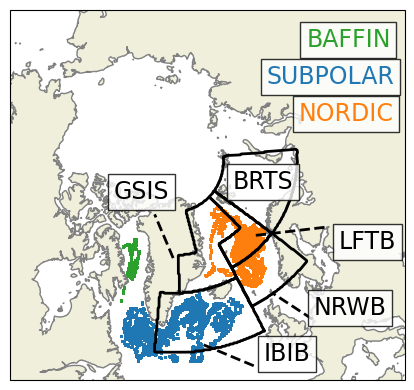

In [6]:
import pickle
import matplotlib.pylab as plt
%matplotlib inline
import numpy as np

expt = "expt_"+experiments[0]
dataf = workdir + "/" + region + "/" + expt + "/data/"

date1 = 1990
date2 = 2020

fIN = open(dataf+'POC.Model.Argo.Colocated.'+ str(date1) + '_' + str(date2) +'.pckl','rb')
PLOT = pickle.load(fIN)
fIN.close()

print(PLOT.keys())
lat1d = np.array(PLOT['lat1d'])
lon1d = np.array(PLOT['lon1d'])
lat1m = np.array(PLOT['lat1m'])
lon1m = np.array(PLOT['lon1m'])
model1d = np.array(PLOT['model1d'])
model1m = np.array(PLOT['model1m'])
argo1d = np.array(PLOT['argo1d'])
argo1m = np.array(PLOT['argo1m'])
model1m = np.where(model1m == None, np.nan, model1m)
argo1m = np.where(argo1m == None, np.nan, argo1m)
depth1d = np.array(PLOT['depth1d'])
model1m = np.array(PLOT['model1m'])
date1d = np.array(PLOT['date1d'])
date1m = np.array(PLOT['date1m'])

import cartopy.crs as ccrs
import cartopy.feature
import abplot
import cartopy.feature as cfeature

plon,plat = abplot.getgrid(region=region)

fig = plt.figure(figsize=[5, 4])
ax = plt.subplot(1, 1, 1, projection=\
     ccrs.Stereographic(central_latitude=70.0, central_longitude=-40.0, \
     false_easting=0.0, false_northing=0.0, true_scale_latitude=None, globe=None))
ax.set_position([0.025,0.025,0.925,0.925])
ax.set_extent([-90, 92, 50, 90], ccrs.PlateCarree())
  
ax.add_feature(cartopy.feature.LAND)   # land is specified to plot above ...
ax.coastlines(resolution='50m',color='grey')

indexNOR = np.logical_or(lon1d > -10.0 , np.logical_and(lat1d > 66.0, lon1d > -40.0) )
indexNOR1m = np.logical_or(lon1m > -10.0 , np.logical_and(lat1m > 66.0, lon1m > -40.0) )
plt.scatter(lon1d[indexNOR],lat1d[indexNOR],s=1,transform=ccrs.PlateCarree(),color='C1',marker='.')

indexBAF = lon1d < -58.1
indexBAF1m = lon1m < -58.1
plt.scatter(lon1d[indexBAF],lat1d[indexBAF],s=1,transform=ccrs.PlateCarree(),color='C2',marker='.')

indexSUB = np.logical_and(np.logical_and(lat1d < 66.0, lon1d < -10.0), lon1d >= -58.1 )
indexSUB1m = np.logical_and(np.logical_and(lat1m < 66.0, lon1m < -10.0), lon1m >= -58.1 )
plt.scatter(lon1d[indexSUB],lat1d[indexSUB],s=1,transform=ccrs.PlateCarree(),color='C0',marker='.')

plt.text(0.75,0.9,'BAFFIN',transform=ax.transAxes,fontsize=17, color='C2',bbox=dict(facecolor='white', edgecolor='k', alpha=0.8))
plt.text(0.65,0.8,'SUBPOLAR',transform=ax.transAxes,fontsize=17, color='C0',bbox=dict(facecolor='white', edgecolor='k', alpha=0.8))
plt.text(0.73,0.7,'NORDIC',transform=ax.transAxes,fontsize=17, color='C1',bbox=dict(facecolor='white', edgecolor='k', alpha=0.8))



# BRTS

plt.text(0.538, 0.55, 'BRTS',ha='left', va='top',transform=fig.transFigure,fontsize=17,color='k',bbox=dict(facecolor='white', edgecolor='k', alpha=0.8))

CS = ax.contour(
    plon, plat, REGmask['BRTS'],
    levels=[0.5],               # boundary between 0 and 1
    colors='k',                 # black edges
    linewidths=2.0,
    transform=ccrs.PlateCarree()
)

# LFTB
plt.plot([10,30],[70,60],transform=ccrs.PlateCarree(),color='k',linewidth=2,linestyle='--')
plt.text(0.75, 0.4, 'LFTB',ha='left', va='top',transform=fig.transFigure,fontsize=17,bbox=dict(facecolor='white', edgecolor='k', alpha=0.8))

CS = ax.contour(
    plon, plat, REGmask['LFTB'],
    levels=[0.5],               # boundary between 0 and 1
    colors='k',                 # black edges
    linewidths=2.0,
    transform=ccrs.PlateCarree()
)

# NRWB

plt.text(0.7, 0.235, 'NRWB',ha='left', va='top',transform=fig.transFigure,fontsize=17,color='k',bbox=dict(facecolor='white', edgecolor='k', alpha=0.8))
plt.plot([4,-1],[52,60],transform=ccrs.PlateCarree(),color='k',linewidth=2,linestyle='--')


CS = ax.contour(
    plon, plat, REGmask['NRWB'],
    levels=[0.5],               # boundary between 0 and 1
    colors='k',                 # black edges
    linewidths=2.0,
    transform=ccrs.PlateCarree()
)

# GSIS

plt.plot([-40,-60],[72.5,80],transform=ccrs.PlateCarree(),color='k',linewidth=2,linestyle='--')
plt.text(0.3, 0.525, 'GSIS',ha='left', va='top',transform=fig.transFigure,fontsize=17,color='k',bbox=dict(facecolor='white', edgecolor='k', alpha=0.8))



CS = ax.contour(
    plon, plat, REGmask['GSIS'],
    levels=[0.5],               # boundary between 0 and 1
    colors='k',                 # black edges
    linewidths=2.0,
    transform=ccrs.PlateCarree()
)

# IBIB
plt.plot([-30,-17],[56,50],transform=ccrs.PlateCarree(),color='k',linewidth=2,linestyle='--')
plt.text(0.6, 0.12, 'IBIB',ha='left', va='top',transform=fig.transFigure,fontsize=17,color='k',bbox=dict(facecolor='white', edgecolor='k', alpha=0.8))


CS = ax.contour(
    plon, plat, REGmask['IBIB'],
    levels=[0.5],               # boundary between 0 and 1
    colors='k',                 # black edges
    linewidths=2.0,
    transform=ccrs.PlateCarree()
)
#fig.canvas.print_figure('./POC.map.png',dpi=220)

2813 3130 1216
calculating statistics for ALL
calculating statistics for NOR
calculating statistics for SUB
calculating statistics for BAF


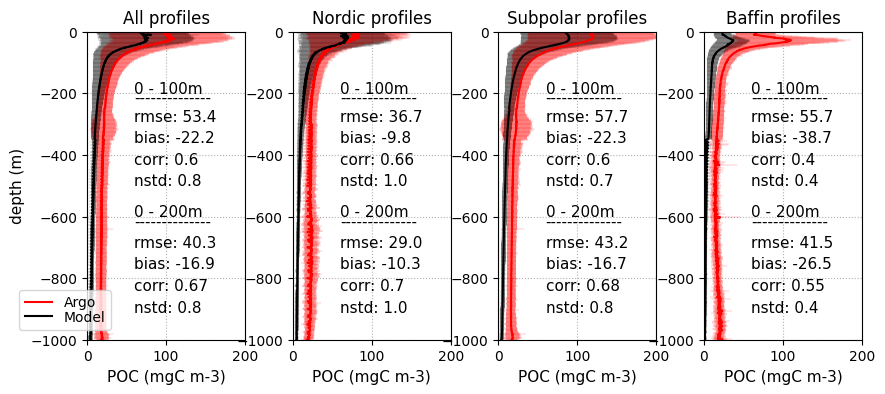

In [7]:
# run the previous first
dn = int(2500)
n    = int(len(model1m) / dn)
nNOR = int(len(model1m[indexNOR1m]) / dn)
nSUB = int(len(model1m[indexSUB1m]) / dn)
nBAF = int(len(model1m[indexBAF1m]) / dn)

print(nNOR,nSUB,nBAF)

model1m2d    = np.reshape(model1m, (n, dn))
argo1m2d     = np.reshape(argo1m, (n, dn))
model1m2dNOR = np.reshape(model1m[indexNOR1m], (nNOR, dn))
argo1m2dNOR  = np.reshape(argo1m[indexNOR1m], (nNOR, dn))
model1m2dSUB = np.reshape(model1m[indexSUB1m], (nSUB, dn))
argo1m2dSUB  = np.reshape(argo1m[indexSUB1m], (nSUB, dn))
model1m2dBAF = np.reshape(model1m[indexBAF1m], (nBAF, dn))
argo1m2dBAF  = np.reshape(argo1m[indexBAF1m], (nBAF, dn))

print('calculating statistics for ALL')
rmseALL100 = rmse(model1m2d[:,0:100].flatten(),argo1m2d[:,0:100].flatten())
biasALL100 = bias(model1m2d[:,0:100].flatten(),argo1m2d[:,0:100].flatten())
corrALL100 = corr(model1m2d[:,0:100].flatten(),argo1m2d[:,0:100].flatten())
nstdALL100 = nstd(model1m2d[:,0:100].flatten(),argo1m2d[:,0:100].flatten())
rmseALL200 = rmse(model1m2d[:,0:200].flatten(),argo1m2d[:,0:200].flatten())
biasALL200 = bias(model1m2d[:,0:200].flatten(),argo1m2d[:,0:200].flatten())
corrALL200 = corr(model1m2d[:,0:200].flatten(),argo1m2d[:,0:200].flatten())
nstdALL200 = nstd(model1m2d[:,0:200].flatten(),argo1m2d[:,0:200].flatten())

print('calculating statistics for NOR')
rmseNOR100 = rmse(model1m2dNOR[:,0:100].flatten(),argo1m2dNOR[:,0:100].flatten())
biasNOR100 = bias(model1m2dNOR[:,0:100].flatten(),argo1m2dNOR[:,0:100].flatten())
corrNOR100 = corr(model1m2dNOR[:,0:100].flatten(),argo1m2dNOR[:,0:100].flatten())
nstdNOR100 = nstd(model1m2dNOR[:,0:100].flatten(),argo1m2dNOR[:,0:100].flatten())
rmseNOR200 = rmse(model1m2dNOR[:,0:200].flatten(),argo1m2dNOR[:,0:200].flatten())
biasNOR200 = bias(model1m2dNOR[:,0:200].flatten(),argo1m2dNOR[:,0:200].flatten())
corrNOR200 = corr(model1m2dNOR[:,0:200].flatten(),argo1m2dNOR[:,0:200].flatten())
nstdNOR200 = nstd(model1m2dNOR[:,0:200].flatten(),argo1m2dNOR[:,0:200].flatten())

print('calculating statistics for SUB')
rmseSUB100 = rmse(model1m2dSUB[:,0:100].flatten(),argo1m2dSUB[:,0:100].flatten())
biasSUB100 = bias(model1m2dSUB[:,0:100].flatten(),argo1m2dSUB[:,0:100].flatten())
corrSUB100 = corr(model1m2dSUB[:,0:100].flatten(),argo1m2dSUB[:,0:100].flatten())
nstdSUB100 = nstd(model1m2dSUB[:,0:100].flatten(),argo1m2dSUB[:,0:100].flatten())
rmseSUB200 = rmse(model1m2dSUB[:,0:200].flatten(),argo1m2dSUB[:,0:200].flatten())
biasSUB200 = bias(model1m2dSUB[:,0:200].flatten(),argo1m2dSUB[:,0:200].flatten())
corrSUB200 = corr(model1m2dSUB[:,0:200].flatten(),argo1m2dSUB[:,0:200].flatten())
nstdSUB200 = nstd(model1m2dSUB[:,0:200].flatten(),argo1m2dSUB[:,0:200].flatten())

print('calculating statistics for BAF')
rmseBAF100 = rmse(model1m2dBAF[:,0:100].flatten(),argo1m2dBAF[:,0:100].flatten())
biasBAF100 = bias(model1m2dBAF[:,0:100].flatten(),argo1m2dBAF[:,0:100].flatten())
corrBAF100 = corr(model1m2dBAF[:,0:100].flatten(),argo1m2dBAF[:,0:100].flatten())
nstdBAF100 = nstd(model1m2dBAF[:,0:100].flatten(),argo1m2dBAF[:,0:100].flatten())
rmseBAF200 = rmse(model1m2dBAF[:,0:200].flatten(),argo1m2dBAF[:,0:200].flatten())
biasBAF200 = bias(model1m2dBAF[:,0:200].flatten(),argo1m2dBAF[:,0:200].flatten())
corrBAF200 = corr(model1m2dBAF[:,0:200].flatten(),argo1m2dBAF[:,0:200].flatten())
nstdBAF200 = nstd(model1m2dBAF[:,0:200].flatten(),argo1m2dBAF[:,0:200].flatten())

sda = np.zeros((dn)); sdaNOR = np.zeros((dn)); sdaSUB = np.zeros((dn)); sdaBAF = np.zeros((dn));
mna = np.zeros((dn)); mnaNOR = np.zeros((dn)); mnaSUB = np.zeros((dn)); mnaBAF = np.zeros((dn));
sdm = np.zeros((dn)); sdmNOR = np.zeros((dn)); sdmSUB = np.zeros((dn)); sdmBAF = np.zeros((dn));
mnm = np.zeros((dn)); mnmNOR = np.zeros((dn)); mnmSUB = np.zeros((dn)); mnmBAF = np.zeros((dn));
for d in range(dn):
    mnm[d] = np.nanmean(model1m2d[:,d]); mnmNOR[d] = np.nanmean(model1m2dNOR[:,d]); mnmSUB[d] = np.nanmean(model1m2dSUB[:,d]); mnmBAF[d] = np.nanmean(model1m2dBAF[:,d]); 
    sdm[d] = np.nanstd(model1m2d[:,d]) ; sdmNOR[d] = np.nanstd(model1m2dNOR[:,d]) ; sdmSUB[d] = np.nanstd(model1m2dSUB[:,d]) ; sdmBAF[d] = np.nanstd(model1m2dBAF[:,d]) ;
    mna[d] = np.nanmean(argo1m2d[:,d]) ; mnaNOR[d] = np.nanmean(argo1m2dNOR[:,d]) ; mnaSUB[d] = np.nanmean(argo1m2dSUB[:,d]) ; mnaBAF[d] = np.nanmean(argo1m2dBAF[:,d]) ;
    sda[d] = np.nanstd(argo1m2d[:,d])  ; sdaNOR[d] = np.nanstd(argo1m2dNOR[:,d])  ; sdaSUB[d] = np.nanstd(argo1m2dSUB[:,d])  ; sdaBAF[d] = np.nanstd(argo1m2dBAF[:,d])  ;

fig = plt.figure(figsize=(10,4))
ax1=fig.add_subplot(1,4,1)
for d in range(dn):
    plt.plot( [mna[d]-sda[d],mna[d]+sda[d]],[ -np.arange(dn)[d], -np.arange(dn)[d] ], color='r', alpha = 0.1)
    plt.plot( [mnm[d]-sdm[d],mnm[d]+sdm[d]],[ -np.arange(dn)[d], -np.arange(dn)[d] ], color='k', alpha = 0.1)
plt.plot(mna,-np.arange(dn), color='r')
plt.plot(mnm,-np.arange(dn), color='k')
plt.xlim(0,200)
plt.ylim(-1000,0)
plt.grid(linestyle=':')
plt.title('All profiles')
plt.ylabel('depth (m)',fontsize=11)
plt.xlabel('POC (mgC m-3)',fontsize=11)
plt.text(0.3,0.8,'0 - 100m',transform=ax1.transAxes,fontsize=11)
plt.text(0.3,0.77,'--------------',transform=ax1.transAxes,fontsize=11)
plt.text(0.3,0.71,'rmse: '+str(np.round(rmseALL100,1)),transform=ax1.transAxes,fontsize=11)
plt.text(0.3,0.64,'bias: '+str(np.round(biasALL100,1)),transform=ax1.transAxes,fontsize=11)
plt.text(0.3,0.57,'corr: '+str(np.round(corrALL100,2)),transform=ax1.transAxes,fontsize=11)
plt.text(0.3,0.50,'nstd: '+str(np.round(nstdALL100,1)),transform=ax1.transAxes,fontsize=11)
plt.text(0.3,0.4,'0 - 200m',transform=ax1.transAxes,fontsize=11)
plt.text(0.3,0.37,'--------------',transform=ax1.transAxes,fontsize=11)
plt.text(0.3,0.30,'rmse: '+str(np.round(rmseALL200,1)),transform=ax1.transAxes,fontsize=11)
plt.text(0.3,0.23,'bias: '+str(np.round(biasALL200,1)),transform=ax1.transAxes,fontsize=11)
plt.text(0.3,0.16,'corr: '+str(np.round(corrALL200,2)),transform=ax1.transAxes,fontsize=11)
plt.text(0.3,0.09,'nstd: '+str(np.round(nstdALL200,1)),transform=ax1.transAxes,fontsize=11)

ax2=fig.add_subplot(1,4,2)
for d in range(dn):
    plt.plot( [mnaNOR[d]-sdaNOR[d],mnaNOR[d]+sdaNOR[d]],[ -np.arange(dn)[d], -np.arange(dn)[d] ], color='r', alpha = 0.1)
    plt.plot( [mnmNOR[d]-sdmNOR[d],mnmNOR[d]+sdmNOR[d]],[ -np.arange(dn)[d], -np.arange(dn)[d] ], color='k', alpha = 0.1)
plt.plot(mnaNOR,-np.arange(dn), color='r')
plt.plot(mnmNOR,-np.arange(dn), color='k')
plt.xlim(0,200)
plt.ylim(-1000,0)
plt.grid(linestyle=':')
plt.title('Nordic profiles')
#plt.ylabel('depth (m)')
plt.xlabel('POC (mgC m-3)',fontsize=11)
plt.text(0.3,0.8,'0 - 100m',transform=ax2.transAxes,fontsize=11)
plt.text(0.3,0.77,'--------------',transform=ax2.transAxes,fontsize=11)
plt.text(0.3,0.71,'rmse: '+str(np.round(rmseNOR100,1)),transform=ax2.transAxes,fontsize=11)
plt.text(0.3,0.64,'bias: '+str(np.round(biasNOR100,1)),transform=ax2.transAxes,fontsize=11)
plt.text(0.3,0.57,'corr: '+str(np.round(corrNOR100,2)),transform=ax2.transAxes,fontsize=11)
plt.text(0.3,0.50,'nstd: '+str(np.round(nstdNOR100,1)),transform=ax2.transAxes,fontsize=11)
plt.text(0.3,0.4,'0 - 200m',transform=ax2.transAxes,fontsize=11)
plt.text(0.3,0.37,'--------------',transform=ax2.transAxes,fontsize=11)
plt.text(0.3,0.30,'rmse: '+str(np.round(rmseNOR200,1)),transform=ax2.transAxes,fontsize=11)
plt.text(0.3,0.23,'bias: '+str(np.round(biasNOR200,1)),transform=ax2.transAxes,fontsize=11)
plt.text(0.3,0.16,'corr: '+str(np.round(corrNOR200,2)),transform=ax2.transAxes,fontsize=11)
plt.text(0.3,0.09,'nstd: '+str(np.round(nstdNOR200,1)),transform=ax2.transAxes,fontsize=11)

ax3=fig.add_subplot(1,4,3)
for d in range(dn):
    plt.plot( [mnaSUB[d]-sdaSUB[d],mnaSUB[d]+sdaSUB[d]],[ -np.arange(dn)[d], -np.arange(dn)[d] ], color='r', alpha = 0.1)
    plt.plot( [mnmSUB[d]-sdmSUB[d],mnmSUB[d]+sdmSUB[d]],[ -np.arange(dn)[d], -np.arange(dn)[d] ], color='k', alpha = 0.1)
plt.plot(mnaSUB,-np.arange(dn), color='r')
plt.plot(mnmSUB,-np.arange(dn), color='k')
plt.xlim(0,200)
plt.ylim(-1000,0)
plt.grid(linestyle=':')
plt.title('Subpolar profiles')
#plt.ylabel('depth (m)')
plt.xlabel('POC (mgC m-3)',fontsize=11)
plt.text(0.3,0.8,'0 - 100m',transform=ax3.transAxes,fontsize=11)
plt.text(0.3,0.77,'--------------',transform=ax3.transAxes,fontsize=11)
plt.text(0.3,0.71,'rmse: '+str(np.round(rmseSUB100,1)),transform=ax3.transAxes,fontsize=11)
plt.text(0.3,0.64,'bias: '+str(np.round(biasSUB100,1)),transform=ax3.transAxes,fontsize=11)
plt.text(0.3,0.57,'corr: '+str(np.round(corrSUB100,2)),transform=ax3.transAxes,fontsize=11)
plt.text(0.3,0.50,'nstd: '+str(np.round(nstdSUB100,1)),transform=ax3.transAxes,fontsize=11)
plt.text(0.3,0.4,'0 - 200m',transform=ax3.transAxes,fontsize=11)
plt.text(0.3,0.37,'--------------',transform=ax3.transAxes,fontsize=11)
plt.text(0.3,0.30,'rmse: '+str(np.round(rmseSUB200,1)),transform=ax3.transAxes,fontsize=11)
plt.text(0.3,0.23,'bias: '+str(np.round(biasSUB200,1)),transform=ax3.transAxes,fontsize=11)
plt.text(0.3,0.16,'corr: '+str(np.round(corrSUB200,2)),transform=ax3.transAxes,fontsize=11)
plt.text(0.3,0.09,'nstd: '+str(np.round(nstdSUB200,1)),transform=ax3.transAxes,fontsize=11)

ax4=fig.add_subplot(1,4,4)
for d in range(dn):
    plt.plot( [mnaBAF[d]-sdaBAF[d],mnaBAF[d]+sdaBAF[d]],[ -np.arange(dn)[d], -np.arange(dn)[d] ], color='r', alpha = 0.1)
    plt.plot( [mnmBAF[d]-sdmBAF[d],mnmBAF[d]+sdmBAF[d]],[ -np.arange(dn)[d], -np.arange(dn)[d] ], color='k', alpha = 0.1)
plt.plot(mnaBAF,-np.arange(dn), color='r', label='Argo')
plt.plot(mnmBAF,-np.arange(dn), color='k', label='Model')
plt.xlim(0,200)
plt.ylim(-1000,0)
plt.grid(linestyle=':')
plt.title('Baffin profiles')
#plt.ylabel('depth (m)')
plt.xlabel('POC (mgC m-3)',fontsize=11)
plt.text(0.3,0.8,'0 - 100m',transform=ax4.transAxes,fontsize=11)
plt.text(0.3,0.77,'--------------',transform=ax4.transAxes,fontsize=11)
plt.text(0.3,0.71,'rmse: '+str(np.round(rmseBAF100,1)),transform=ax4.transAxes,fontsize=11)
plt.text(0.3,0.64,'bias: '+str(np.round(biasBAF100,1)),transform=ax4.transAxes,fontsize=11)
plt.text(0.3,0.57,'corr: '+str(np.round(corrBAF100,2)),transform=ax4.transAxes,fontsize=11)
plt.text(0.3,0.50,'nstd: '+str(np.round(nstdBAF100,1)),transform=ax4.transAxes,fontsize=11)
plt.text(0.3,0.4,'0 - 200m',transform=ax4.transAxes,fontsize=11)
plt.text(0.3,0.37,'--------------',transform=ax4.transAxes,fontsize=11)
plt.text(0.3,0.30,'rmse: '+str(np.round(rmseBAF200,1)),transform=ax4.transAxes,fontsize=11)
plt.text(0.3,0.23,'bias: '+str(np.round(biasBAF200,1)),transform=ax4.transAxes,fontsize=11)
plt.text(0.3,0.16,'corr: '+str(np.round(corrBAF200,2)),transform=ax4.transAxes,fontsize=11)
plt.text(0.3,0.09,'nstd: '+str(np.round(nstdBAF200,1)),transform=ax4.transAxes,fontsize=11)

#fig.legend(loc='center left', bbox_to_anchor=(0.65, 0.185))
fig.legend(loc='center left', bbox_to_anchor=(0.05, 0.185), labelspacing=0.05)
#plt.legend()
plt.subplots_adjust(wspace=0.3)  
#plt.tight_layout()

#fig.canvas.print_figure('./POC.vs.Argo.png',dpi=220)